# Deep Learning for Artificial Intelligence Final Project Report

# Intelligent Stock Market Forecasting, Trading Signal Identification, and Portfolio Optimization using Deep Learning

This report presents the complete development process, experimentation workflow, and evaluation results of the final project for the course *Deep Learning for Artificial Intelligence*. The project investigates how deep learning techniques can be applied to financial time-series analysis for stock market forecasting, trading signal identification, and portfolio optimization.

The project combines both theoretical deep learning concepts and practical AI engineering implementation. Using historical stock market datasets from the Nasdaq market and the Vietnam stock market, multiple deep learning architectures were developed and evaluated to determine their effectiveness in learning temporal financial patterns and supporting investment-related decision-making tasks.

The project includes several major components:

- stock price forecasting using CNN and LSTM architectures,
- short-term and multi-step financial time-series prediction,
- buy and sell signal classification,
- portfolio profitability and risk analysis,
- portfolio allocation strategy construction,
- and lightweight deployment using FastAPI and Streamlit.

The forecasting experiments evaluate different prediction horizons, including next-day prediction, kth-day prediction, and multi-step future forecasting. In addition, the project explores how deep learning can be extended beyond regression tasks into financial classification and portfolio management problems.

The portfolio analysis section integrates both profitability and risk measurements, including cumulative return, volatility, and maximum drawdown, to create a more balanced investment allocation strategy. This demonstrates how machine learning outputs can support higher-level financial decision-making.

The project also emphasizes reproducibility, structured experimentation, and engineering workflow organization. Instead of manually inserting static outputs into the report, all tables, evaluation metrics, and visualization figures are automatically generated and loaded dynamically from the project output folders.

## Reproducibility Note

All tables, metrics, figures, and evaluation outputs presented in this report are loaded dynamically from the `results/` directory generated by the project notebooks. Whenever the notebooks are rerun, the saved outputs are automatically updated, ensuring that the report remains synchronized with the latest experimental results.

This reproducible workflow improves consistency, reduces manual reporting errors, and better reflects professional machine learning experimentation practices.

In [36]:
import pandas as pd
from IPython.display import Image, display

# 1. Project Objective

The primary objective of this project is to investigate the application of deep learning techniques to financial time-series analysis and stock market prediction. The project explores whether neural network architectures such as Convolutional Neural Networks (CNN) and Long Short-Term Memory networks (LSTM) can successfully learn meaningful temporal patterns from historical stock market data and support practical financial decision-making tasks.

Financial forecasting is a challenging problem because stock markets are highly dynamic, noisy, and influenced by many unpredictable external factors. Through this project, deep learning models are evaluated not only on their prediction accuracy but also on their ability to generalize across different forecasting horizons, classification tasks, and investment analysis scenarios.

The project is divided into six major tasks:

1. Nasdaq stock price prediction  
2. Vietnam stock price prediction  
3. Buy and sell trading signal identification  
4. Portfolio selection, risk management, and portfolio allocation  
5. Model deployment and AI engineering workflow  
6. Final report and GitHub repository preparation  

The forecasting tasks investigate different prediction horizons, including next-day forecasting, kth-day future forecasting, and multi-step forecasting. Both CNN and LSTM architectures are compared to understand how different deep learning models perform on financial time-series data.

The trading signal identification tasks extend the project beyond numerical forecasting by transforming the problem into binary classification. The models attempt to identify potential buy and sell opportunities using technical indicators and future return thresholds.

The portfolio analysis section focuses on balancing profitability and investment risk through cumulative return analysis, volatility measurement, maximum drawdown evaluation, and portfolio allocation strategies.

In addition to model development, the project also emphasizes practical AI engineering concepts such as reproducibility, structured experimentation, model comparison, result visualization, deployment using FastAPI and Streamlit, and automated result generation.

Overall, the project aims to demonstrate a complete deep learning workflow for financial analytics, starting from raw stock market data preprocessing and ending with deployable AI applications and portfolio-level financial analysis.

# 2. Dataset Description

This project uses two primary financial datasets: a Nasdaq stock market dataset and a Vietnam stock market dataset. These datasets provide the historical price information required for forecasting, signal classification, and portfolio analysis tasks.

## Nasdaq Dataset

The Nasdaq dataset is mainly used for Task 1, which focuses on stock price forecasting using CNN and LSTM deep learning models. The dataset contains historical daily stock market information collected over a long trading period. Each record represents one trading day and includes several important numerical features commonly used in financial time-series analysis.

The main features include:

- Open price
- High price
- Low price
- Close price
- Adjusted Close price
- Trading volume

The Open, High, Low, and Close (OHLC) values describe daily market behavior and price movement. Adjusted Close price is particularly useful because it reflects stock splits and dividend adjustments, making it more reliable for long-term analysis. Trading volume provides additional information about market activity and investor participation.

For forecasting tasks, the Close price was primarily used as the prediction target because it represents the final market valuation at the end of each trading session. Before model training, the data was normalized using MinMax scaling to stabilize training behavior and improve convergence of deep learning models.

The Nasdaq dataset was used in three forecasting scenarios:

1. Next-day stock price prediction  
2. kth-day (7th-day) future prediction  
3. Multi-step next 7-day forecasting  

These tasks evaluate how prediction difficulty changes as the forecasting horizon becomes longer.

## Vietnam Stock Dataset

The Vietnam stock dataset is used for Task 2, Task 3, and Task 4. It contains historical stock market data for several Vietnamese companies, including stocks such as VCB, VNM, FPT, HPG, and MBB.

The core features include:

- Open price
- High price
- Low price
- Close price
- Volume
- TradingDate

The TradingDate feature provides chronological ordering of market observations, which is essential for time-series modeling. Similar to the Nasdaq dataset, historical closing prices were heavily used for forecasting and signal identification tasks.

The Vietnam dataset supports multiple project objectives:

- CNN-based stock price forecasting  
- Buy and sell signal classification  
- Portfolio profitability and risk analysis  
- Portfolio allocation strategy construction  

In addition to historical market prices, the Vietnam dataset also contained supplementary information such as:

- Financial ratios  
- Dividend history  
- Industry-related analysis data  

However, these additional features were not heavily integrated into the final deep learning pipeline. The primary modeling framework focused mainly on historical stock price behavior because it directly aligned with the forecasting and trading signal objectives of the project.

Before training, the Vietnam stock data was cleaned, sorted chronologically, and normalized to ensure stable deep learning model performance. Sliding window sequence generation was then applied to transform the raw time-series data into supervised learning samples suitable for CNN and LSTM architectures.

# 3. Methodology

This project follows a deep learning workflow for financial time-series forecasting, trading signal classification, and portfolio analysis. The methodology includes data preprocessing, chronological time-series splitting, sliding window generation, and deep learning model training using CNN and LSTM architectures.

## 3.1 Data Preprocessing

A structured preprocessing pipeline was applied before model training to ensure data quality and stable learning behavior.

The preprocessing steps included:

- loading stock market CSV datasets,
- converting date columns into datetime format,
- sorting observations chronologically,
- removing missing or invalid values,
- selecting relevant numerical features,
- normalizing features using MinMaxScaler,
- and transforming raw time-series data into supervised learning sequences.

Chronological sorting is especially important in financial forecasting because stock prices depend heavily on temporal order. Missing values were removed to prevent instability during training.

Feature normalization was performed using MinMaxScaler to scale numerical values into a smaller range, typically between 0 and 1. This improves gradient stability and accelerates convergence during deep learning optimization.

For forecasting tasks, the Close price was used as the primary prediction target because it reflects the final stock valuation at the end of each trading day.

## 3.2 Time-Series Split

Unlike traditional machine learning problems, financial time-series data cannot be randomly shuffled before splitting because this would introduce future information leakage.

Therefore, the dataset was split chronologically into:

- 70% training data  
- 15% validation data  
- 15% test data  

The training set was used to learn model parameters, the validation set was used for hyperparameter tuning and monitoring overfitting, and the test set was reserved for final performance evaluation.

Chronological splitting better simulates real-world forecasting conditions because future observations remain completely unseen during training.

## 3.3 Sliding Window Approach

A sliding window technique was used to convert sequential stock market data into supervised learning samples suitable for deep learning models.

The project used a 30-day input window, meaning that the model receives the previous 30 trading days as input in order to predict future stock prices or trading signals.

For example:

- Input: stock prices from day 1 to day 30  
- Output: stock price or trading signal for a future day  

This approach allows the models to learn temporal dependencies, short-term trends, and sequential market behavior from historical observations.

Different forecasting tasks used different prediction targets:

- Next-day prediction  
- 7th-day future prediction  
- Multi-step next 7-day forecasting  

The sliding window framework was applied consistently across both Nasdaq and Vietnam stock datasets.

## 3.4 Models Used

Two deep learning architectures were implemented in this project: Convolutional Neural Networks (CNN) and Long Short-Term Memory networks (LSTM).

### CNN Model

CNN models were used to capture local temporal patterns in stock market sequences. Although CNNs are traditionally popular in image processing, one-dimensional convolutional layers can also perform effectively on financial time-series data.

The CNN architecture extracts short-term trend patterns by applying convolution filters across sequential stock price windows. CNNs are computationally efficient and performed particularly well in short-term forecasting and multi-step prediction tasks.

Main CNN components included:

- 1D convolution layers  
- activation functions (ReLU)  
- pooling layers  
- fully connected dense layers  
- output prediction layers  

### LSTM Model

LSTM networks are specialized recurrent neural networks designed to preserve long-term sequential memory.

LSTM models were used because financial time-series data often contain temporal dependencies across multiple trading periods. The memory cell and gating mechanisms inside LSTM networks help reduce the vanishing gradient problem commonly found in standard recurrent neural networks.

The LSTM architecture learns sequential relationships by processing stock price observations step-by-step over time.

Main LSTM components included:

- LSTM recurrent layers  
- dropout regularization  
- dense output layers  

Both CNN and LSTM models were trained and evaluated using forecasting error metrics such as RMSE and MAE, while classification tasks used accuracy, precision, recall, F1-score, and confusion matrices.

# 4. Task 1 — Nasdaq Stock Price Prediction

Task 1 focuses on forecasting stock prices using historical Nasdaq market data. This section evaluates the ability of deep learning architectures to learn temporal financial patterns and predict future stock price behavior under different forecasting horizons.

The Nasdaq forecasting experiments were divided into three subtasks with increasing levels of difficulty:

- **Task 1.1:** Multi-feature next-day prediction  
- **Task 1.2:** kth-day future prediction (7th-day forecasting)  
- **Task 1.3:** Multi-step next 7 days prediction  

The main objective of Task 1 was not only to minimize forecasting error but also to compare the performance of different deep learning architectures under various prediction scenarios.

Two deep learning models were implemented and evaluated:

- Convolutional Neural Networks (CNN)
- Long Short-Term Memory networks (LSTM)

The CNN architecture was designed to capture short-term local temporal patterns within stock price sequences using convolutional filters. CNN models are computationally efficient and particularly suitable for identifying localized trends and short-term fluctuations in financial time-series data.

The LSTM architecture was designed to preserve long-term sequential dependencies through recurrent memory mechanisms. LSTMs are commonly applied to sequential forecasting problems because they can theoretically retain historical temporal information across longer sequences.

The Nasdaq experiments investigated how forecasting difficulty changes as the prediction horizon increases. Next-day forecasting is generally easier because short-term market behavior tends to be more stable. In contrast, kth-day and multi-step forecasting tasks are significantly more challenging because uncertainty and prediction error accumulate further into the future.

For all Task 1 experiments:

- a 30-day sliding input window was used,
- chronological time-series splitting was applied,
- features were normalized using MinMaxScaler,
- and model performance was evaluated using RMSE and MAE metrics.

The forecasting results, prediction graphs, and training curves presented in the following sections provide both quantitative and visual evidence of model performance across different forecasting horizons.

## 4.1 Task 1 Results Table

In [37]:
task1_results = pd.read_csv(
    "../results/tables/task1_model_comparison_table.csv"
)

task1_results

,Task,Model,RMSE,MAE
0,Task 1.1 - Next-day prediction,CNN,0.0243,0.0169
1,Task 1.2 - 7th day prediction,CNN,0.0964,0.0712
2,Task 1.3 - Next 7 days prediction,CNN,0.0572,0.0391
3,Task 1.2 - 7th day prediction,LSTM,0.1858,0.1341
4,Task 1.3 - Next 7 days prediction,LSTM,0.1814,0.1236


### Observation

The Task 1 comparison table summarizes the performance of CNN and LSTM models for Nasdaq stock price prediction under different forecasting settings.

The results indicate that different prediction horizons can benefit from different deep learning architectures. In this experiment, CNN consistently achieved lower RMSE and MAE values across all tasks, showing stronger overall prediction performance compared to LSTM.

For Task 1.1 (next-day prediction), CNN achieved the best performance with RMSE = 0.0243 and MAE = 0.0169, demonstrating that convolutional layers are highly effective at capturing short-term local temporal patterns in stock price movements.

For Task 1.2 (7th-day prediction), CNN continued to outperform LSTM. Although forecasting farther into the future is more difficult due to increasing uncertainty, CNN maintained relatively stable prediction accuracy while LSTM produced significantly larger prediction errors.

For Task 1.3 (next 7 days prediction), CNN again achieved lower RMSE and MAE values than LSTM, suggesting that the CNN architecture generalized better for multi-step forecasting in this dataset.

Overall, the experimental results suggest that CNN was more suitable for the Nasdaq stock prediction tasks in this project. The CNN model was able to extract useful local trends and price movement patterns effectively, while the LSTM model may have struggled with the volatility and non-linear behavior of the stock market data. Nevertheless, LSTM still demonstrated the ability to model sequential dependencies and could potentially perform better with larger datasets, more tuning, or longer training time.

## 4.2 Best Model Selection for Task 1

In [38]:
task1_best = pd.read_csv(
    "../results/tables/task1_best_models_table.csv"
)

task1_best

,Task,Model,RMSE,MAE
0,Task 1.1 - Next-day prediction,CNN,0.0243,0.0169
1,Task 1.2 - 7th day prediction,CNN,0.0964,0.0712
2,Task 1.3 - Next 7 days prediction,CNN,0.0572,0.0391


### Observation

The best model selection table automatically identifies the model with the lowest RMSE for each forecasting task, making the selection process objective and data-driven.

Based on the experimental results, CNN was selected as the best-performing model for all Task 1 forecasting scenarios. CNN achieved the lowest RMSE and MAE values in Task 1.1, Task 1.2, and Task 1.3, indicating more accurate prediction performance compared to LSTM.

For Task 1.1 (next-day prediction), CNN achieved RMSE = 0.0243 and MAE = 0.0169, showing excellent capability in capturing short-term stock price movements.

For Task 1.2 (7th-day prediction), CNN also outperformed LSTM with RMSE = 0.0964 and MAE = 0.0712. Although prediction accuracy decreased compared to next-day forecasting, the CNN model still maintained relatively stable performance.

For Task 1.3 (next 7 days prediction), CNN again achieved the best result with RMSE = 0.0572 and MAE = 0.0391, demonstrating strong generalization ability for multi-step forecasting tasks.

Overall, the results suggest that CNN was the most suitable architecture for the Nasdaq stock prediction tasks in this project. The convolutional layers effectively extracted local temporal patterns and short-term market trends from historical stock data, leading to more stable and accurate forecasting performance.

## 4.3 Task 1 RMSE Comparison

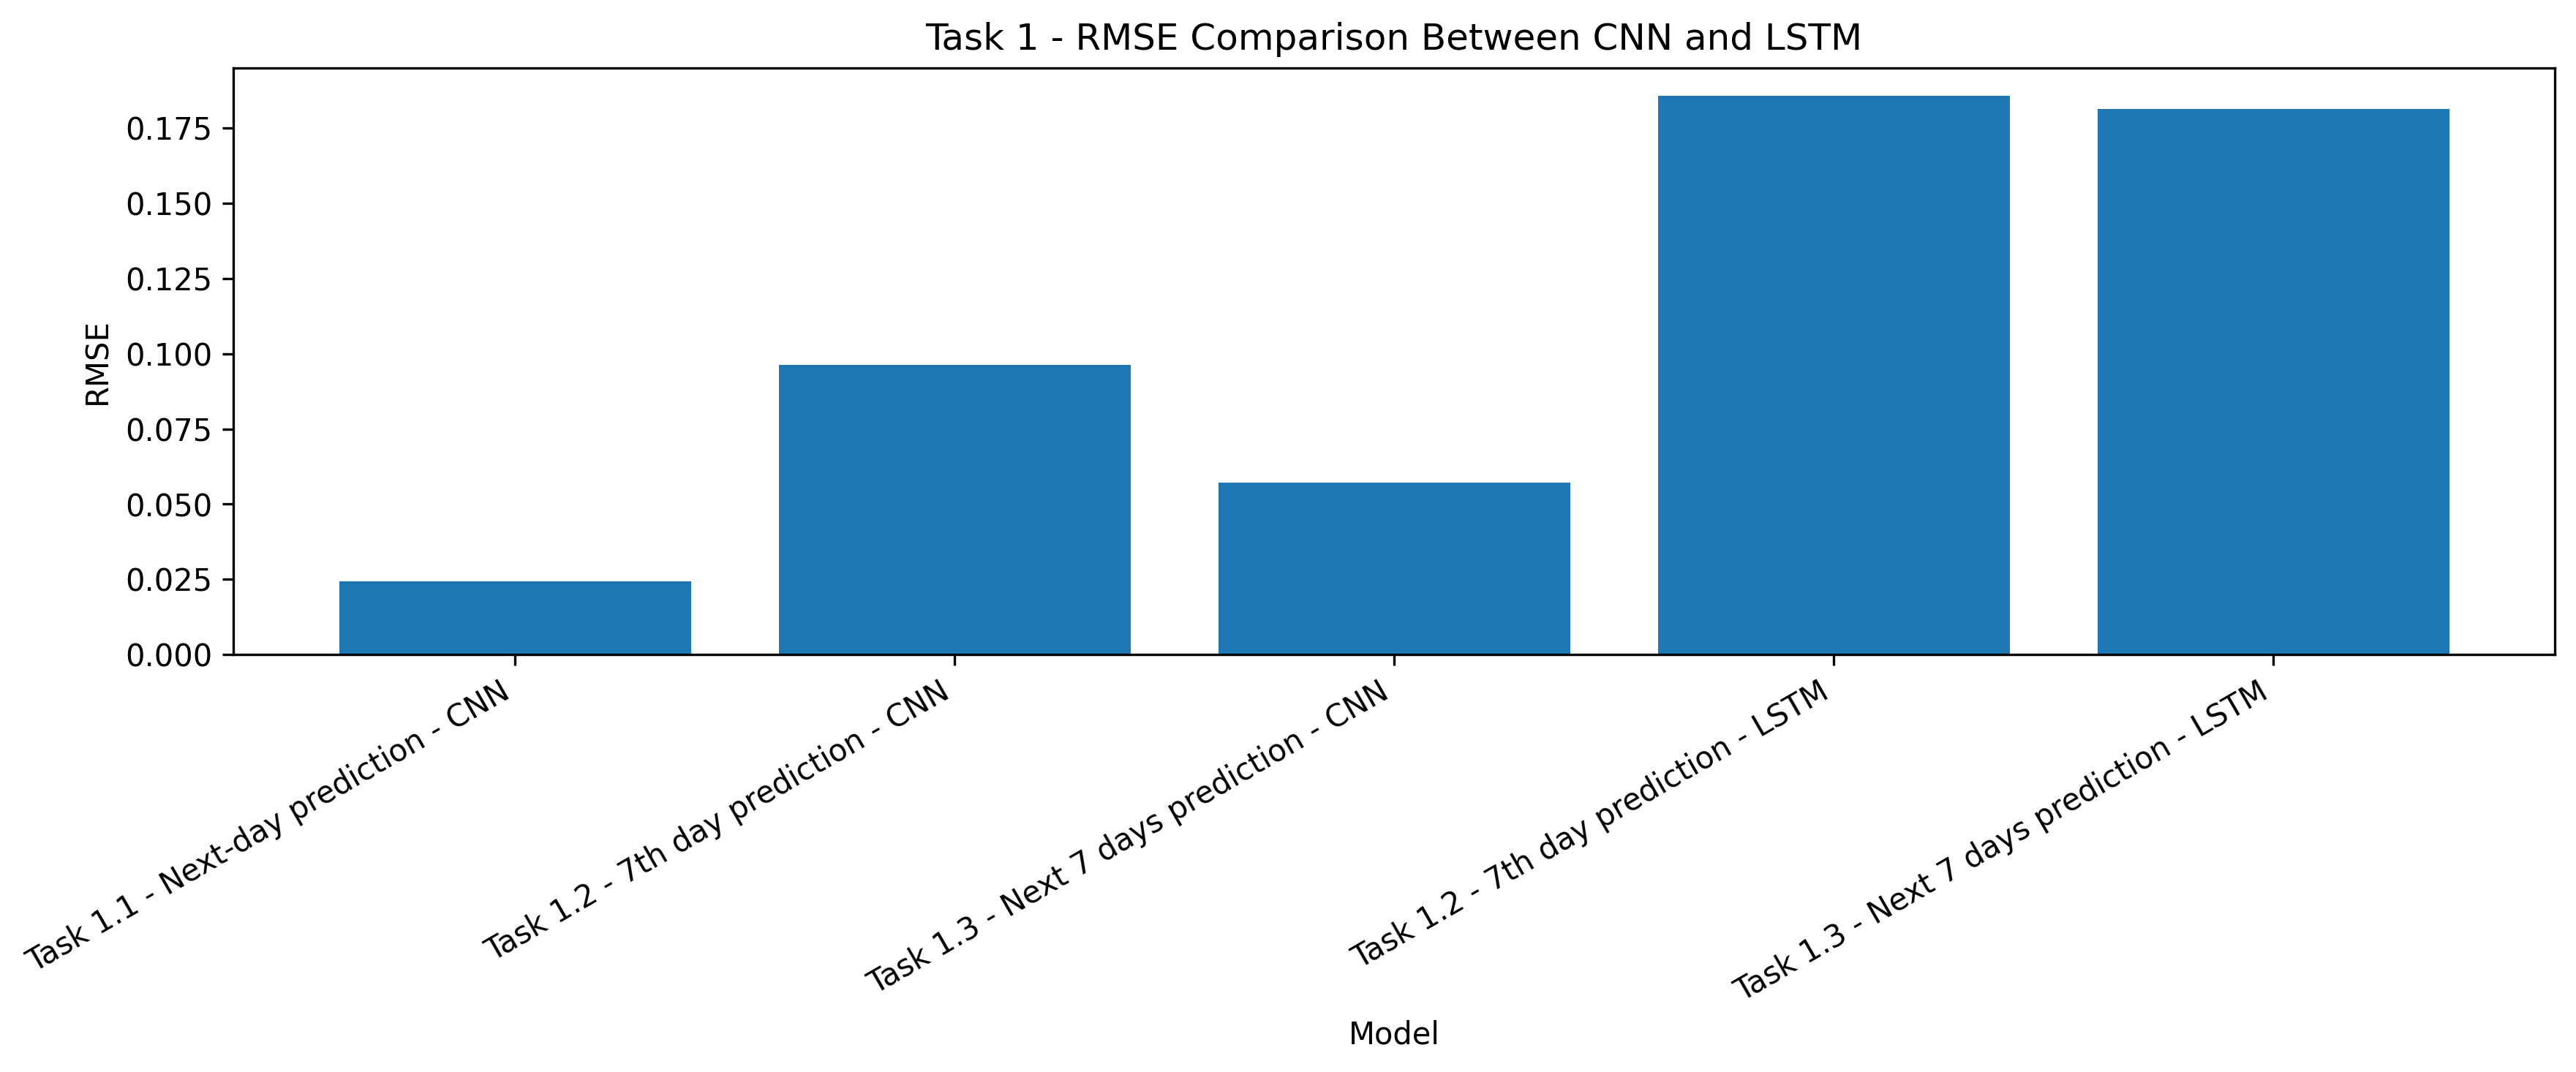

In [39]:
display(Image(
    "../results/figures/task1_rmse_model_comparison.png"
))

### Observation

The RMSE comparison figure presents the prediction error of CNN and LSTM models across different forecasting tasks. Lower RMSE values indicate better prediction accuracy and more reliable forecasting performance.

From the visualization, CNN consistently achieved lower RMSE values than LSTM in all forecasting scenarios. The CNN next-day prediction model obtained the lowest RMSE overall, demonstrating the strongest performance for short-term stock prediction tasks.

As the forecasting horizon became longer, the RMSE values increased for both models. This indicates that predicting stock prices further into the future is more challenging because uncertainty and market volatility accumulate over time.

For the 7th-day prediction and next 7 days forecasting tasks, CNN still maintained relatively lower prediction errors compared to LSTM. In contrast, the LSTM models produced noticeably larger RMSE values, suggesting that the model struggled more with the volatility and complexity of the Nasdaq stock dataset.

Overall, the figure clearly demonstrates that CNN provided more stable and accurate forecasting performance throughout Task 1, especially for short-term and multi-step prediction tasks.

## 4.4 Task 1 MAE Comparison

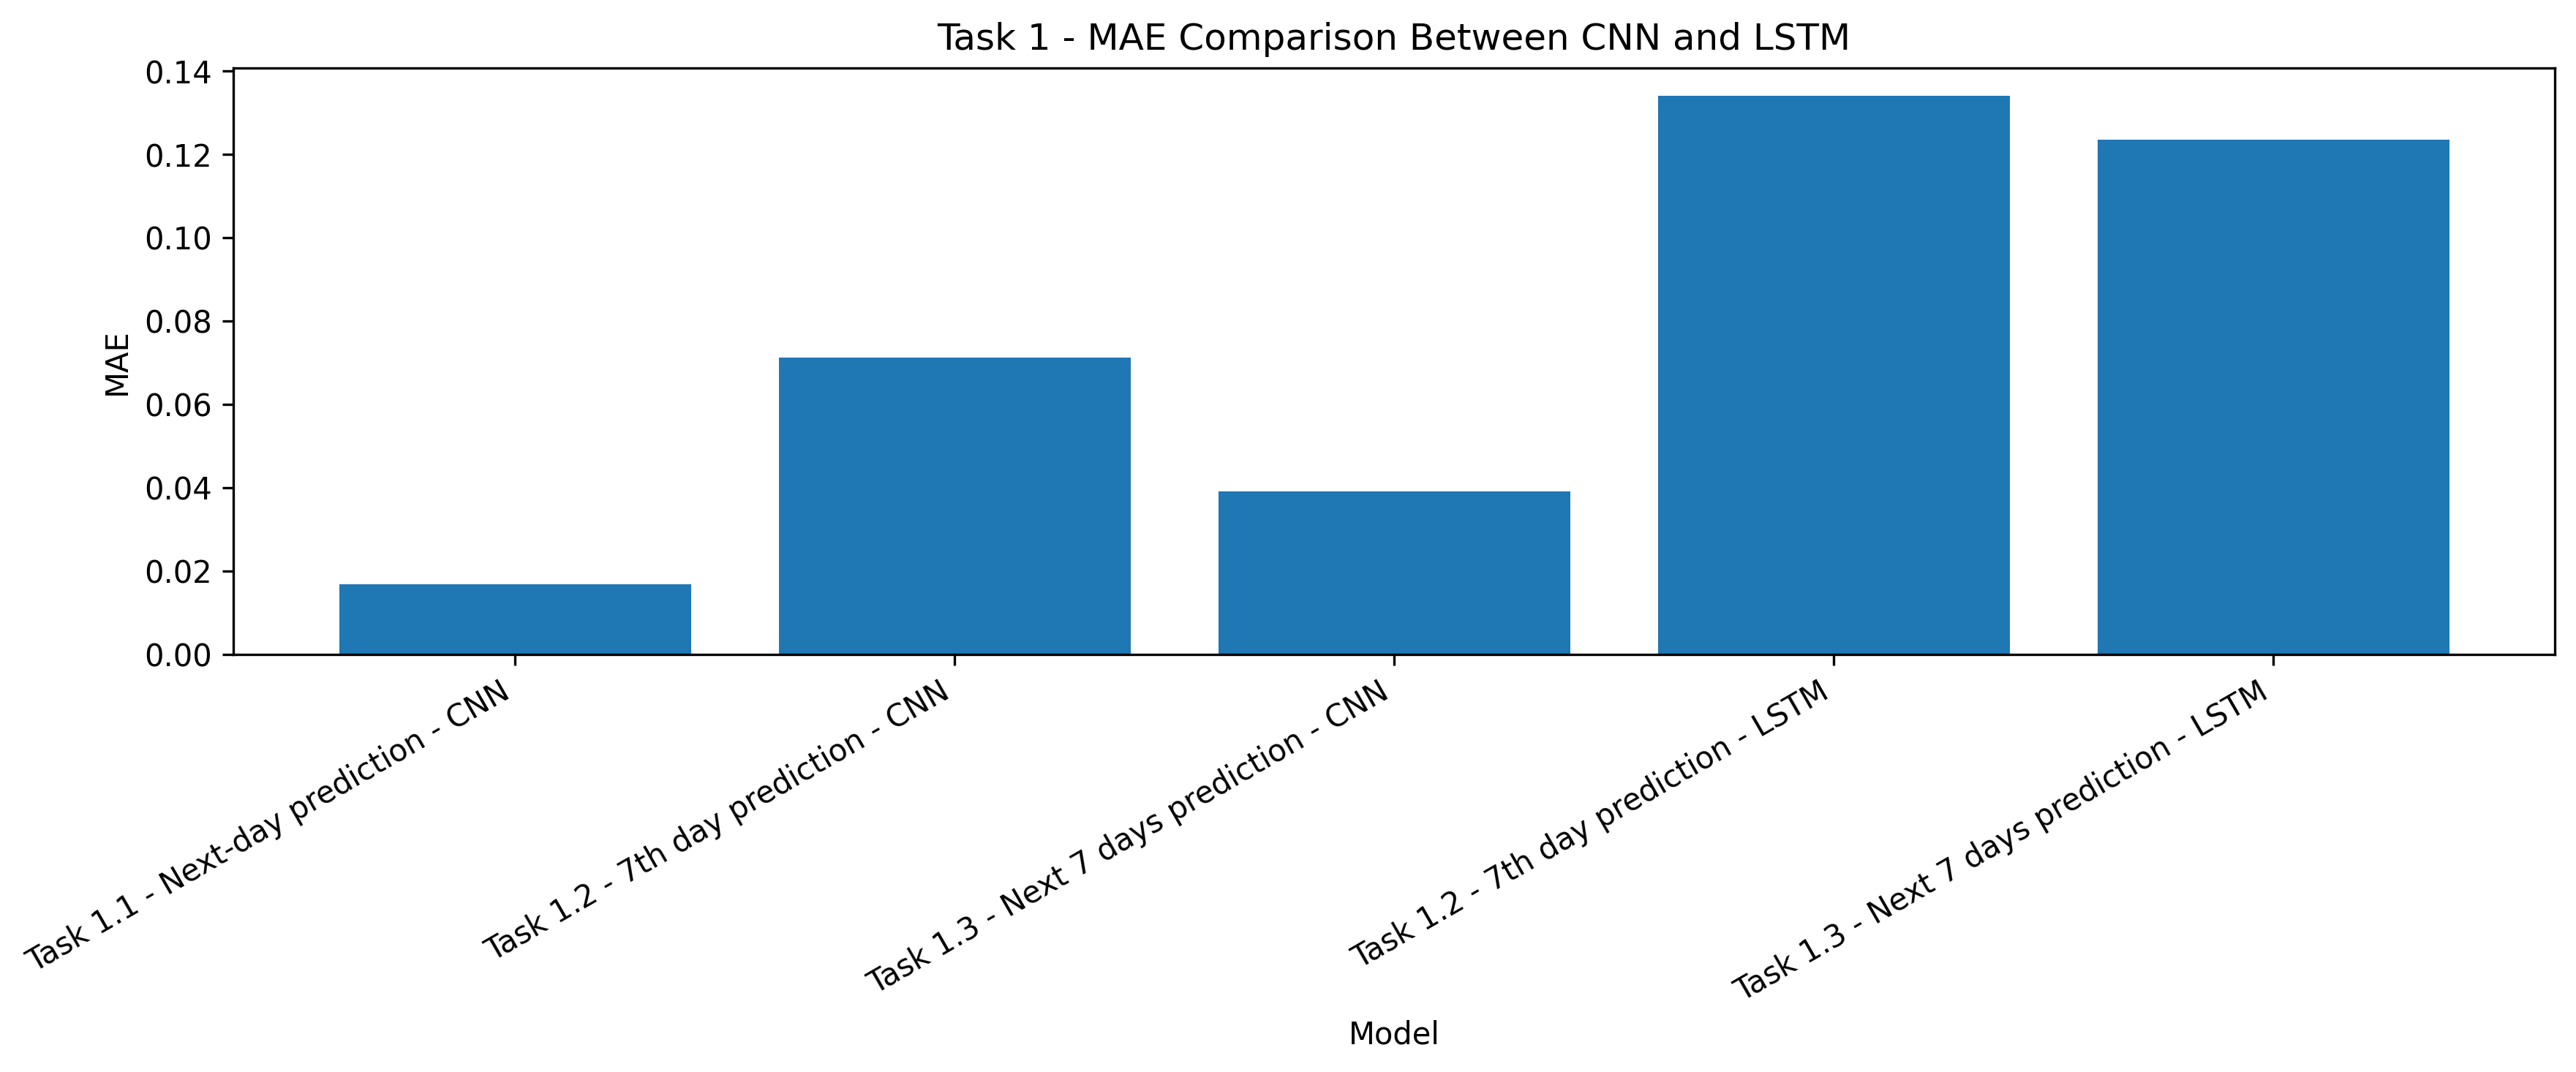

In [40]:
display(Image(
    "../results/figures/task1_mae_model_comparison.png"
))

### Observation

The MAE comparison figure provides another perspective on forecasting performance by measuring the average absolute difference between the predicted values and the actual stock prices. Lower MAE values indicate more accurate and reliable predictions.

Similar to the RMSE comparison, CNN achieved lower MAE values than LSTM across all forecasting tasks. This confirms that the CNN models consistently produced predictions closer to the real stock prices.

For Task 1.1 (next-day prediction), CNN achieved the lowest MAE overall, showing very strong short-term prediction capability with minimal average forecasting error.

For Task 1.2 and Task 1.3, the MAE values increased as the forecasting horizon became longer. This trend is expected because predicting stock prices further into the future introduces more uncertainty and market fluctuations.

The LSTM models produced noticeably higher MAE values compared to CNN, indicating that their predictions deviated more from the actual stock prices on average. In particular, the LSTM models struggled more with longer-horizon forecasting tasks.

Together, RMSE and MAE provide a more comprehensive evaluation of model performance. RMSE penalizes large prediction errors more heavily, while MAE provides a simpler interpretation of the average prediction error. Since CNN achieved lower values in both metrics, it can be considered the more effective model architecture for Task 1 in this project.

## 4.5 Task 1.1 — CNN Actual vs Predicted

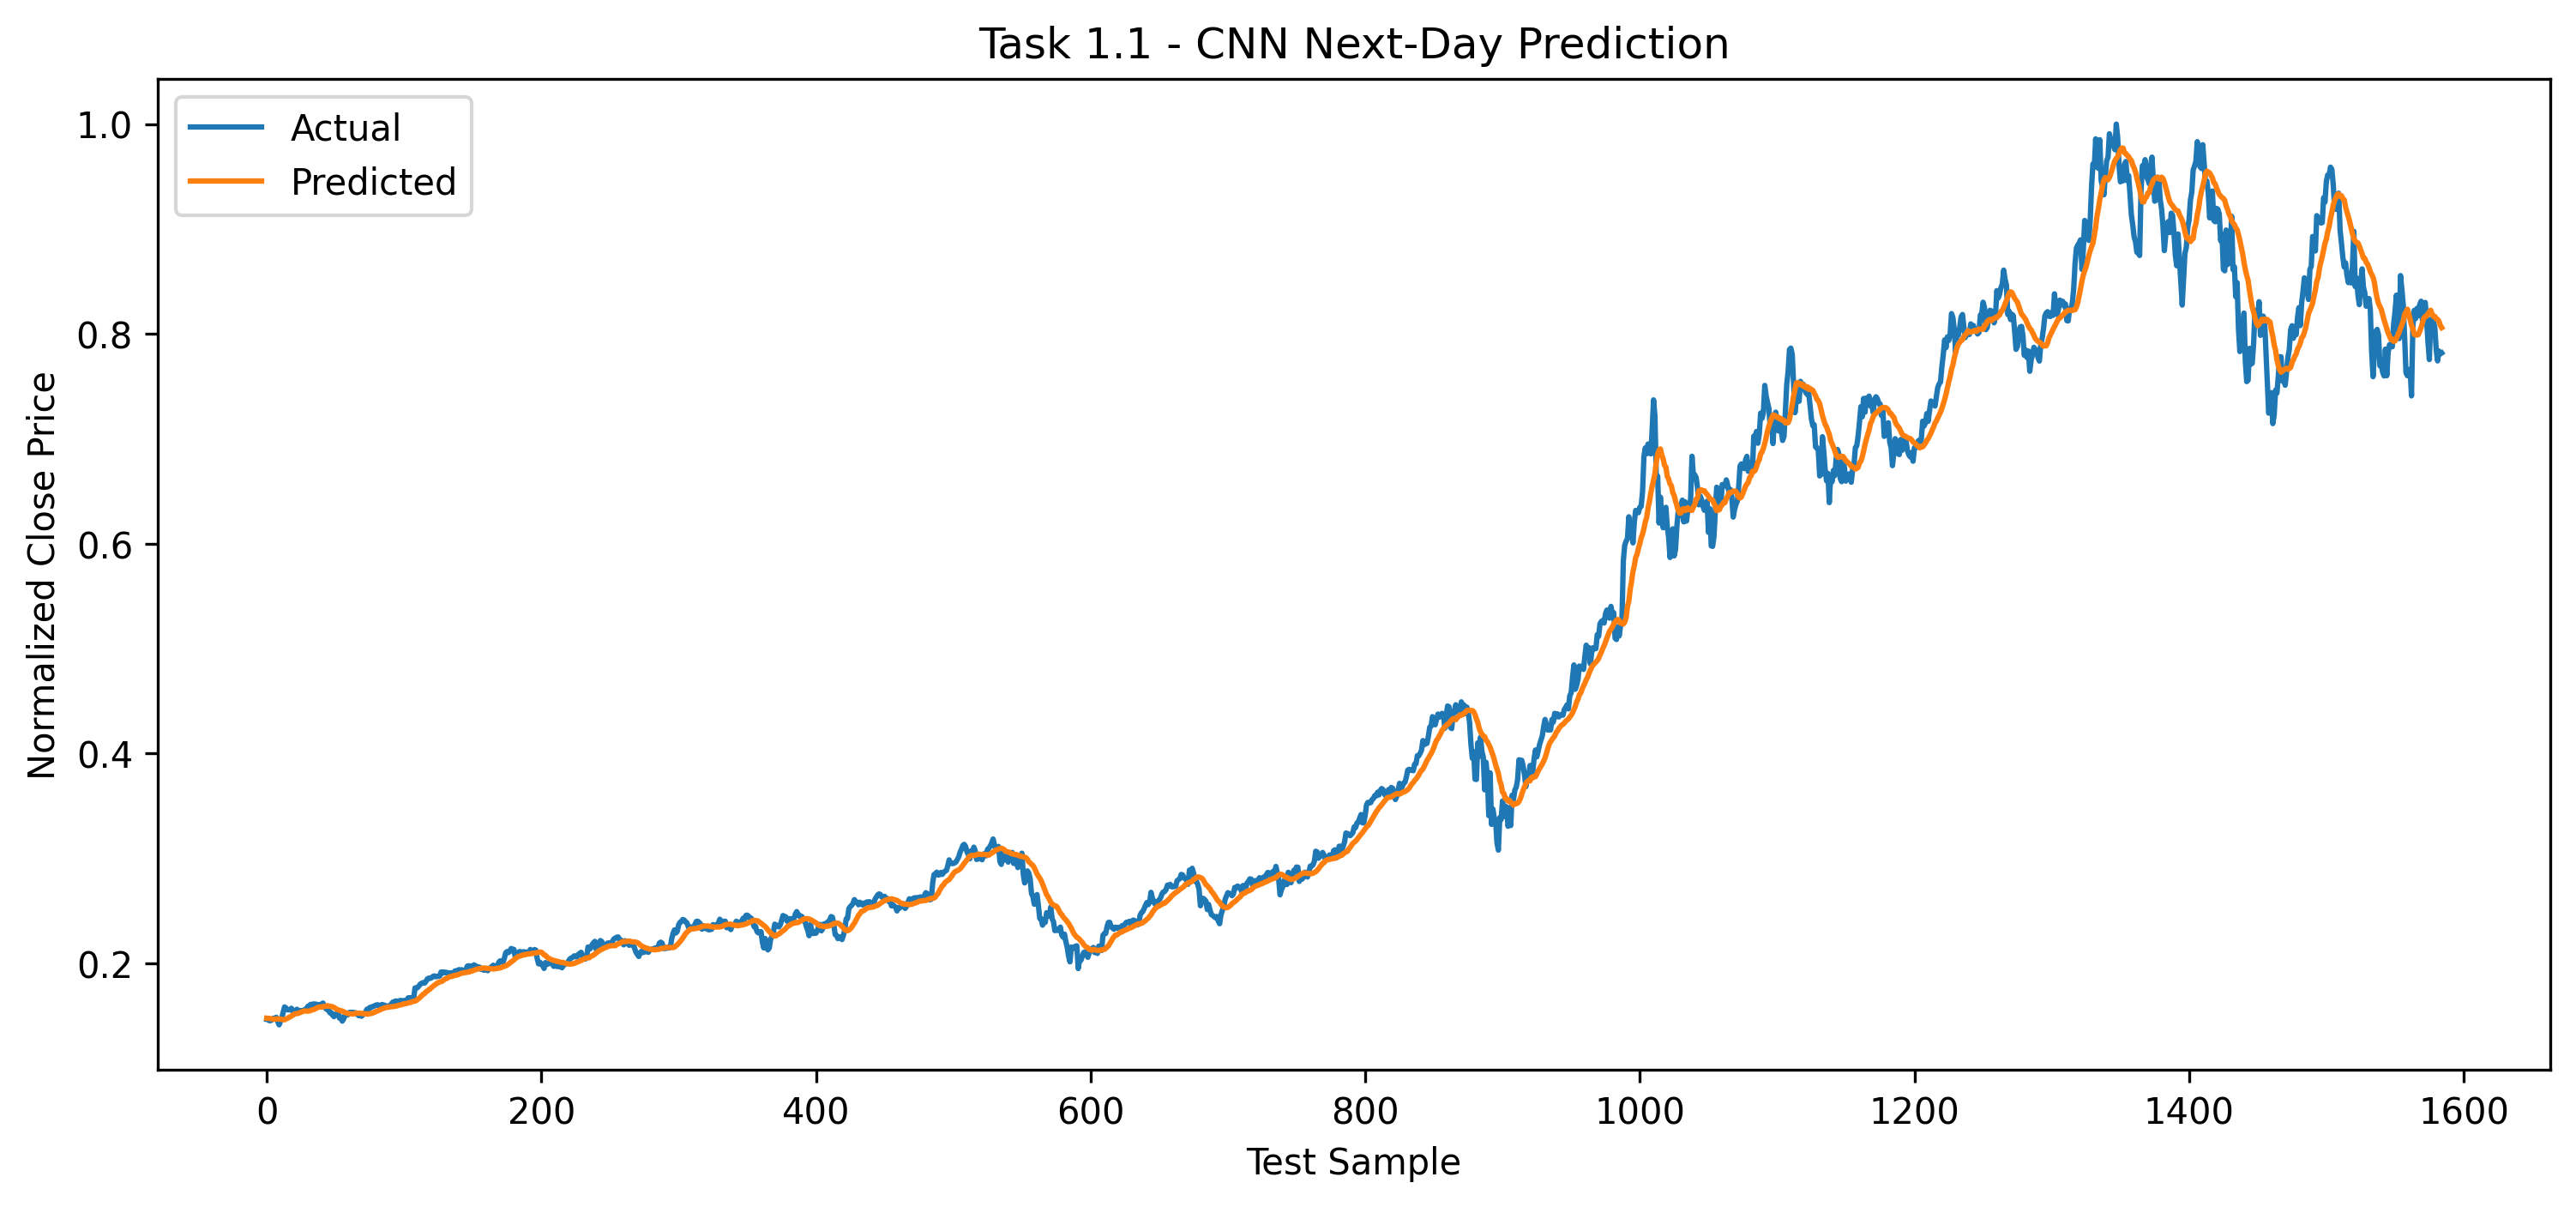

In [41]:
display(Image(
    "../results/figures/task1_1_cnn_actual_vs_predicted.png"
))

### Observation

The Task 1.1 prediction graph shows that the CNN model was able to closely follow the actual Nasdaq stock price movement during the testing period. The predicted line overlaps significantly with the actual price trend, indicating that the model successfully captured important short-term temporal patterns from the historical stock data.

The model performed particularly well in identifying overall upward and downward market trends, including several major fluctuations in the later part of the dataset. This demonstrates that the CNN architecture is effective for next-day stock price forecasting using multi-feature financial inputs.

Although small differences between the actual and predicted values can still be observed, especially during periods of high volatility, these deviations are expected because stock prices are highly dynamic and influenced by unpredictable market conditions.

The smoothness of the prediction curve also suggests that the CNN model generalized well without severe overfitting. Combined with the low RMSE and MAE values reported earlier, the visualization confirms that the CNN model achieved strong forecasting performance for short-term stock prediction.

## 4.6 Task 1.1 Training Loss

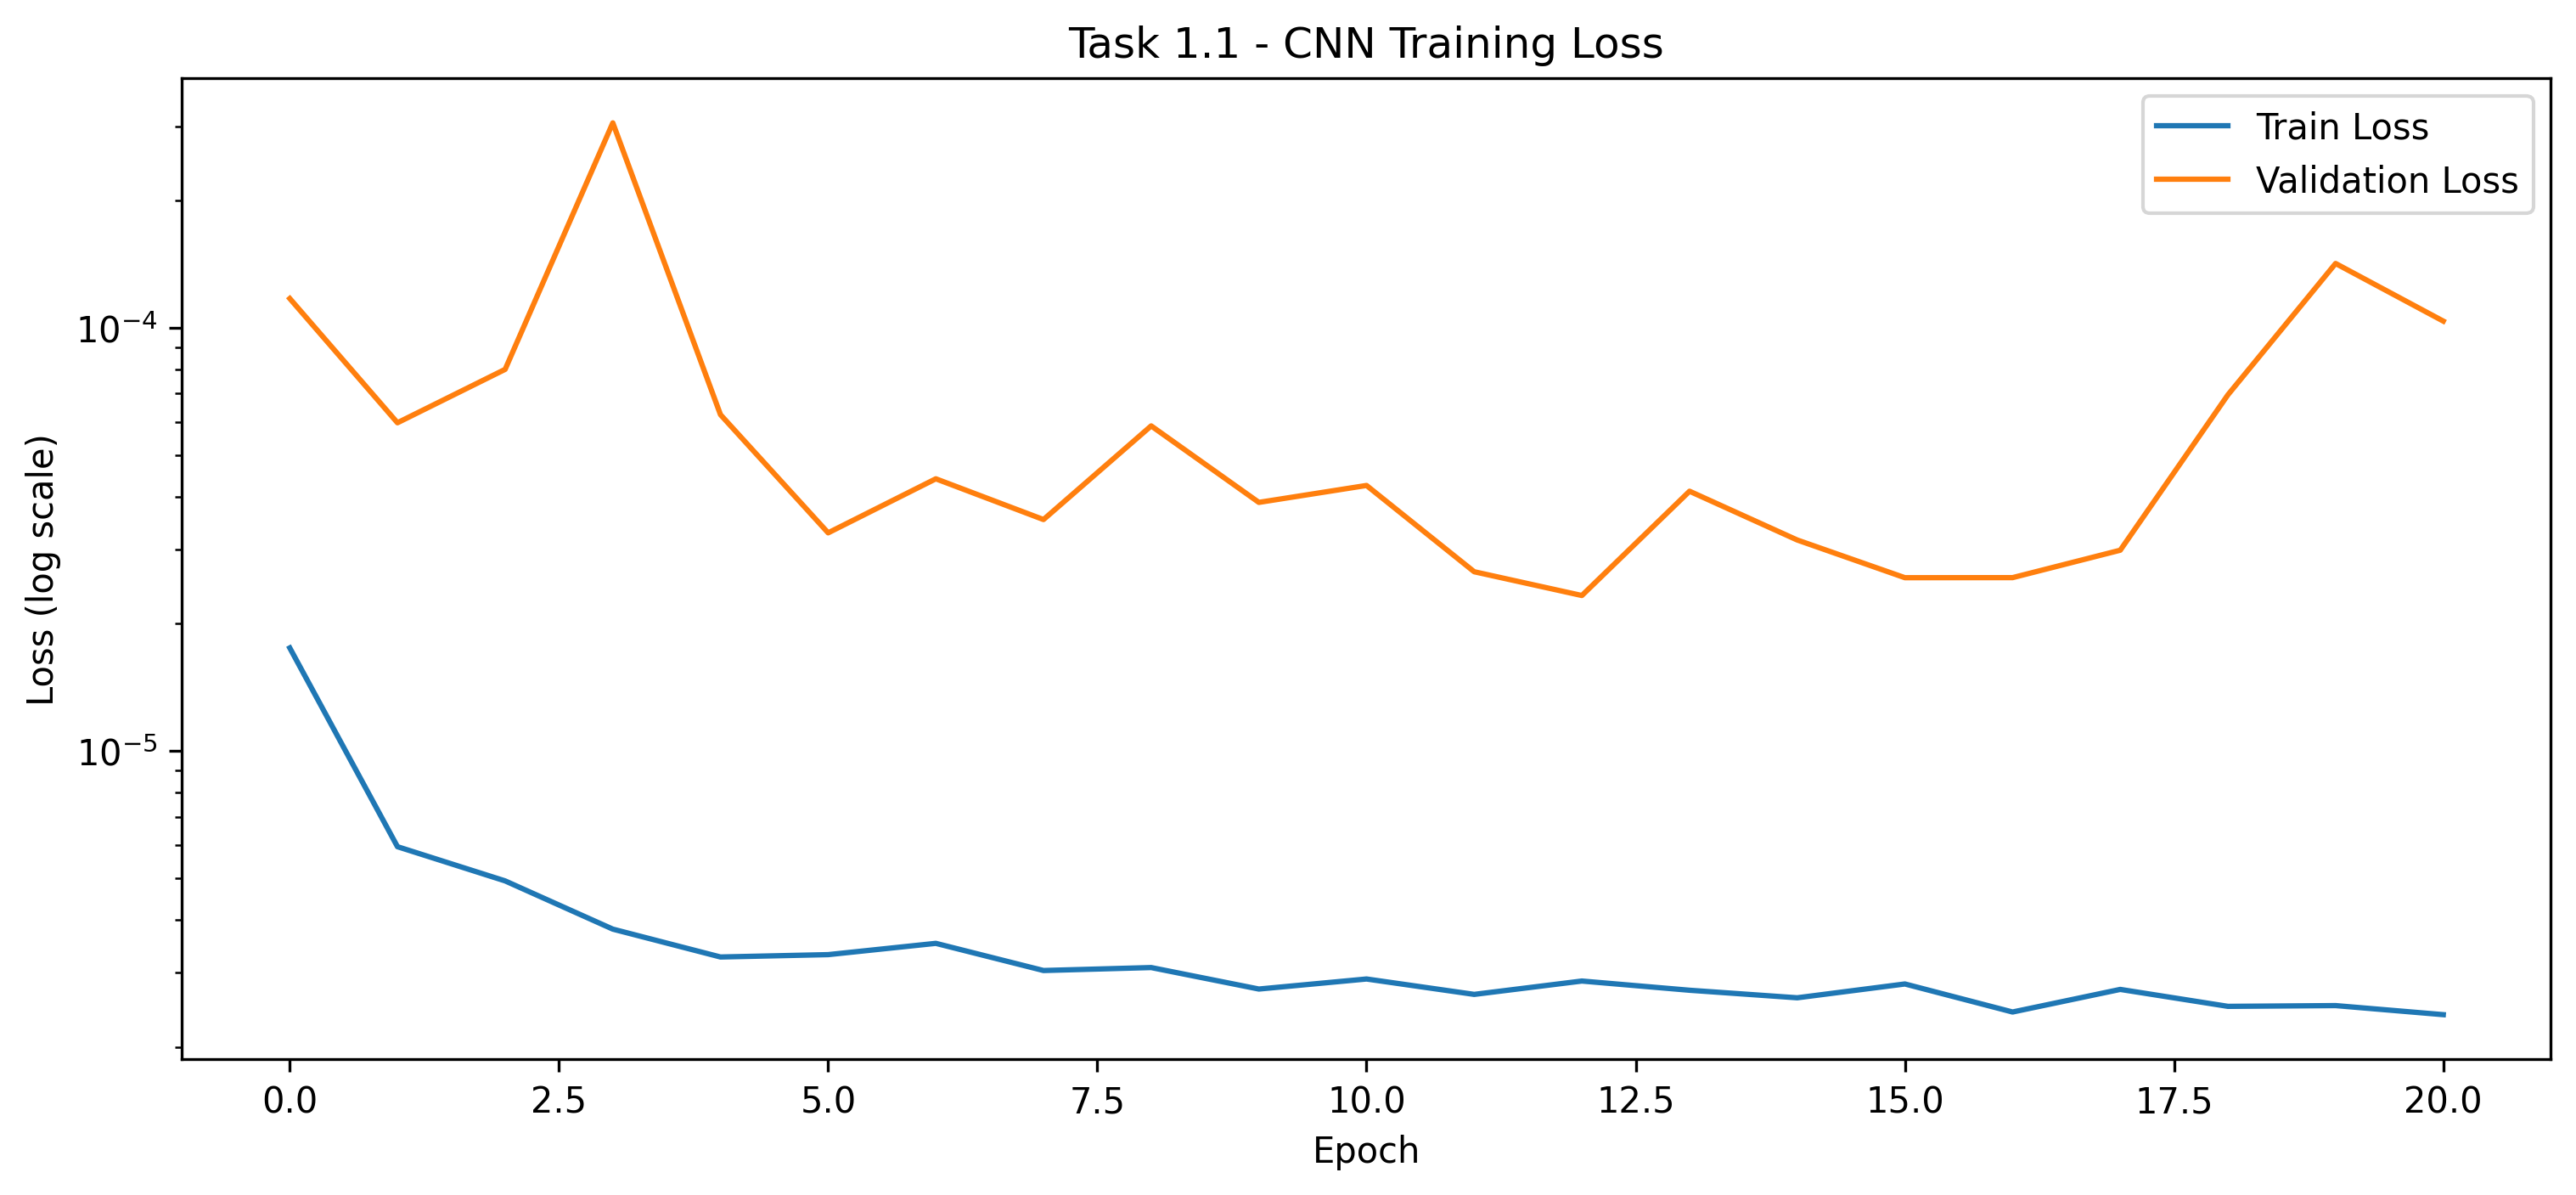

In [42]:
display(Image(
    "../results/figures/task1_1_cnn_loss_curve.png"
))

### Observation

The training and validation loss curves for Task 1.1 show that the CNN model learned effectively throughout the training process. The training loss consistently decreased over the epochs, indicating that the model successfully minimized prediction error on the training dataset.

The validation loss also remained relatively stable at a low level, which suggests that the model generalized reasonably well to unseen testing data. Although the validation loss fluctuated slightly during several epochs, no severe divergence between training and validation loss was observed. This indicates that the model did not suffer from significant overfitting.

The logarithmic scale of the graph highlights that the final training loss became extremely small after convergence, demonstrating strong optimization performance of the CNN architecture for next-day stock prediction.

Overall, the loss curves confirm that the CNN model achieved stable learning behavior and maintained a good balance between fitting the training data and preserving generalization capability on future stock market data.

## 4.7 Task 1.2 — LSTM Actual vs Predicted

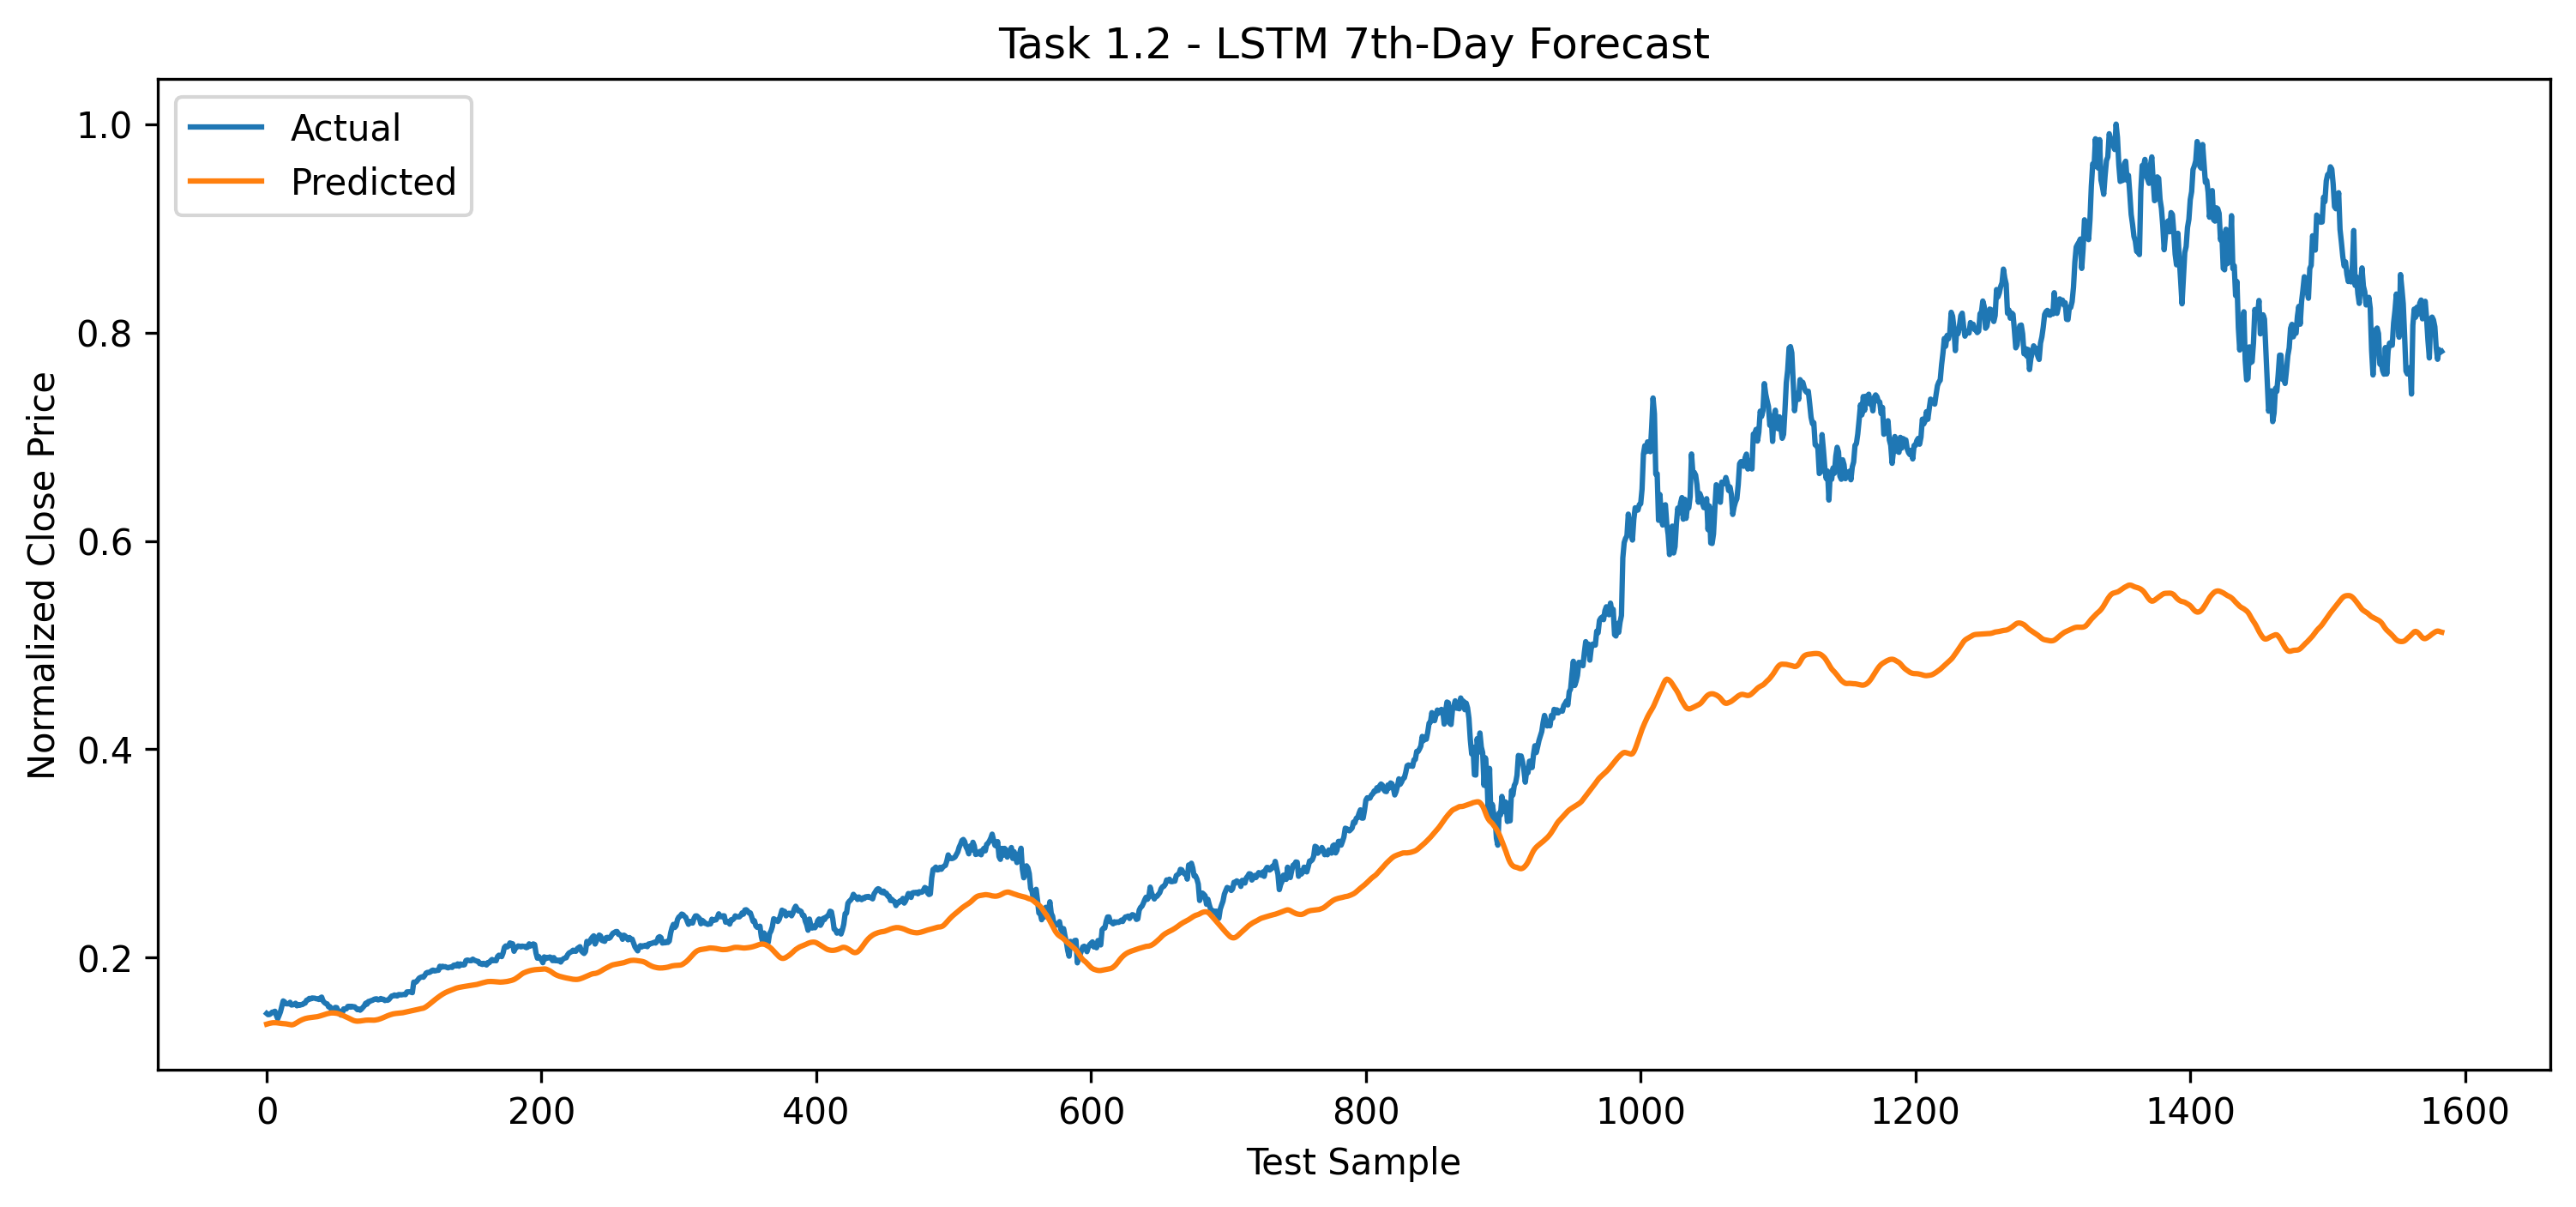

In [43]:
display(Image(
    "../results/figures/task1_2_lstm_actual_vs_predicted.png"
))

### Observation

The Task 1.2 forecasting graph illustrates the performance of the LSTM model for predicting the stock price seven days ahead. Compared to the next-day prediction task, this forecasting problem is significantly more challenging because the model must estimate future market behavior over a longer time horizon.

The graph shows that the LSTM model was able to capture the overall long-term trend of the stock movement, especially during gradual upward and downward periods. This demonstrates the advantage of the LSTM architecture in learning sequential dependencies and retaining temporal information through its memory mechanism.

However, the predicted curve appears much smoother than the actual stock price movement and fails to capture many sharp fluctuations and sudden volatility spikes in the market. As the forecasting horizon increases, prediction uncertainty also becomes larger, causing the model to lose sensitivity to short-term market changes.

The widening gap between the actual and predicted values in highly volatile regions indicates that long-term stock forecasting remains difficult due to the noisy and non-stationary nature of financial markets. This observation is also consistent with the higher RMSE and MAE values reported earlier for the 7th-day forecasting task compared to the next-day prediction task.

Overall, the results suggest that while LSTM can model long-term temporal relationships reasonably well, forecasting accuracy decreases as the prediction horizon becomes longer.

## 4.8 Task 1.2 LSTM Training Loss

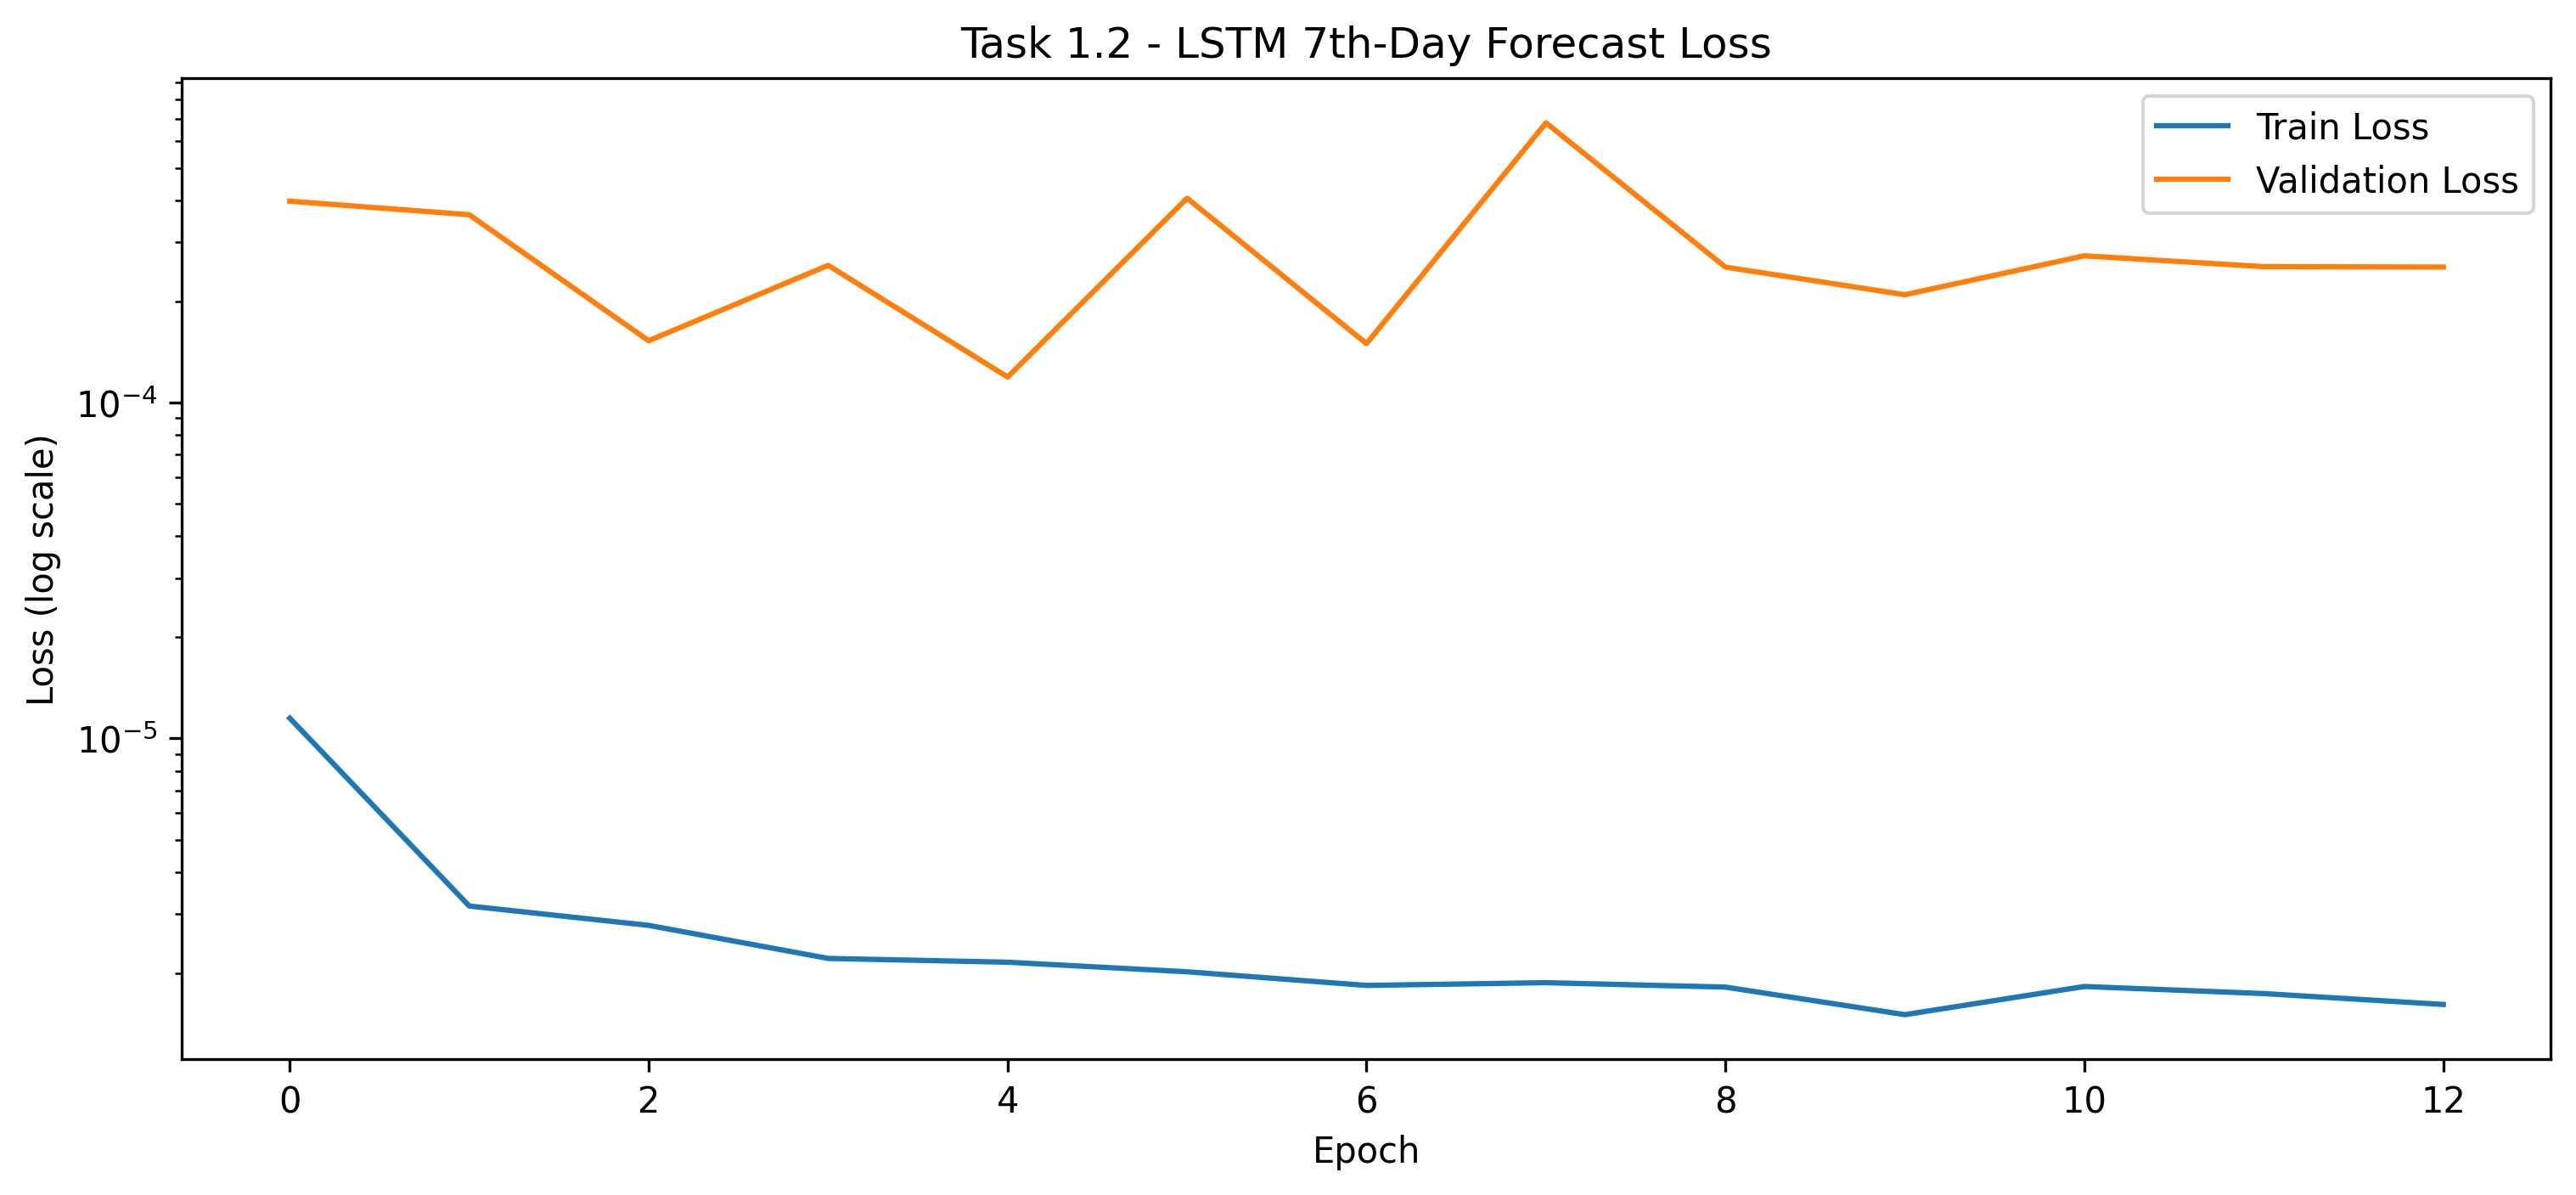

In [44]:
display(Image(
    "../results/figures/task1_2_lstm_loss_curve.png"
))

### Observation

The training and validation loss curves for the LSTM 7th-day forecasting model show that the model was able to reduce prediction error steadily during training. The training loss decreased consistently across epochs, indicating that the model successfully learned temporal patterns from the historical stock data.

However, the validation loss remained noticeably higher than the training loss throughout the training process. This suggests that although the model fit the training data well, its generalization capability on unseen future data was more limited for long-horizon forecasting tasks.

Several fluctuations can also be observed in the validation loss curve, especially during the middle training epochs. These fluctuations indicate instability caused by the increased difficulty of predicting stock prices seven days into the future. Financial markets contain high levels of uncertainty, and prediction errors naturally accumulate as the forecasting horizon becomes longer.

The gap between training and validation loss further suggests mild overfitting, where the model learns the training data more effectively than the unseen testing data. Despite this limitation, the validation loss remained relatively stable overall and did not diverge excessively, meaning the model still maintained acceptable forecasting capability.

Overall, the loss curves confirm that long-term stock forecasting is significantly more challenging than next-day prediction, and model performance decreases as temporal uncertainty increases.

## 4.9 Task 1.3 — CNN Multi-Step Forecast Example

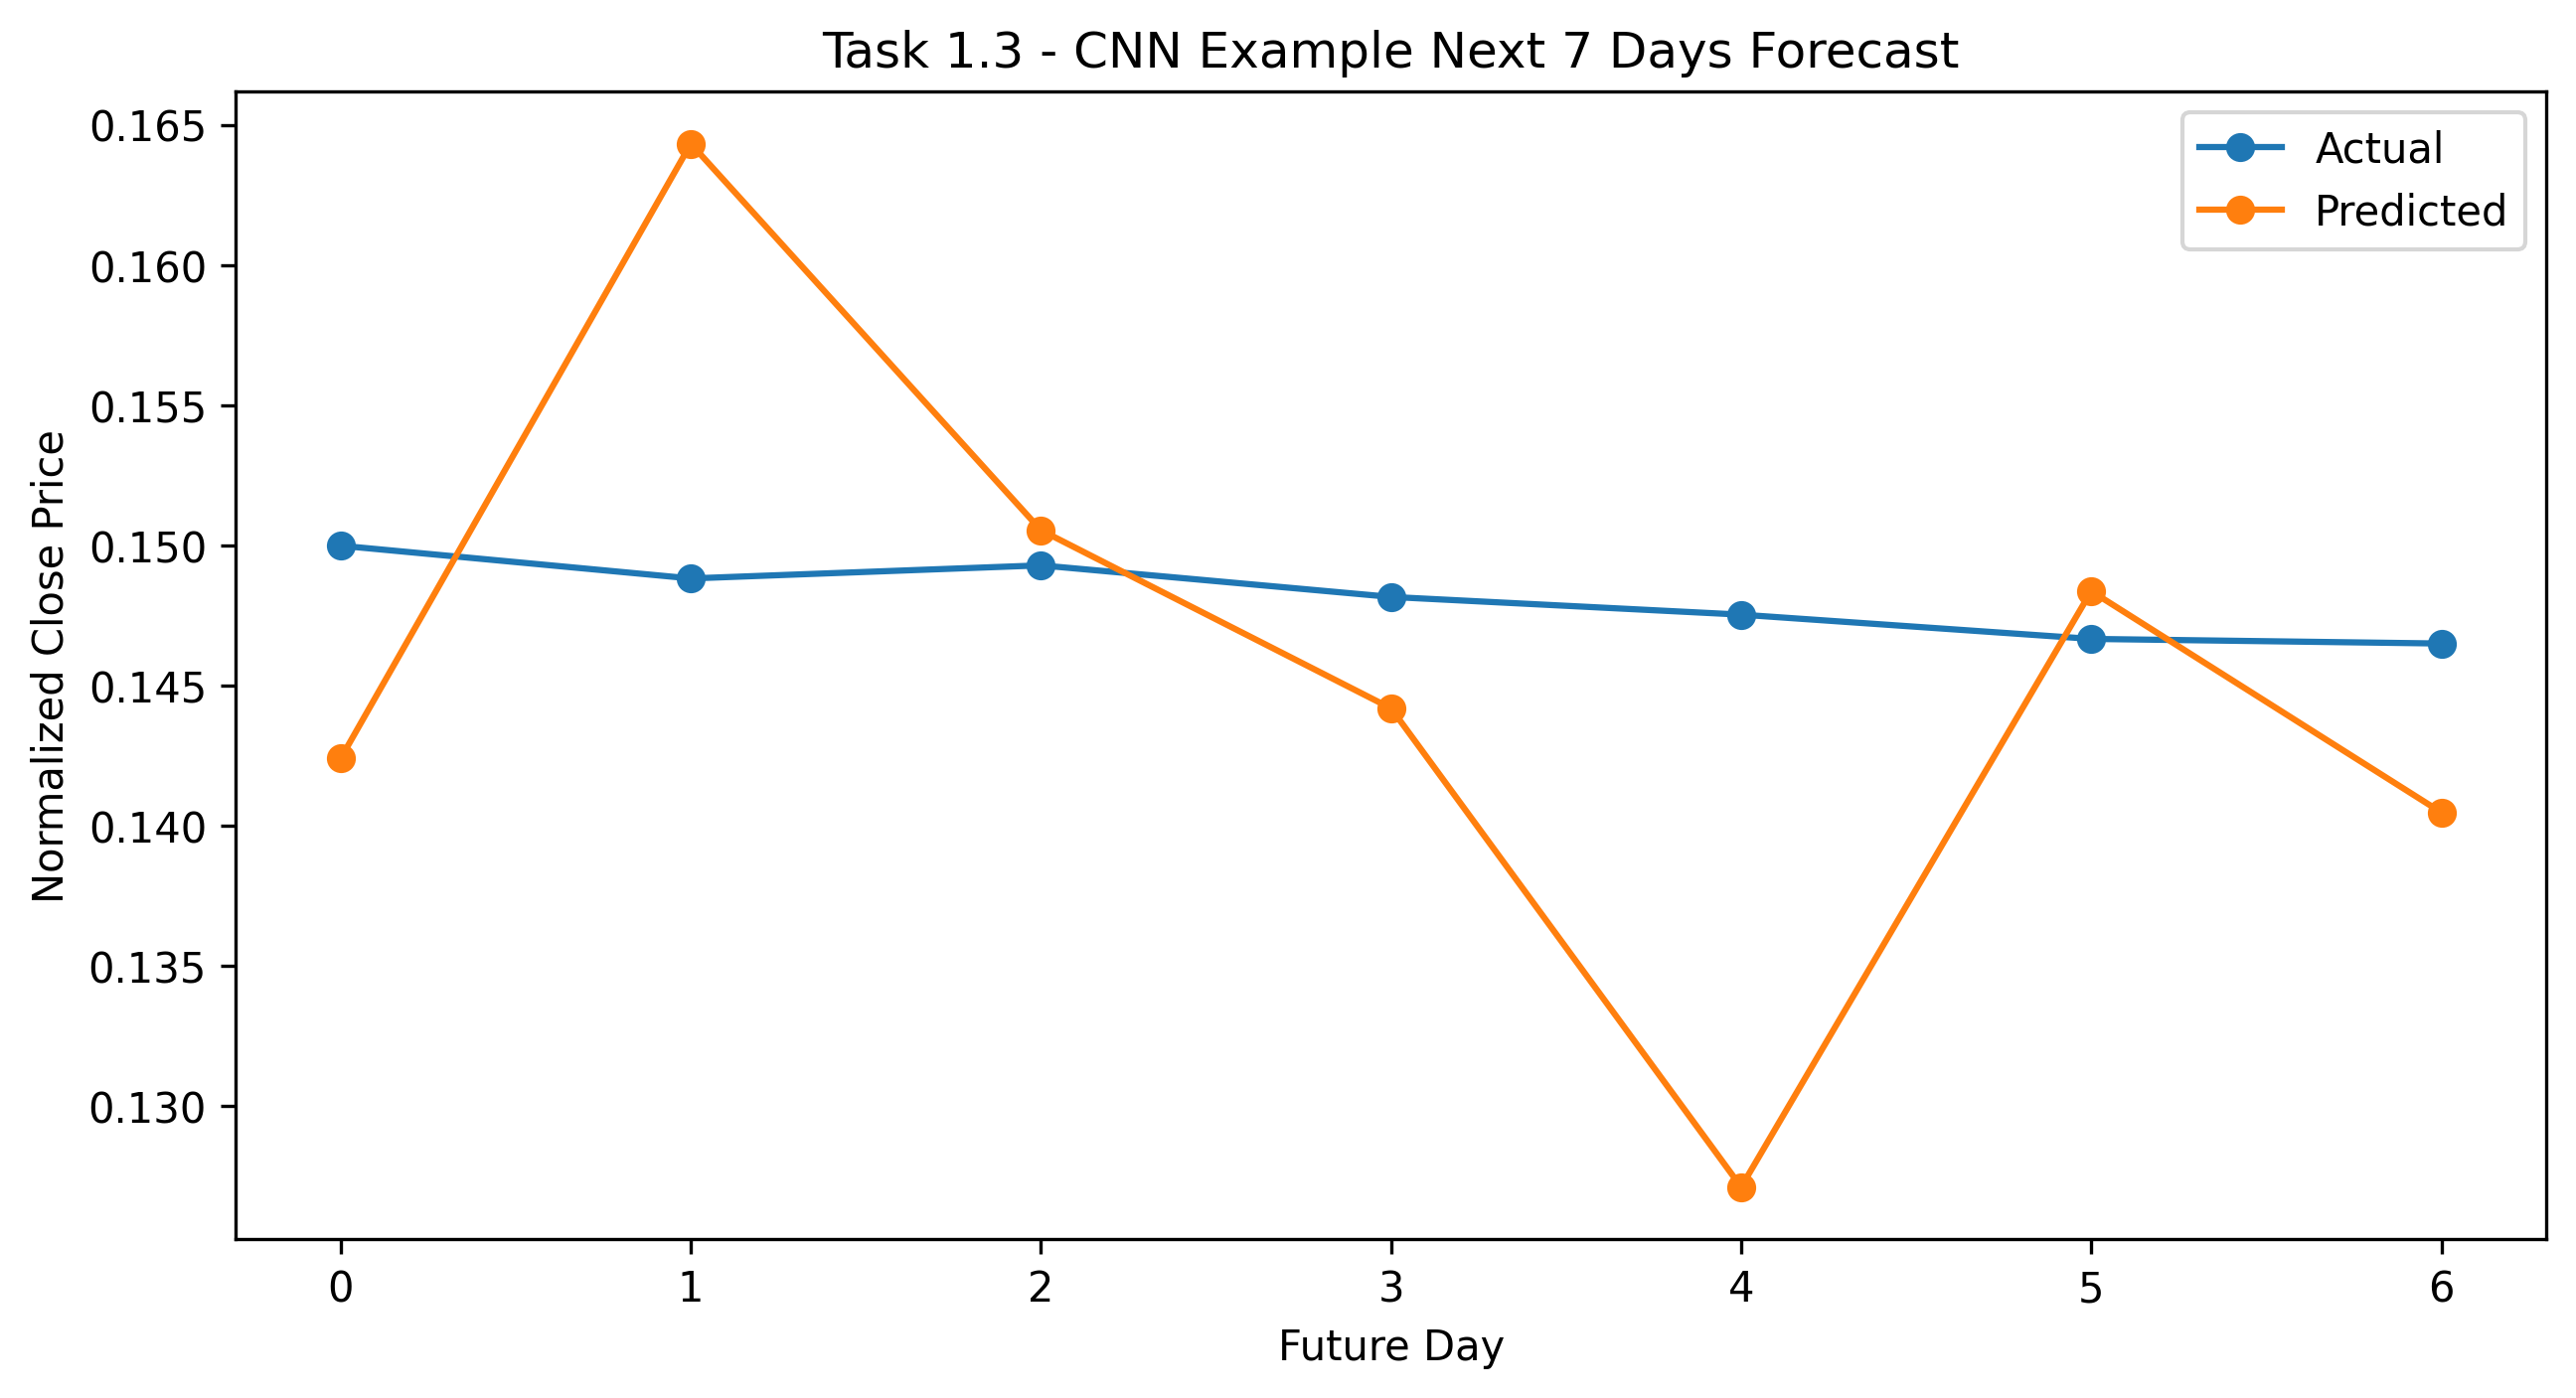

In [45]:
display(Image(
    "../results/figures/task1_3_cnn_example_forecast.png"
))

### Observation

Task 1.3 represents the most challenging forecasting problem in the Nasdaq stock prediction experiments because the model must predict multiple consecutive future prices simultaneously instead of forecasting only a single future value.

The graph compares the actual and predicted stock prices over a 7-day forecasting horizon. The CNN model was able to partially capture the general movement direction of the future stock prices, but larger deviations between the predicted and actual values can be observed compared to the previous tasks.

Several predicted points overshot or undershot the actual values, particularly around the middle forecasting days. This behavior demonstrates the difficulty of multi-step forecasting, where prediction errors accumulate over future time steps. Small inaccuracies in earlier predictions can propagate and negatively affect later predicted values.

Despite these fluctuations, the predicted curve still maintained a relatively similar overall trend compared to the actual future prices. This indicates that the CNN model learned useful temporal representations from the historical input sequence, although forecasting stability decreased as the prediction horizon expanded.

The results confirm that multi-step stock forecasting is significantly more complex than single-step forecasting due to the highly volatile and uncertain nature of financial markets. This observation is also supported by the increased RMSE and MAE values reported for Task 1.3 compared to Task 1.1 and Task 1.2.

# 5. Task 2 — Vietnam Stock Price Prediction

Task 2 extends the forecasting framework from the Nasdaq experiments to the Vietnam stock market dataset. The objective of this task is to evaluate whether deep learning models can effectively learn temporal patterns from Vietnamese financial market data and produce reliable stock price forecasts under different prediction horizons.

Similar to Task 1, the Vietnam forecasting experiments were divided into three subtasks:

- **Task 2.1:** Vietnam multi-feature next-day prediction  
- **Task 2.2:** Vietnam kth-day future prediction  
- **Task 2.3:** Vietnam multi-step next 7 days prediction  

The Vietnam dataset contains historical stock market information for multiple Vietnamese companies. For forecasting tasks, the model used several important financial input features:

- Low price  
- Open price  
- Volume  
- High price  
- Close price  

These features provide a broader representation of market behavior compared with using only closing prices. The inclusion of multiple market indicators allows the deep learning models to capture both price movement and trading activity patterns.

The same preprocessing and modeling framework from Task 1 was applied to ensure consistency across experiments. The workflow included:

- chronological sorting of time-series data,
- MinMax normalization,
- sliding window sequence generation,
- chronological train-validation-test splitting,
- and deep learning model training using CNN architectures.

A 30-day sliding input window was again used to represent historical market behavior. The models received the previous 30 trading days as input and attempted to predict future stock prices under different forecasting horizons.

The Vietnam stock market presents additional forecasting challenges compared to larger global markets because it may contain:

- stronger volatility,
- lower liquidity,
- irregular market behavior,
- and company-specific fluctuations.

As a result, forecasting performance may differ from the Nasdaq experiments even when using similar architectures and training procedures.

Task 2 focuses primarily on evaluating:

- forecasting accuracy across different horizons,
- model stability,
- generalization capability,
- and the effect of increasing temporal uncertainty on prediction quality.

The following sections present the quantitative evaluation metrics, prediction visualizations, training curves, and performance analysis for each Vietnam forecasting subtask.

## 5.1 Task 2 Results Table

In [46]:
task2_results = pd.read_csv(
    "../results/tables/task2_vietnam_results_table.csv"
)

task2_results

,Task,Model,RMSE,MAE
0,Task 2.1 - Next-day prediction,CNN,0.0465,0.0376
1,Task 2.2 - 7th day prediction,CNN,0.0925,0.0809
2,Task 2.3 - Next 7 days prediction,CNN,0.0856,0.0722


### Observation

The Task 2 results summarize the forecasting performance of the CNN model on the Vietnam stock market dataset across three different prediction tasks. The evaluation was conducted using RMSE and MAE, where lower values indicate better prediction accuracy.

The results show that the CNN model achieved the best performance on Task 2.1 (next-day prediction), with the lowest RMSE and MAE values among all Vietnam forecasting tasks. This indicates that the model was highly effective in learning short-term market patterns from recent historical stock data.

As the forecasting horizon increased in Task 2.2 (7th-day prediction) and Task 2.3 (next 7 days prediction), both RMSE and MAE increased noticeably. This behavior is expected because longer forecasting horizons introduce greater uncertainty and make stock price prediction significantly more difficult.

Interestingly, the multi-step forecasting task (Task 2.3) achieved slightly lower RMSE compared to the single 7th-day forecasting task (Task 2.2). This suggests that predicting a sequence of future prices simultaneously may help the model preserve temporal consistency better than predicting only one distant future value.

Overall, the CNN model still maintained reasonable prediction performance across all three subtasks despite the increased complexity of long-horizon forecasting. The results confirm that short-term stock prediction is generally more reliable than long-term forecasting due to the highly volatile and noisy nature of financial markets.

## 5.2 Task 2.1 — Vietnam Next-Day Prediction

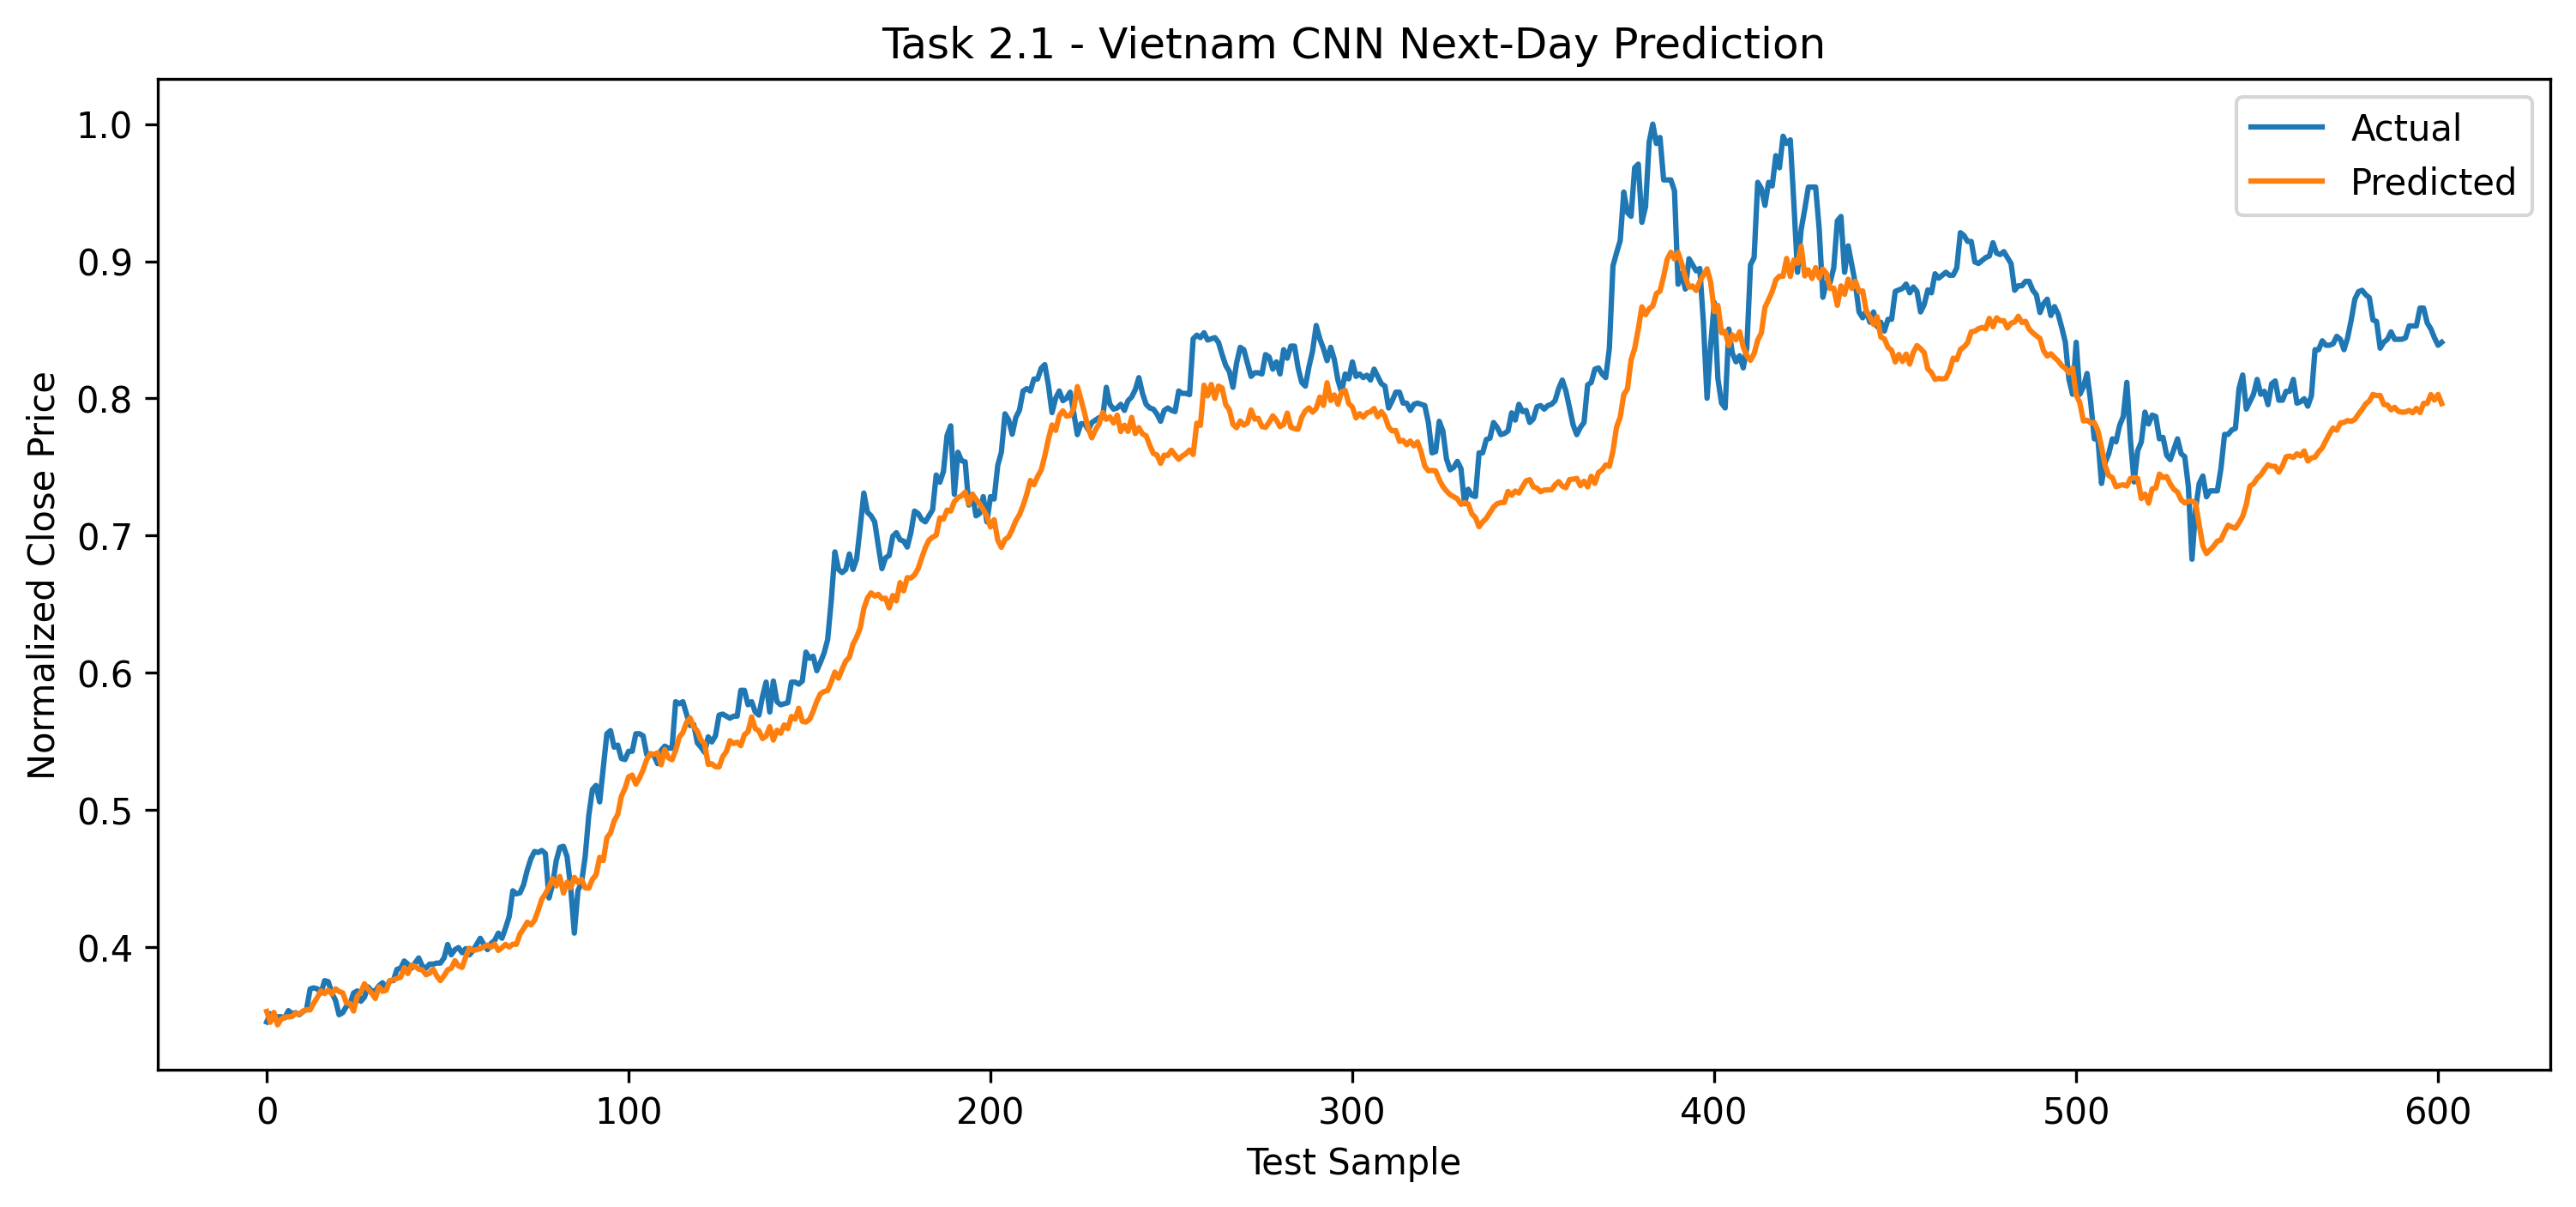

In [47]:
display(Image(
    "../results/figures/task2_1_cnn_actual_vs_predicted.png"
))

### Observation

The Task 2.1 prediction graph demonstrates that the CNN model was able to follow the overall movement of the Vietnam stock price reasonably well during the testing period. The predicted curve closely tracked the actual stock price trend across most regions of the dataset, indicating that the model successfully learned important local temporal patterns from historical Vietnam market data.

The model performed particularly well during smoother market periods, where the predicted values overlapped closely with the actual stock prices. This suggests that the CNN architecture was effective in extracting short-term trend information from the multi-feature input data, including Open, High, Low, Close, and Volume features.

However, larger deviations between the actual and predicted curves can still be observed during periods of strong market volatility, especially around sharp upward spikes and sudden corrections. In these regions, the prediction curve appears smoother than the actual movement, indicating that the model struggled to fully capture extreme short-term fluctuations.

Despite these limitations, the overall alignment between the actual and predicted values remains strong throughout the testing period. Combined with the relatively low RMSE and MAE values reported earlier, the visualization confirms that the CNN model achieved solid performance for next-day Vietnam stock price forecasting.

Overall, the results suggest that CNN-based architectures can be effectively applied to Vietnam stock market prediction tasks, particularly for short-term forecasting scenarios.

## 5.3 Task 2.1 Training Loss

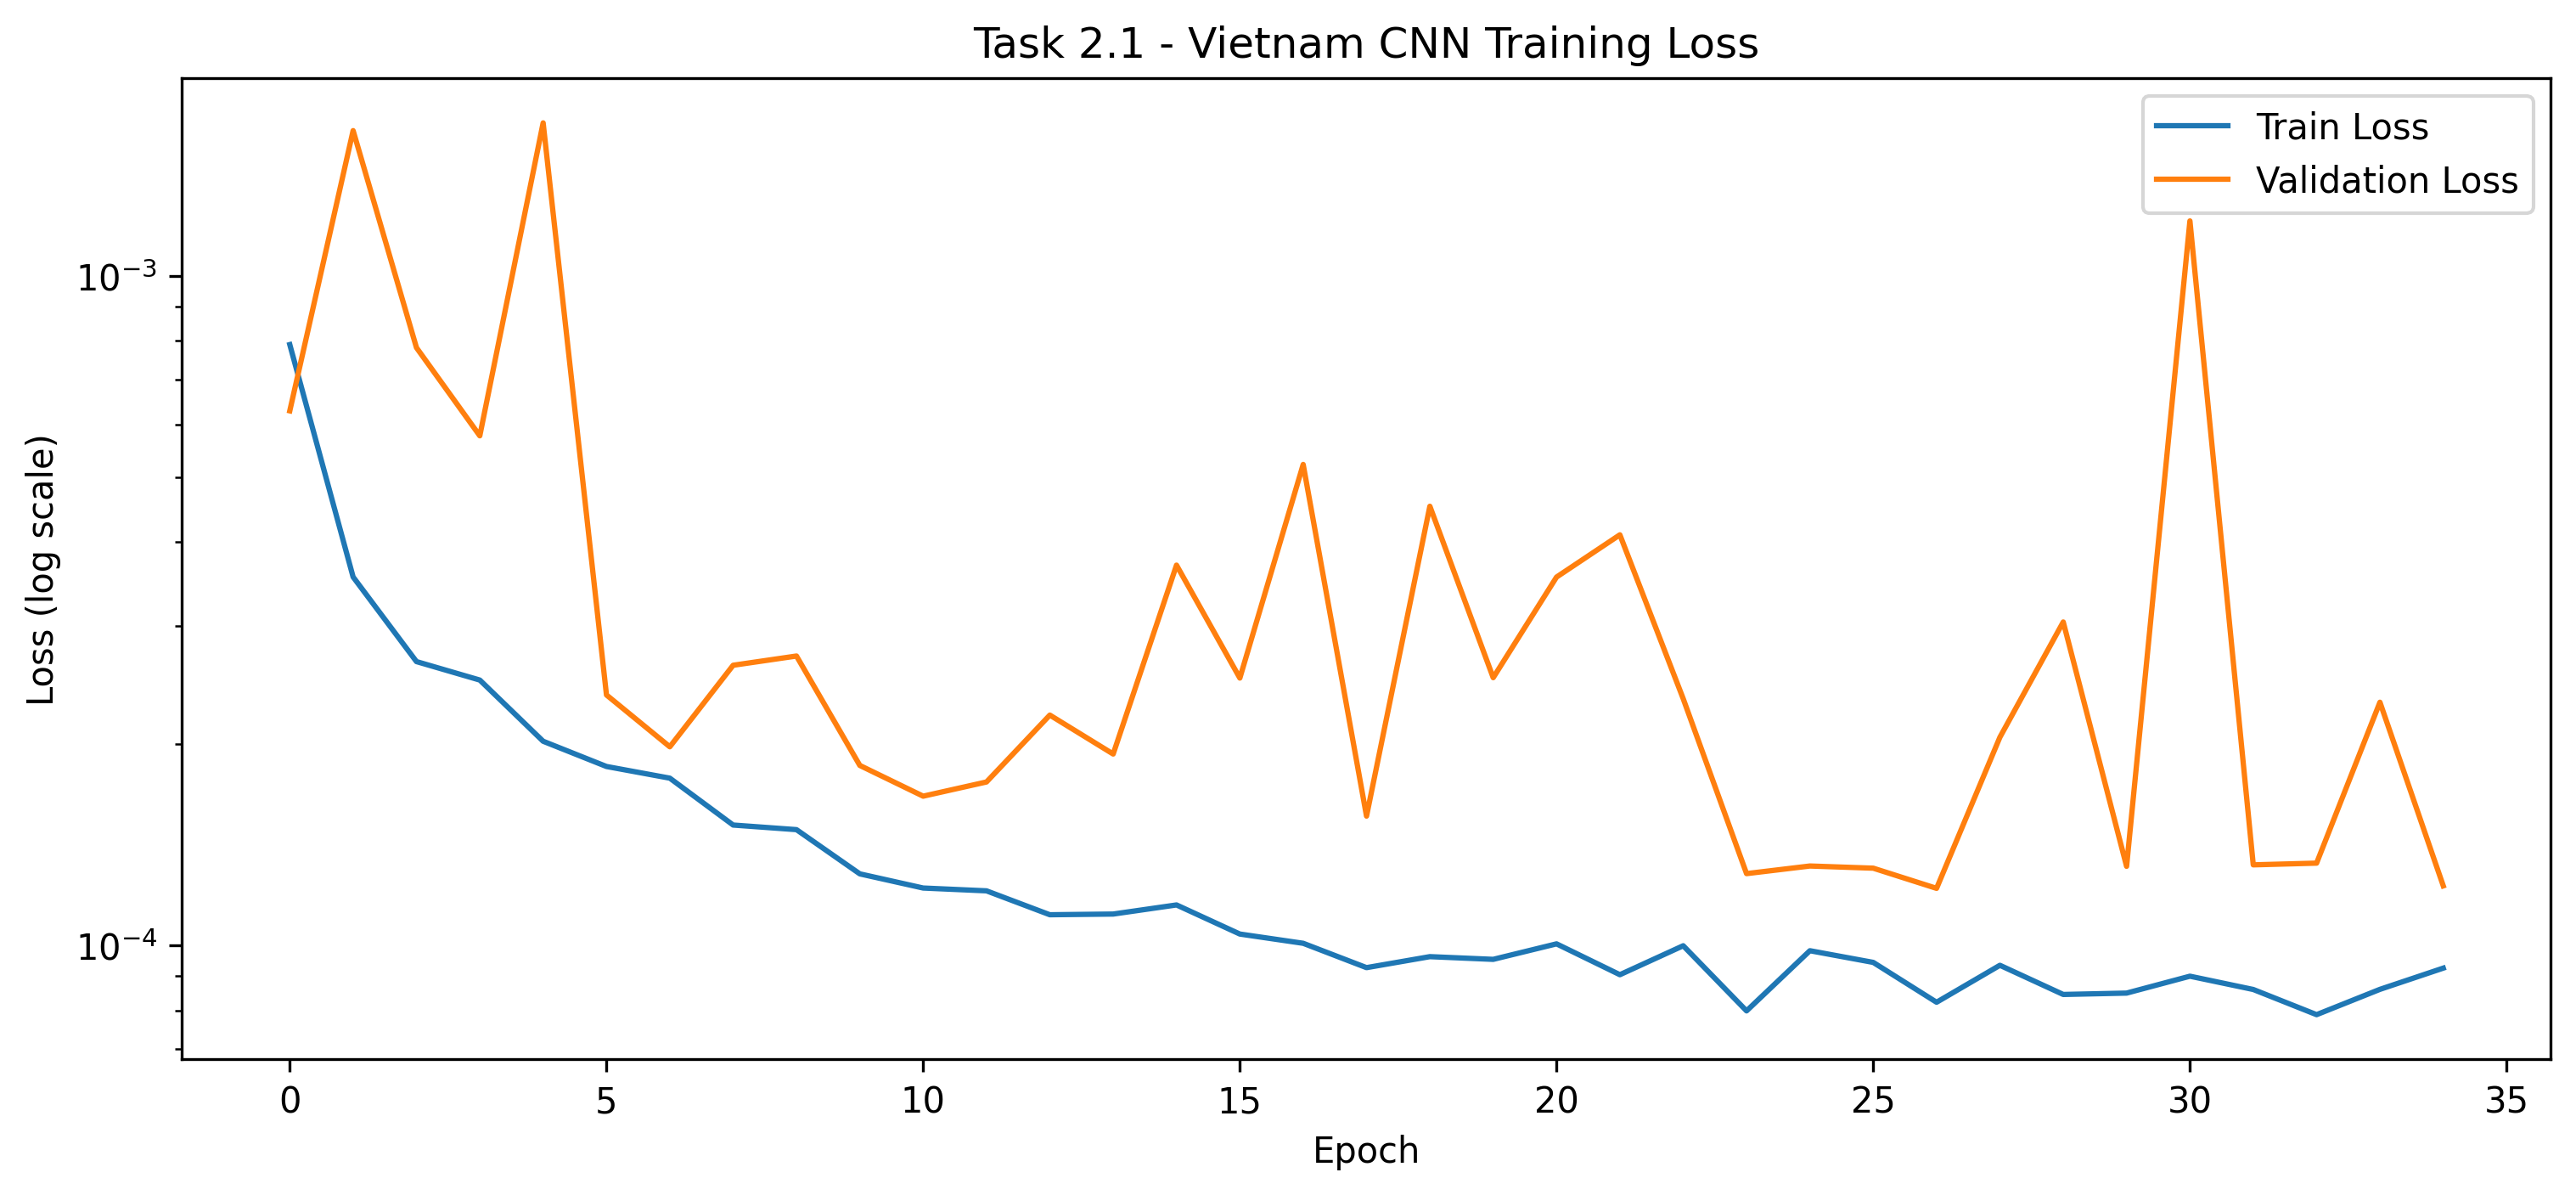

In [48]:
display(Image(
    "../results/figures/task2_1_cnn_loss_curve.png"
))

### Observation

The training loss curve for the Vietnam CNN model shows a clear downward trend throughout the training process, indicating that the model successfully learned meaningful patterns from the historical Vietnam stock market data. The reduction in training loss suggests that the CNN architecture was able to progressively minimize prediction error as the number of training epochs increased.

The validation loss also generally decreased over time, although it fluctuated more heavily compared to the training loss. These fluctuations are expected in financial forecasting tasks because stock market data is highly noisy and influenced by unpredictable external factors such as investor sentiment, macroeconomic events, and market volatility.

Despite several spikes in the validation loss, the overall validation curve remained within a relatively stable range and did not diverge continuously from the training loss. This suggests that the model maintained a reasonable level of generalization and did not suffer from severe overfitting during training.

The use of a logarithmic scale in the loss visualization also highlights that both training and validation errors stayed at relatively low magnitudes across epochs. Toward the later training stages, the training loss stabilized near its minimum value, indicating that the optimization process had largely converged.

Overall, the loss curves demonstrate that the CNN model achieved stable and effective learning behavior for Vietnam stock price forecasting, while still reflecting the inherent uncertainty and volatility present in real-world financial markets.

## 5.4 Task 2.2 — Vietnam 7th-Day Forecast

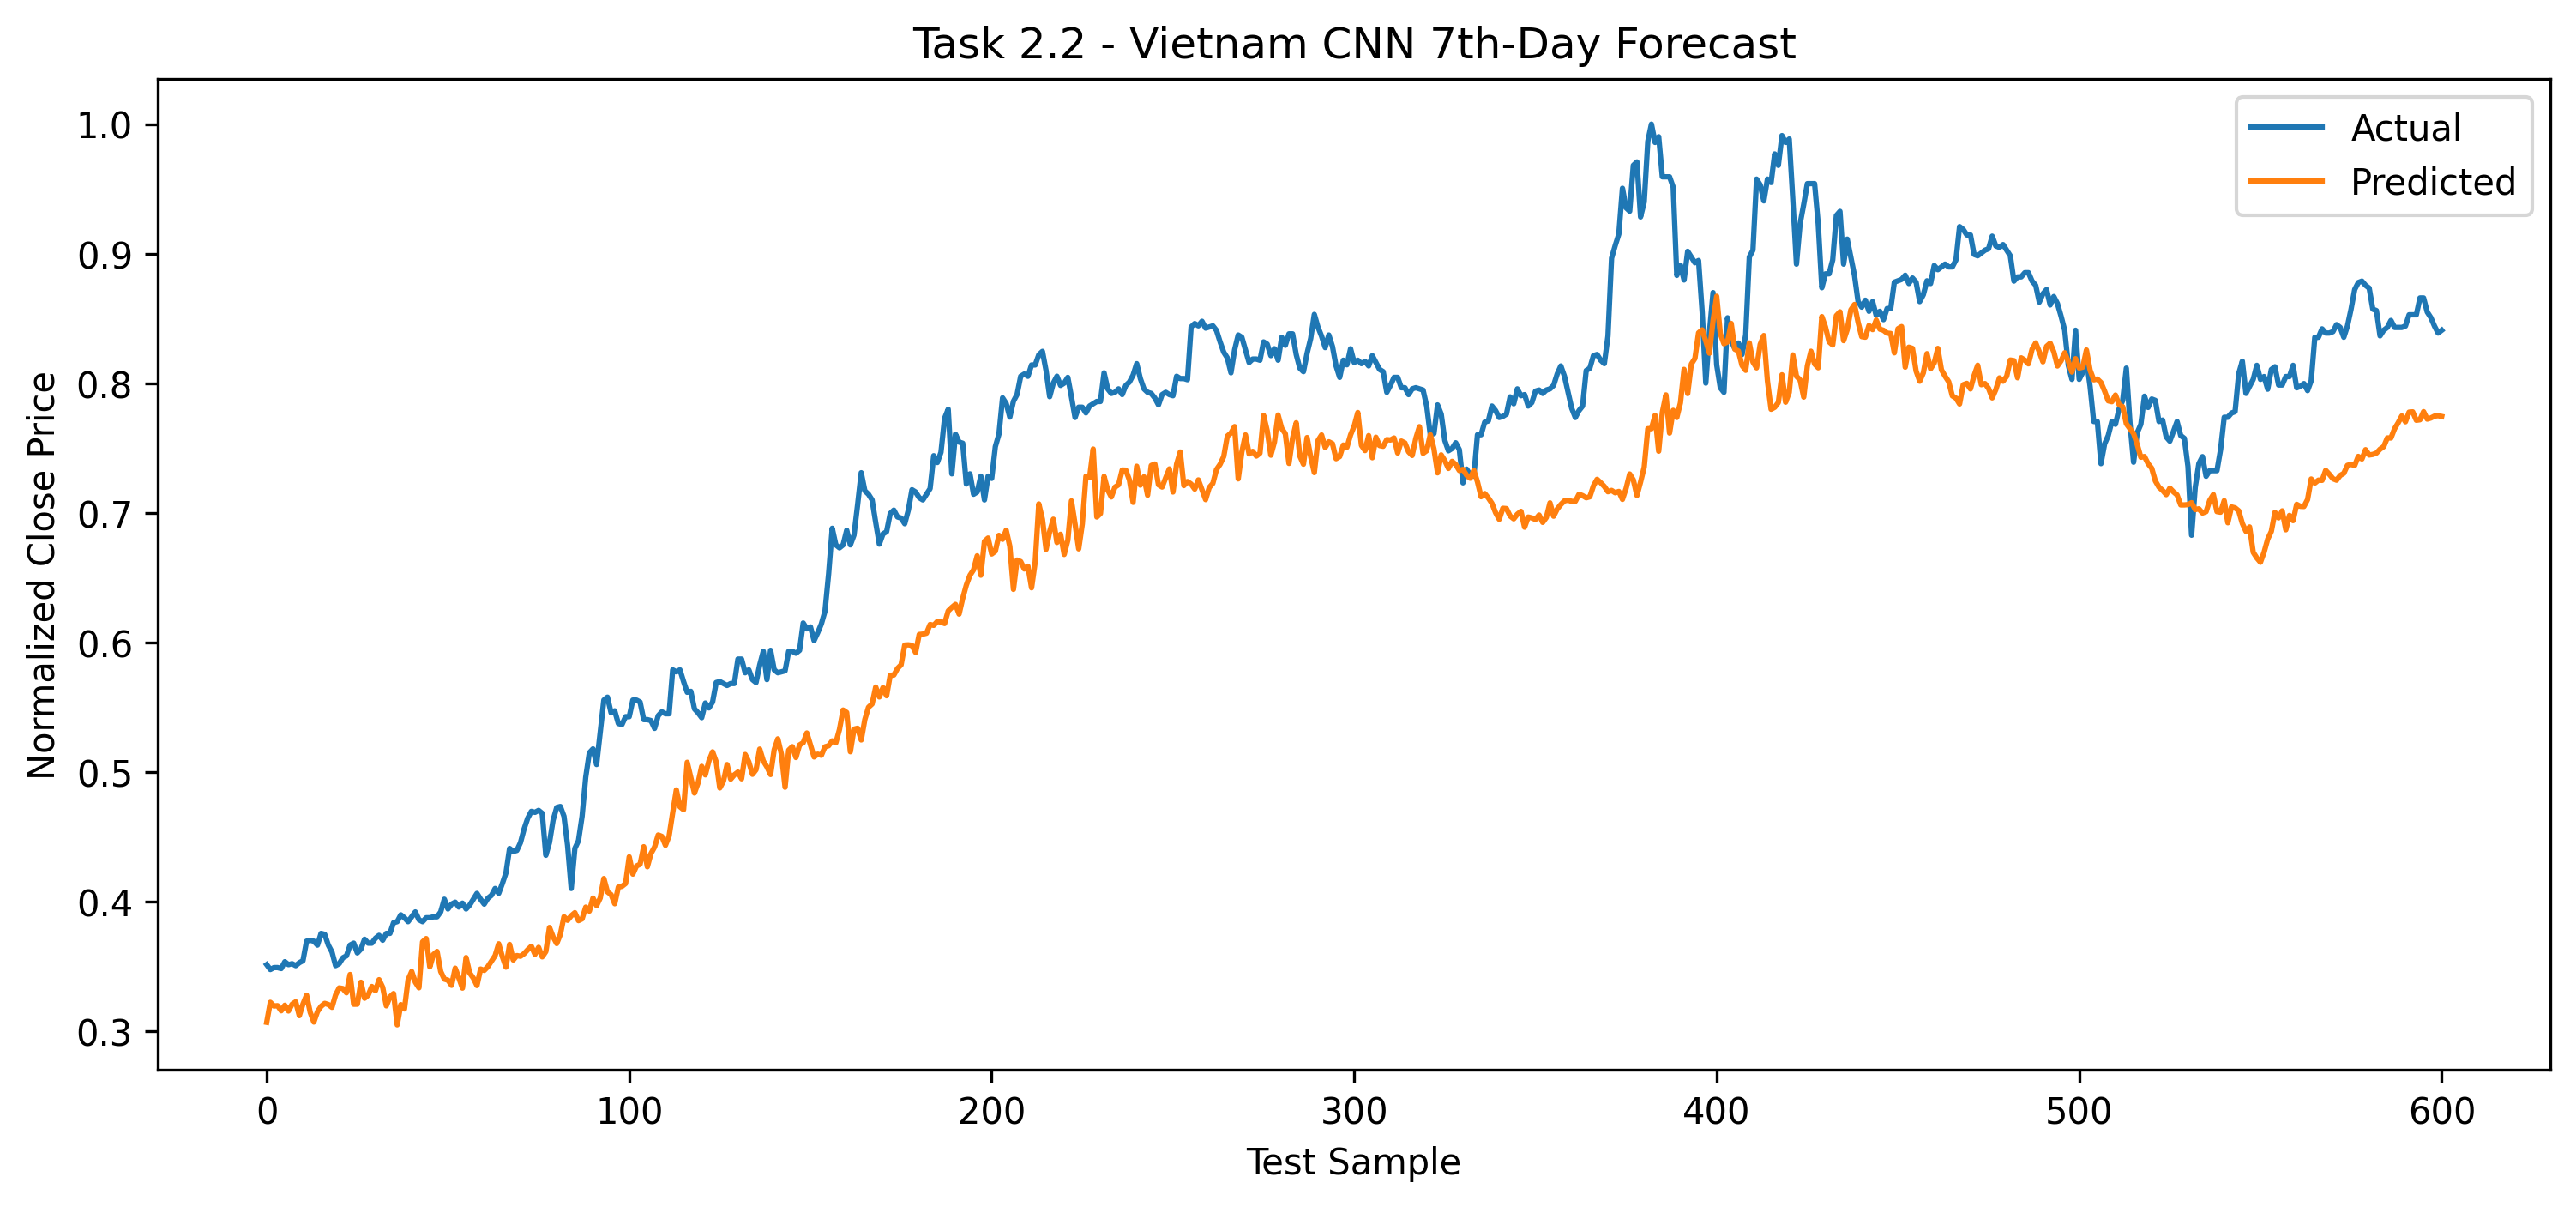

In [49]:
display(Image(
    "../results/figures/task2_2_cnn_actual_vs_predicted.png"
))

### Observation

The Task 2.2 forecasting graph illustrates the performance of the CNN model when predicting the Vietnam stock price seven days into the future. Compared with the next-day forecasting task, this prediction problem is significantly more challenging because the model must estimate future market behavior over a longer horizon, where uncertainty and accumulated forecasting error become larger.

The prediction curve generally follows the overall direction and long-term movement of the actual stock price, indicating that the CNN model was still able to capture meaningful temporal patterns from historical Vietnam stock market data. The model successfully identified major upward and downward trends throughout the testing period.

However, the predicted values appear smoother than the actual price movements and do not fully capture several sharp fluctuations and sudden spikes observed in the real market data. This behavior is common in deep learning forecasting models because longer-term predictions tend to average out short-term volatility and noise.

The gap between the actual and predicted curves becomes more noticeable during periods of high volatility, especially around rapid price increases and sudden corrections. This suggests that while the model performs reasonably well in identifying general market direction, predicting precise future price values several days ahead remains difficult due to the stochastic nature of financial markets.

Overall, the results demonstrate that the CNN model maintained stable forecasting capability for medium-term prediction tasks, although forecasting accuracy naturally decreased compared with the simpler next-day prediction scenario.

## 5.5 Task 2.2 Training Loss

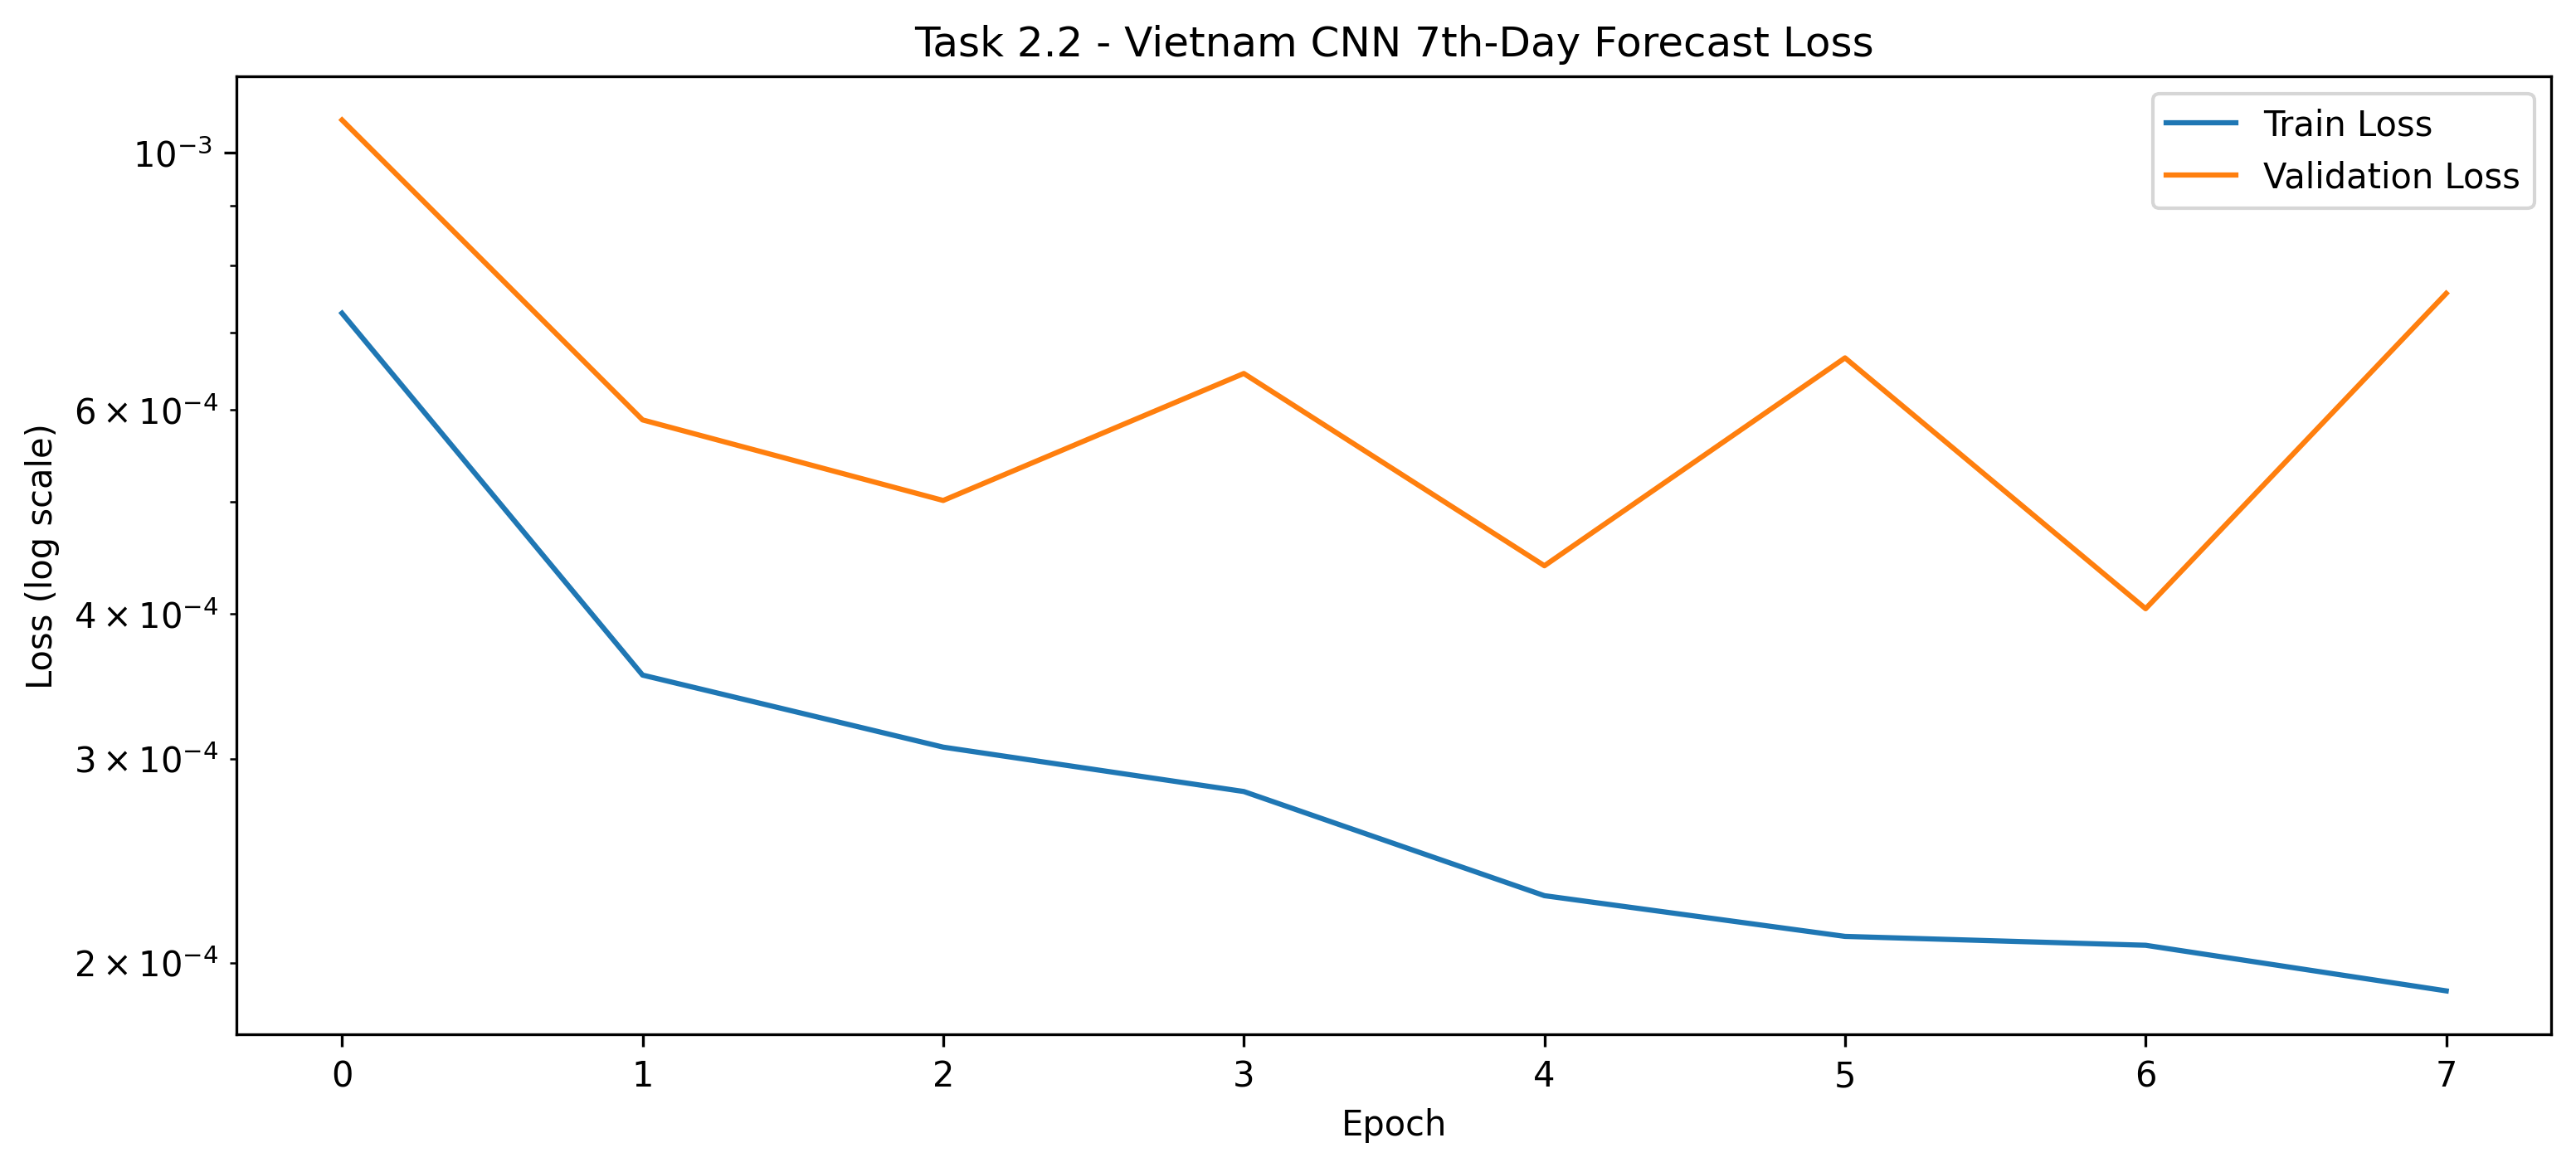

In [50]:
display(Image(
    "../results/figures/task2_2_cnn_loss_curve.png"
))

### Observation

The Task 2.2 training loss graph shows the learning behavior of the Vietnam CNN model for the 7th-day forecasting task. The training loss consistently decreased across epochs, indicating that the model successfully learned meaningful temporal features from the historical stock market data and gradually minimized prediction error during training.

Compared with the training loss, the validation loss fluctuated more noticeably throughout the training process. This behavior is expected in medium-term financial forecasting tasks because future stock prices are highly volatile and influenced by many unpredictable external factors. Despite these fluctuations, the validation loss remained within a relatively stable range and did not continuously diverge from the training loss, suggesting that the model maintained reasonable generalization ability.

The gap between training and validation loss also reflects the increased complexity of forecasting seven days ahead instead of predicting only the next trading day. Longer forecasting horizons introduce additional uncertainty and make it harder for the model to perfectly generalize to unseen future market conditions.

The logarithmic scale used in the graph highlights that both losses remained at relatively low magnitudes throughout training. Toward the final epochs, the training loss stabilized while the validation loss oscillated around a moderate level, indicating that the optimization process had largely converged.

Overall, the loss curves demonstrate that the CNN model achieved stable learning performance for medium-term Vietnam stock forecasting, although prediction difficulty naturally increased compared with short-term forecasting tasks.

## 5.6 Task 2.3 — Vietnam Multi-Step Forecast

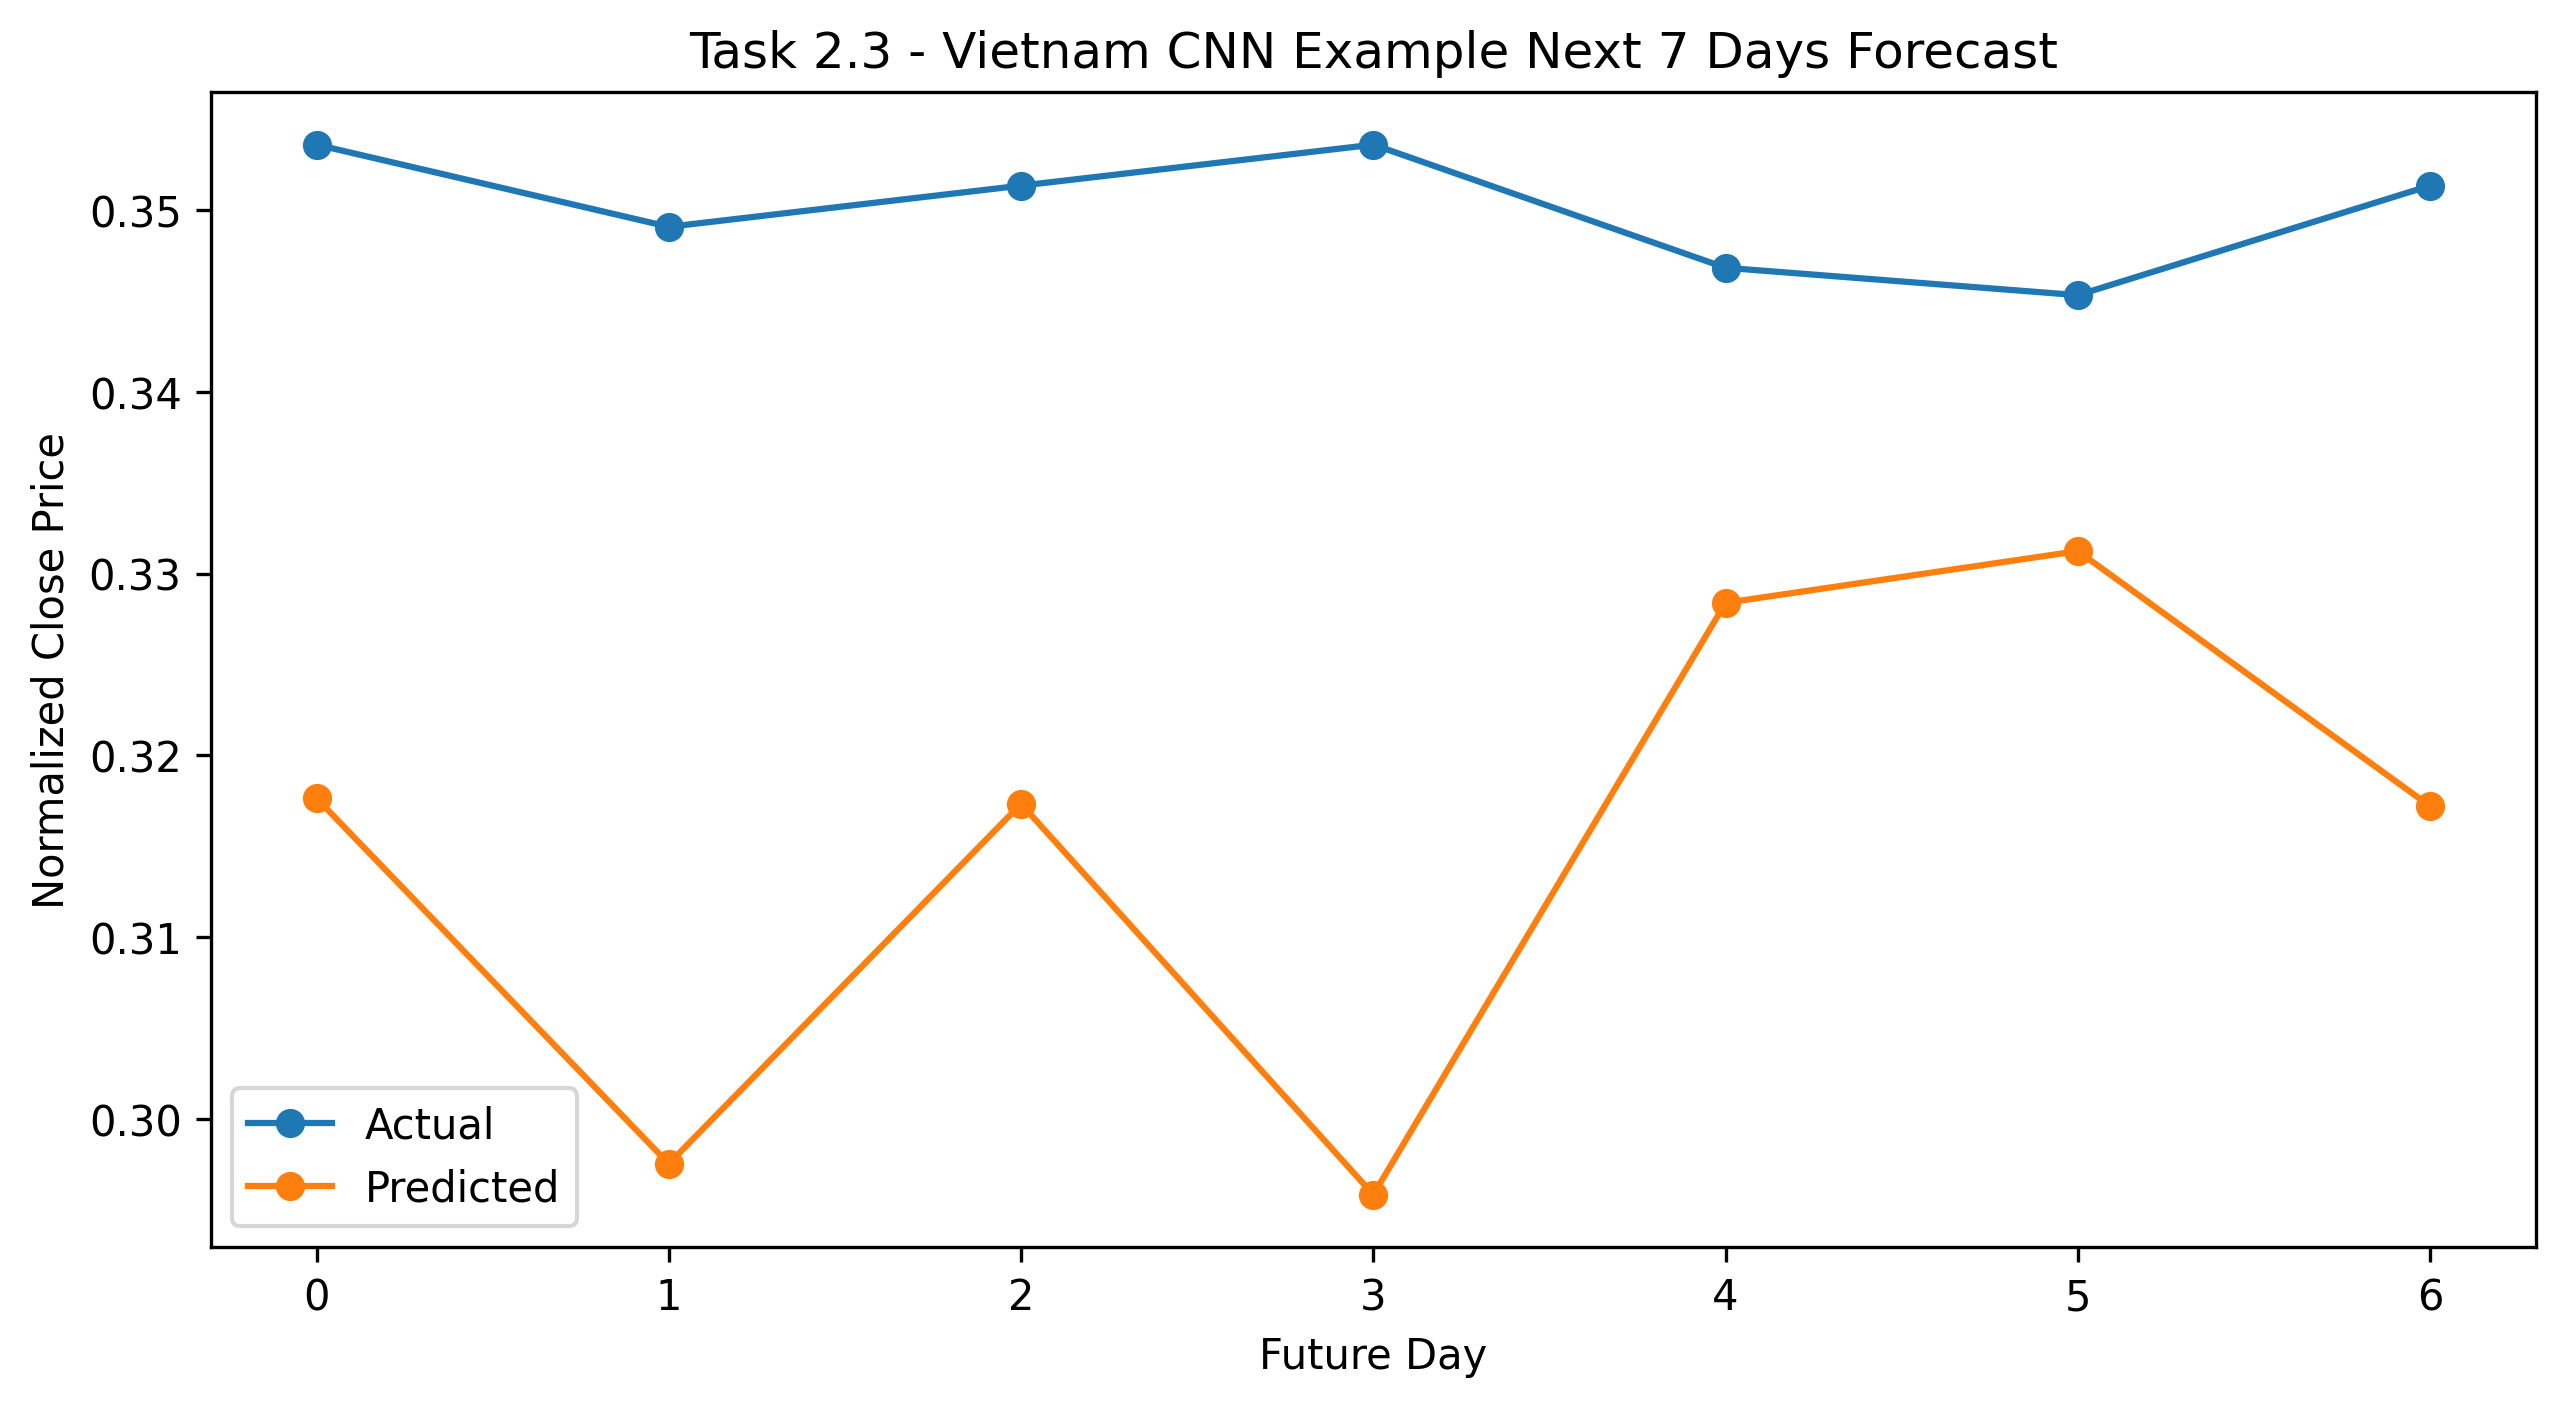

In [51]:
display(Image(
    "../results/figures/task2_3_cnn_example_forecast.png"
))

### Observation

Task 2.3 represents the most challenging Vietnam stock forecasting scenario because the CNN model must predict multiple future trading days simultaneously rather than forecasting only a single future value. In this task, prediction errors can accumulate across the forecasting horizon, making accurate multi-step prediction substantially more difficult.

The graph compares the actual and predicted normalized closing prices across the next seven future trading days. The predicted curve generally follows the overall movement direction of the actual values, indicating that the CNN model learned useful temporal patterns and was able to estimate future market behavior to some extent.

However, the predicted values consistently remain below the actual prices across most forecasted days. This suggests that the model tended to underestimate future stock prices in this particular forecasting example. Although the general trend shape was partially captured, the model struggled to accurately reproduce the magnitude of future price movements.

The differences between actual and predicted values become more noticeable at certain forecast horizons, especially around the middle future days where the prediction deviation is larger. This behavior reflects the inherent difficulty of multi-step forecasting in financial markets, where uncertainty increases further into the future and short-term errors propagate into later predictions.

Despite these limitations, the CNN model still demonstrated the ability to capture overall directional behavior and maintain relatively stable predictions across the seven-day horizon. Overall, the results confirm that multi-step Vietnam stock forecasting is significantly more complex than next-day prediction, but the model still achieved reasonable forecasting capability under highly uncertain market conditions.

## 5.7 Task 2.3 Training Loss

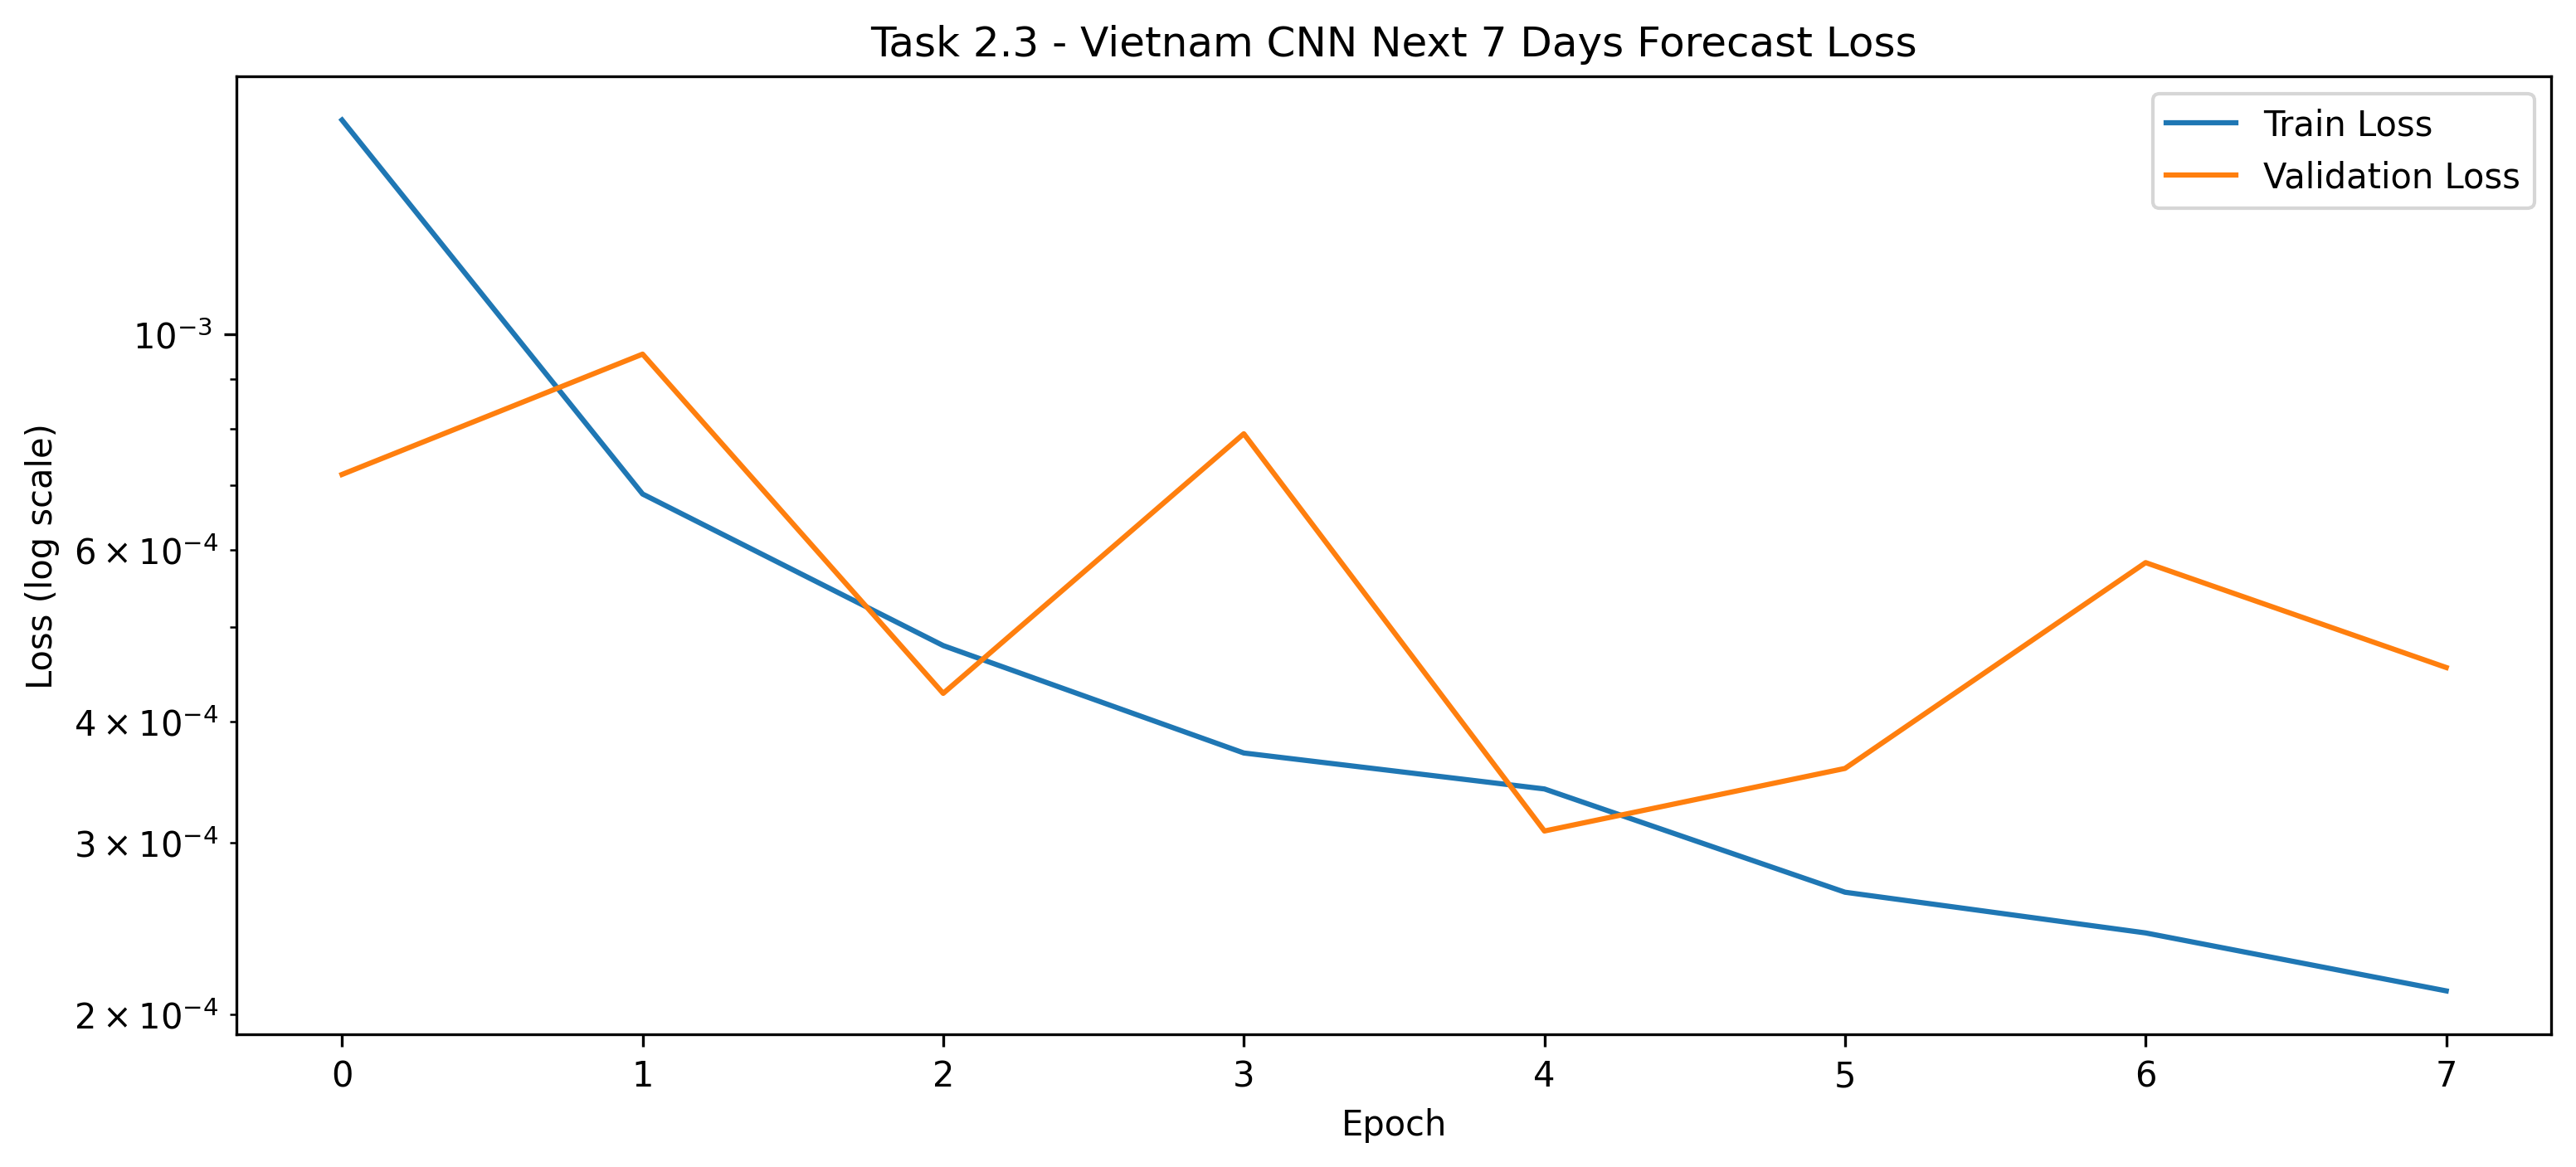

In [52]:
display(Image(
    "../results/figures/task2_3_cnn_loss_curve.png"
))

### Observation

The Task 2.3 loss curves illustrate the learning behavior of the CNN model for the multi-step Vietnam stock forecasting task, where the model predicts the next seven future trading days simultaneously. Compared with single-step forecasting tasks, this learning objective is considerably more complex because the model must minimize prediction errors across multiple future outputs at the same time.

The training loss consistently decreased throughout the training epochs, showing that the CNN model successfully learned useful temporal relationships from the historical stock price sequences. The steady decline in training loss indicates effective optimization and gradual improvement in forecasting performance during training.

The validation loss fluctuated more heavily than the training loss, which is expected in multi-step financial forecasting problems. Since future stock prices contain substantial uncertainty and volatility, predicting several days ahead becomes increasingly difficult. Small prediction errors from earlier forecast horizons can also propagate and influence later predicted values, leading to less stable validation performance.

Despite these fluctuations, the validation loss generally remained within a moderate range and did not diverge significantly from the training loss. This suggests that the model maintained acceptable generalization capability and did not experience severe overfitting during training.

The logarithmic loss scale further highlights that both training and validation losses remained relatively small throughout the optimization process. Toward the later epochs, the training loss stabilized at a low level while validation loss oscillated around a consistent range, indicating that the model had largely converged.

Overall, the loss curves demonstrate that the CNN model was capable of learning complex temporal patterns for multi-step Vietnam stock forecasting, although prediction difficulty naturally increased due to the expanded forecasting horizon and the uncertainty of future market behavior.

# 6. Task 3 — Trading Signal Identification

Task 3 extends the project from numerical stock price forecasting into financial classification problems. Instead of predicting exact future stock prices, the objective of this task is to identify potential trading opportunities by classifying market conditions into buy or sell signals.

This task transforms the problem from a regression setting into a binary classification setting.

The two main objectives are:

- Buy signal identification  
- Sell signal identification  

A buy signal indicates that the future stock return exceeds a predefined positive threshold, suggesting a potential upward market opportunity. A sell signal indicates that the future return falls below a predefined negative threshold, suggesting potential downward market movement.

Compared with price forecasting, trading signal classification is substantially more difficult because:

- financial signals are noisy and irregular,
- buy/sell opportunities occur less frequently,
- class imbalance becomes significant,
- and signal labels depend heavily on manually selected thresholds.

To improve the learning capability of the classification models, several technical indicators were engineered and added to the model inputs. These indicators help capture trend behavior, momentum, and market volatility.

The engineered features included:

- SMA (Simple Moving Average)  
- EMA (Exponential Moving Average)  
- MACD (Moving Average Convergence Divergence)  
- RSI (Relative Strength Index)  
- Volatility  
- Daily Return  

### Technical Indicator Descriptions

- **SMA** measures the average stock price over a fixed historical window and helps smooth short-term fluctuations.

- **EMA** gives more weight to recent prices, making it more responsive to recent market changes.

- **MACD** measures momentum by comparing short-term and long-term exponential moving averages.

- **RSI** is a momentum oscillator that estimates whether the stock is overbought or oversold.

- **Volatility** measures the degree of daily price fluctuation and reflects market risk.

- **Daily Return** measures percentage price change between consecutive trading days.

These technical indicators provide richer market information compared with raw stock prices alone and help the model identify hidden trading patterns.

The classification models output binary predictions:

- 1 indicates that a buy or sell signal is detected  
- 0 indicates that no signal is detected  

CNN-based binary classifiers were trained using binary cross-entropy loss. Because the datasets suffered from class imbalance, additional techniques such as class weighting and threshold adjustment were applied to encourage the models to learn minority trading signals more effectively.

Model performance was evaluated using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- Confusion matrices  

Unlike forecasting tasks where RMSE and MAE are sufficient, classification metrics are particularly important here because overall accuracy alone may become misleading when positive trading signals are relatively rare.

The following sections present the classification results, confusion matrices, loss curves, and analysis for both buy and sell signal identification tasks.

## 6.1 Task 3 Results Table

In [53]:
task3_results = pd.read_csv(
    "../results/tables/task3_signal_results_table.csv"
)

task3_results

,Task,Model,Accuracy,Precision,Recall,F1
0,Task 3.1 - Buy Signal Identification,CNN Binary Classifier,0.5268,0.0000,0.000,0.0000
1,Task 3.2 - Sell Signal Identification,CNN Binary Classifier,0.7425,0.0769,0.007,0.0128


### Observation

The Task 3 classification results indicate that the CNN binary classification models faced significant difficulty in accurately identifying buy and sell trading signals from historical stock market data.

For Task 3.1 (Buy Signal Identification), the model achieved an accuracy of approximately 52.68%, but both precision, recall, and F1-score remained at 0. This indicates that the classifier failed to correctly identify positive buy signals and primarily predicted the majority class instead. Although the overall accuracy appears moderate, the evaluation metrics reveal that the model was not effective at detecting actual buy opportunities.

For Task 3.2 (Sell Signal Identification), the model achieved a higher accuracy of approximately 74.25%. However, the precision, recall, and F1-score for the sell class remained extremely low. The recall value of only 0.007 indicates that the model identified very few true sell signals, while the low precision suggests that many predicted sell signals were incorrect.

These results suggest that the dataset likely suffered from class imbalance, where positive trading signals occurred much less frequently than normal market conditions. In such situations, the model tends to favor predicting the dominant negative class to minimize overall classification loss, leading to deceptively high accuracy but very weak signal detection performance.

The findings also highlight the inherent difficulty of financial signal classification tasks. Buy and sell opportunities are often noisy, irregular, and highly sensitive to short-term market fluctuations, making them substantially harder to classify than continuous price forecasting tasks.

Overall, the Task 3 results demonstrate that while the CNN classifier was able to learn some general market behavior, accurately identifying actionable trading signals remains a challenging problem and would likely require additional feature engineering, improved class balancing techniques, or more advanced architectures to achieve stronger classification performance.

## 6.2 Task 3.1 — Buy Signal Confusion Matrix

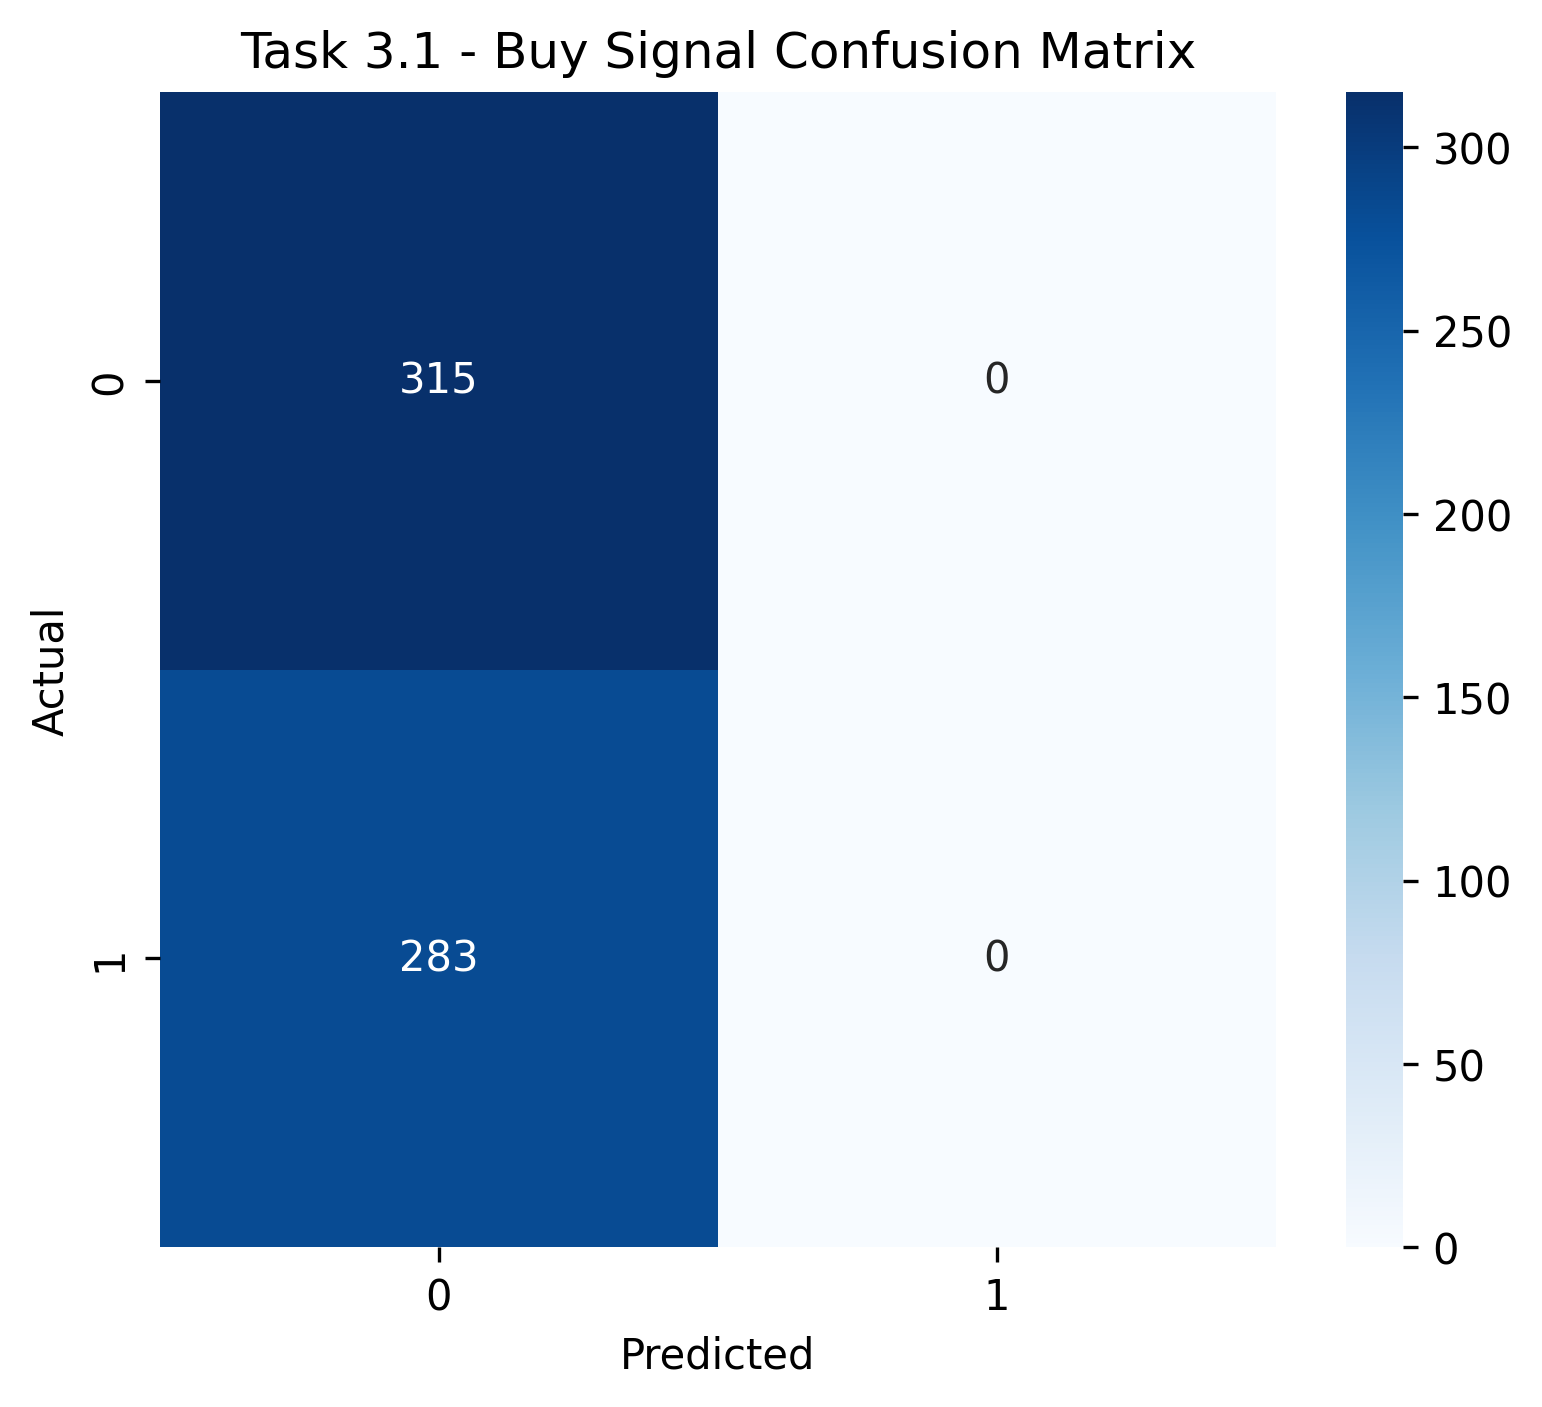

In [54]:
display(Image(
    "../results/figures/task3_1_buy_confusion_matrix.png"
))

### Observation

The confusion matrix for Task 3.1 reveals that the CNN classifier struggled to identify buy signals effectively. The model predicted every sample as class 0 (non-buy signal), resulting in no positive buy signal predictions across the entire test dataset.

The matrix shows that all 315 non-buy samples were correctly classified as class 0, which contributed to the moderate overall accuracy. However, all 283 actual buy signal samples were incorrectly classified as non-buy signals, producing a large number of false negatives and zero true positives.

As a result, the model achieved zero precision, zero recall, and zero F1-score for the buy signal class. This indicates that the classifier completely failed to detect positive buy opportunities during evaluation.

The behavior observed in the confusion matrix strongly suggests the presence of class imbalance or insufficient discriminative learning during training. The model learned to favor the majority class because predicting only the dominant class minimized the overall classification loss, even though it produced poor practical trading performance.

From a financial prediction perspective, this outcome is problematic because missing all buy opportunities would make the trading system ineffective in real-world investment scenarios. Although the model achieved reasonable accuracy numerically, the confusion matrix demonstrates that accuracy alone is not sufficient for evaluating imbalanced financial classification problems.

Overall, the confusion matrix highlights the importance of using additional evaluation metrics such as precision, recall, and F1-score when assessing trading signal classifiers, especially in datasets where positive trading signals occur less frequently than normal market conditions.

## 6.3 Task 3.1 Buy Signal Training Loss

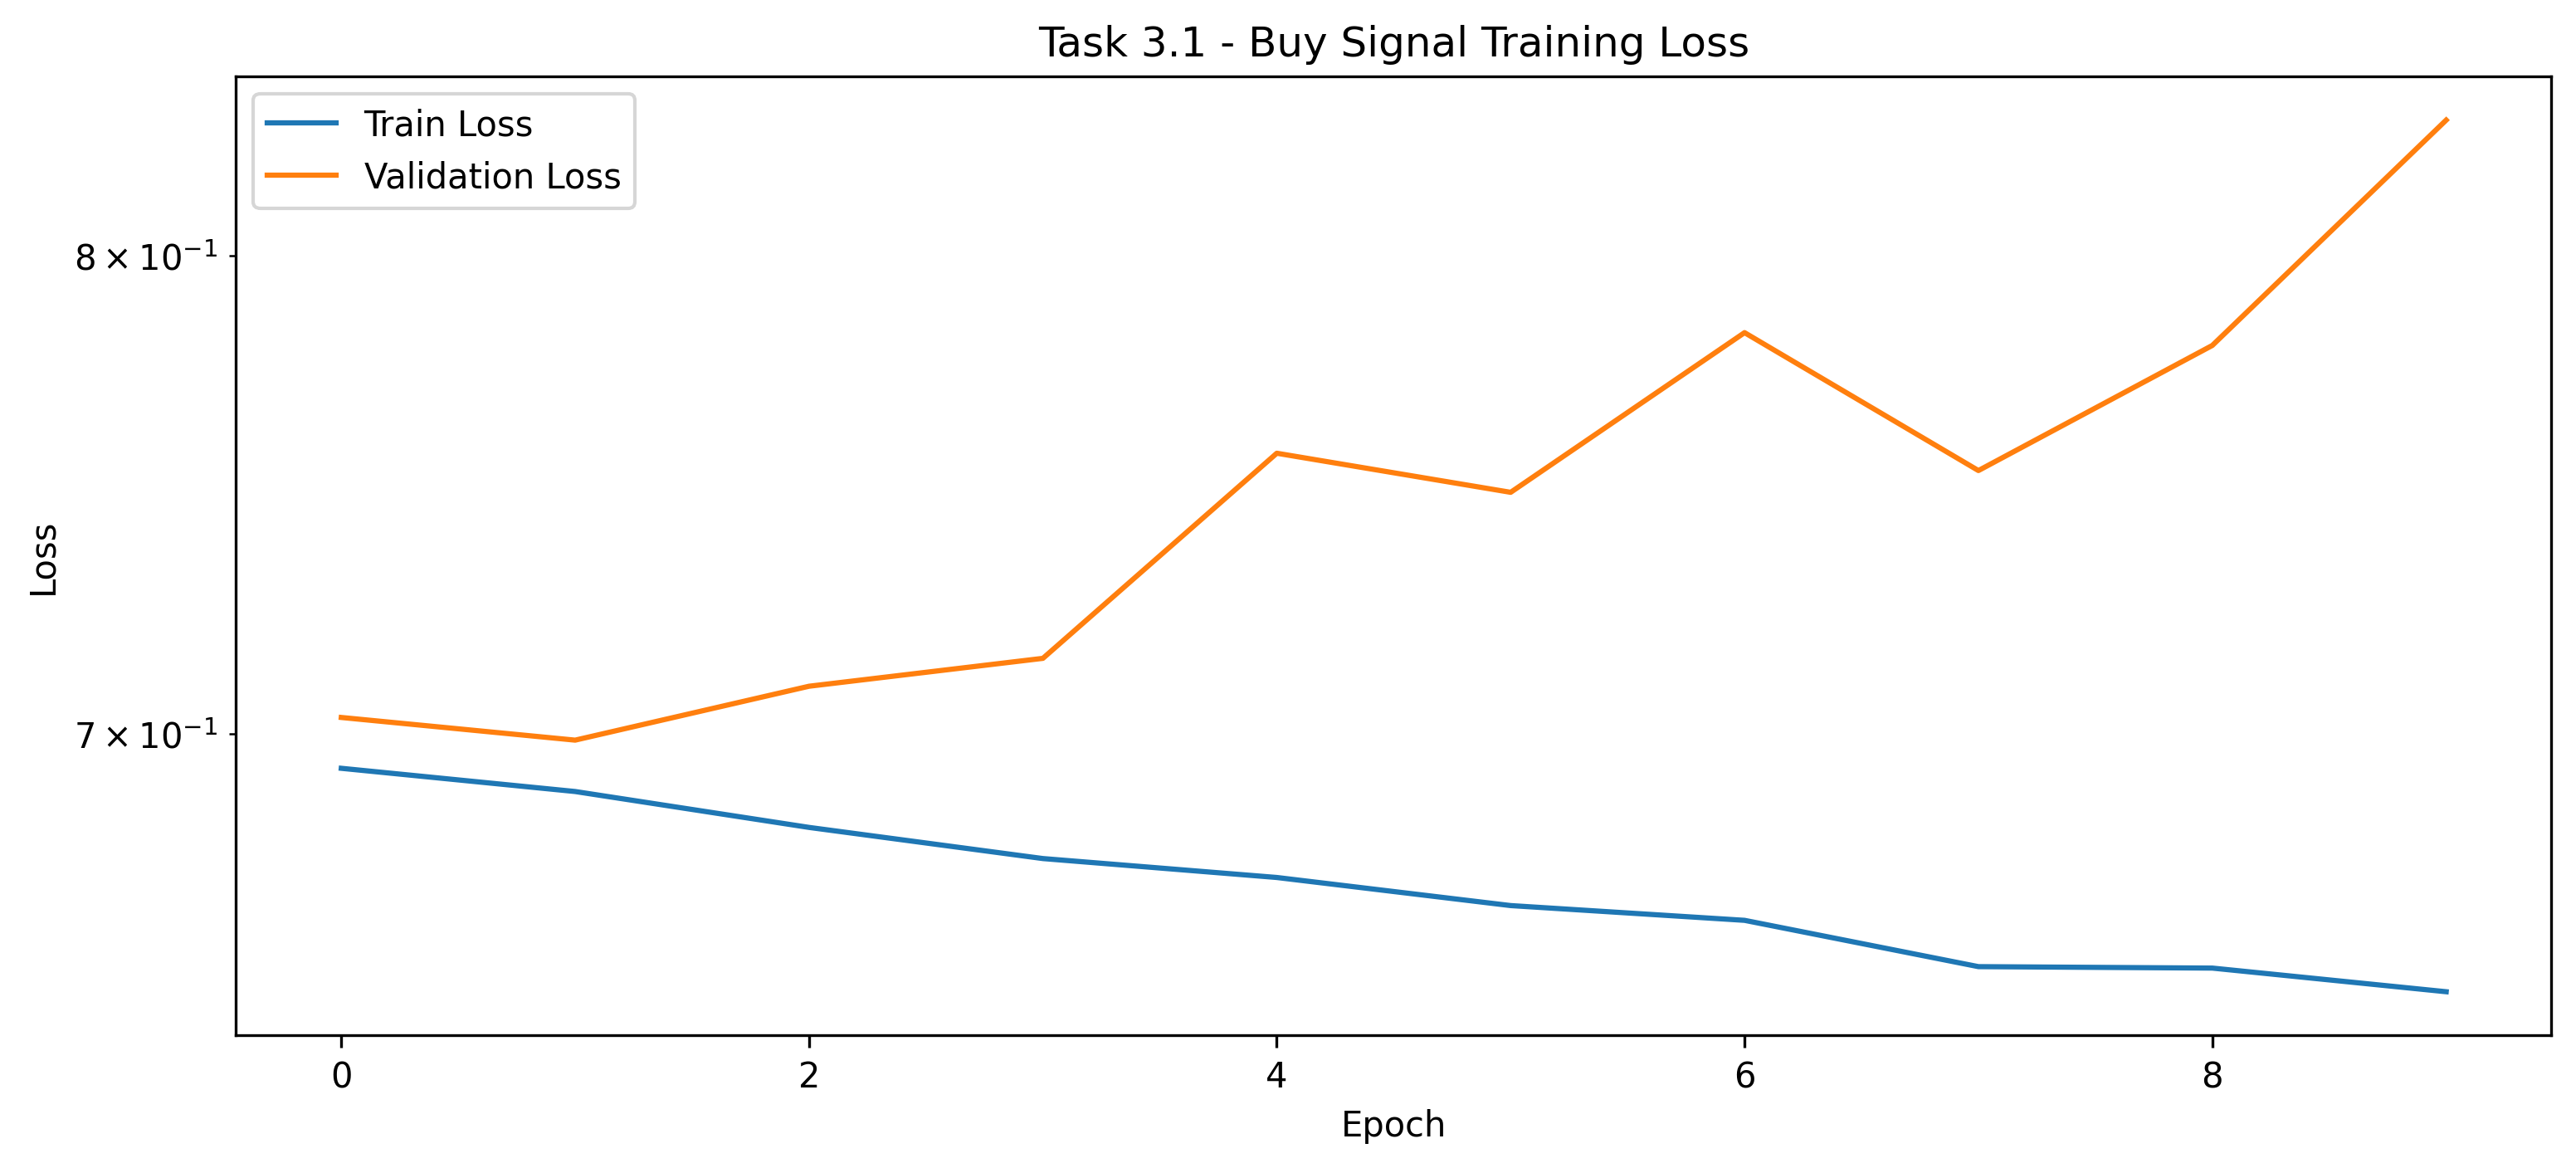

In [55]:
display(Image(
    "../results/figures/task3_1_buy_loss_curve.png"
))

### Observation

The Task 3.1 training loss graph illustrates the learning behavior of the CNN classifier for buy signal identification. The training loss gradually decreased across epochs, indicating that the model was able to minimize classification error on the training dataset and learn certain patterns associated with market behavior.

However, the validation loss followed a different trend and increased steadily throughout training. This divergence between training and validation loss suggests that the model experienced overfitting, where it learned patterns specific to the training data but failed to generalize effectively to unseen test samples.

The increasing validation loss is consistent with the poor classification performance observed in the evaluation metrics and confusion matrix. Although the model improved on the training set, it struggled to correctly identify buy signals during validation and testing. This indicates that the learned decision boundaries were not robust enough for real-world financial signal classification.

One major challenge in this task was class imbalance. Buy signals occurred less frequently than non-buy conditions, causing the model to favor the majority class during optimization. To mitigate this issue, class weighting and adjusted signal thresholds were applied during training in an attempt to encourage the model to learn both classes more effectively.

Despite these techniques, the model still showed difficulty detecting meaningful buy opportunities, highlighting the complexity of financial classification tasks. Stock market signals are highly noisy, irregular, and sensitive to short-term fluctuations, making generalization significantly harder than standard binary classification problems.

Overall, the loss curves demonstrate that while the CNN classifier successfully optimized training loss, the model did not generalize well to unseen data, suggesting that additional improvements such as better feature engineering, stronger regularization, more balanced datasets, or more advanced architectures may be necessary for reliable buy signal prediction.

## 6.4 Task 3.2 — Sell Signal Confusion Matrix

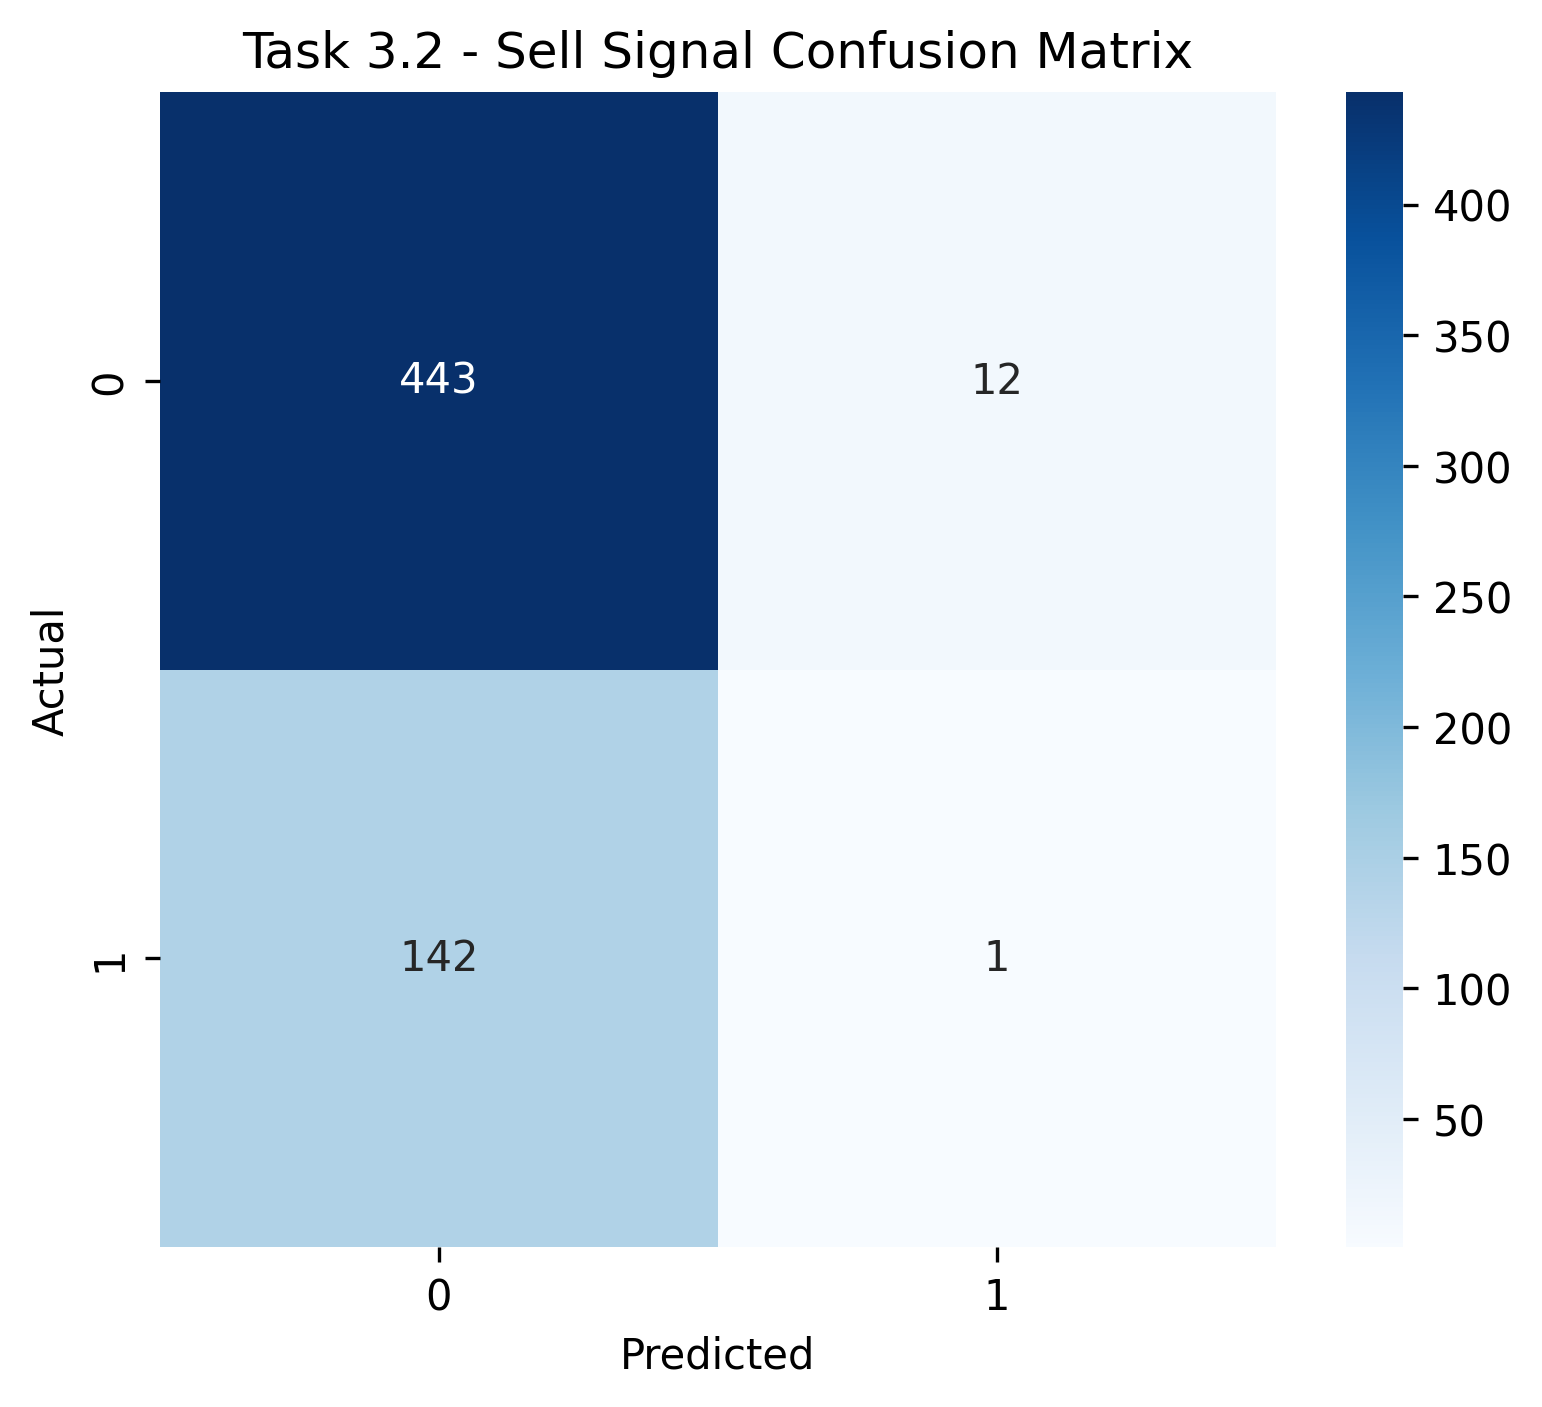

In [56]:
display(Image(
    "../results/figures/task3_2_sell_confusion_matrix.png"
))

### Observation

The Task 3.2 confusion matrix illustrates the performance of the CNN classifier for sell signal identification. The matrix shows that the model correctly classified a large number of non-sell cases, with 443 true negatives, indicating that the classifier was relatively effective at recognizing situations where no sell signal was present.

However, the model struggled significantly to identify actual sell opportunities. Only 1 true positive sell signal was detected, while 142 actual sell signals were incorrectly classified as non-sell. This resulted in extremely low recall for the sell class, meaning the model failed to capture most downward trading opportunities.

The confusion matrix also shows 12 false positives, where the model predicted a sell signal even though the actual label was non-sell. While the number of false positives was relatively small, the primary issue was the very high number of false negatives.

This behavior suggests that the classifier was heavily biased toward predicting the majority class. In financial datasets, strong sell signals and sharp downward movements often occur less frequently than stable or upward movements, leading to severe class imbalance. As a result, the model learned to favor the dominant non-sell category in order to minimize overall loss.

The low recall and F1-score indicate that the model had limited practical usefulness for real trading decision-making in its current form. Missing actual sell opportunities can be costly in financial forecasting because delayed sell actions may increase trading risk during market declines.

Overall, the confusion matrix highlights the difficulty of sell signal classification in stock market prediction. The results suggest that additional improvements such as more balanced training data, stronger feature engineering, threshold optimization, or advanced sequence models may be required to improve the detection of rare downward market signals.

## 6.5 Task 3.2 Sell Signal Training Loss

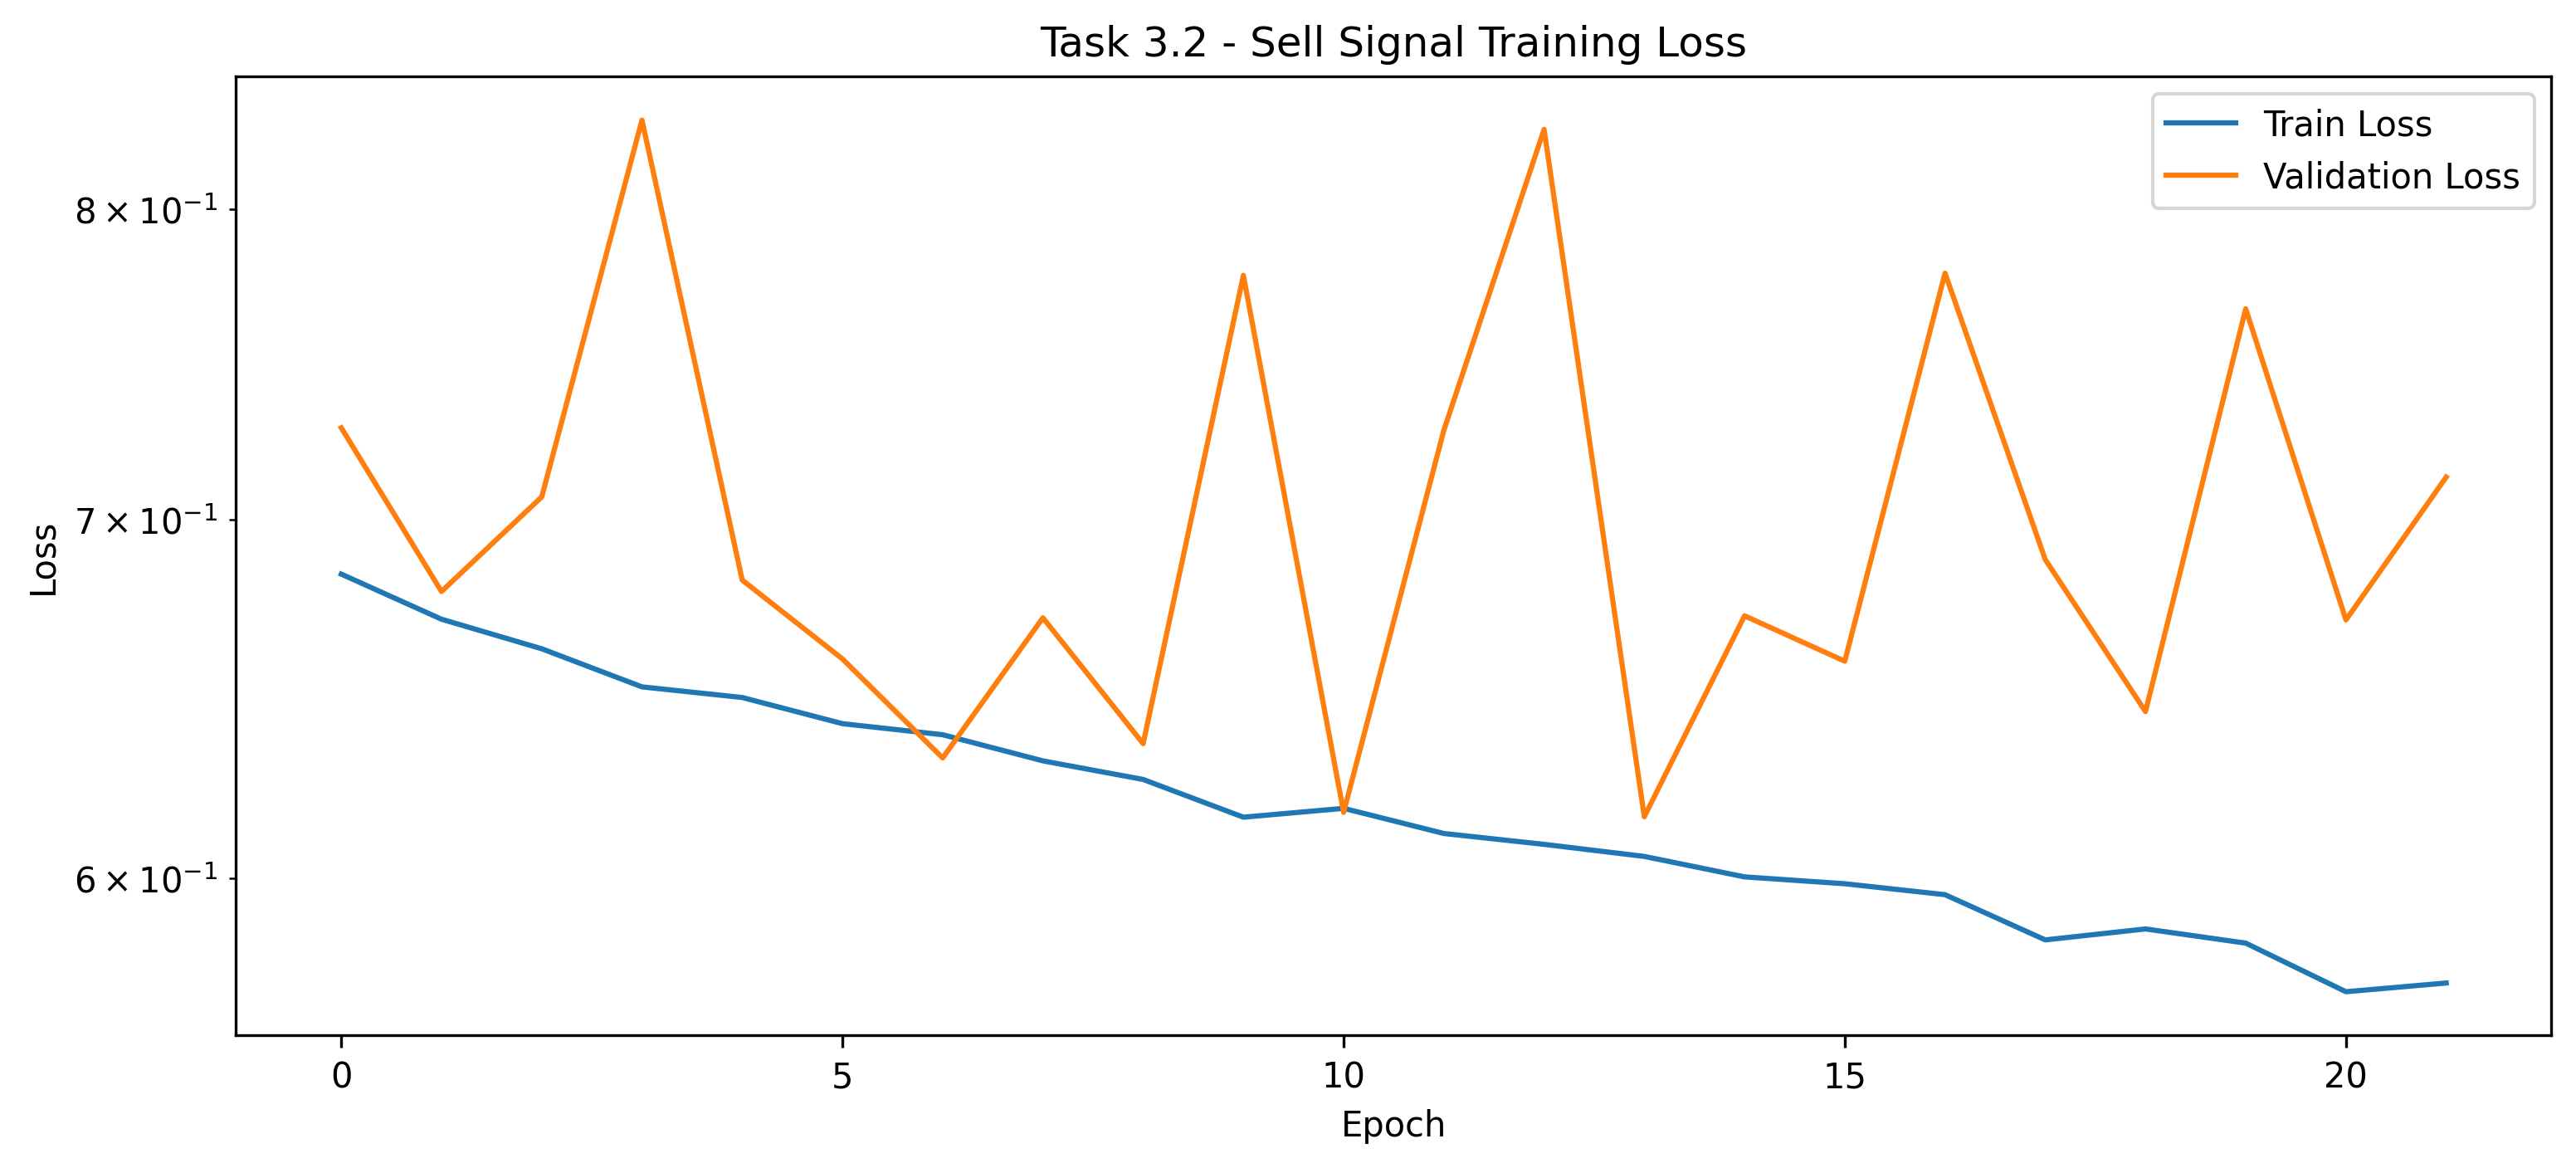

In [57]:
display(Image(
    "../results/figures/task3_2_sell_loss_curve.png"
))

### Observation

The Task 3.2 training loss curve illustrates the learning behavior of the CNN model for sell signal classification. The training loss gradually decreased throughout the epochs, indicating that the model was able to learn patterns from the training dataset and improve its classification capability over time.

However, the validation loss fluctuated significantly and remained noticeably higher than the training loss during most epochs. This suggests that the model had difficulty generalizing to unseen data and that sell signal prediction was a highly challenging classification task.

The unstable validation curve is consistent with the earlier confusion matrix and evaluation metrics, where the model achieved very low recall and F1-score for sell signal detection. This behavior likely resulted from strong class imbalance, where sell signals were relatively rare compared to non-sell cases. As a result, the model tended to bias its predictions toward the majority class.

The spikes in validation loss also indicate that the market behavior during validation periods differed from the training patterns. Financial time-series data is highly volatile and non-stationary, making downward market movements more difficult to predict consistently.

Although the model successfully minimized training loss, the gap between training and validation performance suggests a degree of overfitting. The classifier learned the training distribution reasonably well but struggled to generalize rare sell signal events in the testing data.

Overall, the training curve demonstrates that sell signal identification is considerably more difficult than standard price forecasting tasks. The results highlight the need for additional improvements such as better balancing techniques, richer technical indicators, threshold tuning, or more advanced deep learning architectures to improve rare-event classification performance.

# 7. Task 4 — Portfolio Selection, Risk Management, and Portfolio Allocation

Task 4 focuses on portfolio-level financial analysis and investment decision-making using the Vietnam stock market dataset. Unlike the previous tasks that concentrated mainly on prediction and classification, this section evaluates how forecasting outputs and financial indicators can support practical portfolio construction strategies.

The main objectives of Task 4 are:

- selecting profitable stocks,
- identifying high-risk companies,
- evaluating the trade-off between return and risk,
- and constructing a balanced portfolio allocation strategy.

The portfolio analysis was performed using several widely used financial profitability and risk indicators.

## Profitability Indicators

### 120-Day Cumulative Return

The 120-day cumulative return measures the overall percentage change in stock price over the selected analysis window. This metric helps evaluate how much profit or loss a stock generated during the evaluation period.

Stocks with higher cumulative returns are generally considered more attractive from a profitability perspective because they demonstrate stronger historical growth performance.

### Average Daily Return

Average daily return measures the mean daily percentage change in stock price. This provides a more granular view of stock profitability and helps identify whether returns were generated consistently over time.

## Risk Indicators

### Volatility

Volatility measures the standard deviation of daily returns and represents the degree of price fluctuation experienced by a stock.

Higher volatility indicates greater uncertainty and investment risk because the stock price changes more aggressively over time. Lower volatility generally reflects more stable market behavior.

### Maximum Drawdown

Maximum drawdown measures the largest decline from a previous peak price during the analysis period. This metric is particularly important for understanding downside investment risk and evaluating how severe potential losses may become during unfavorable market conditions.

Stocks with very large drawdowns may expose investors to significant capital loss during market downturns.

## Portfolio Ranking Strategy

To balance profitability and risk simultaneously, a scoring framework was developed that combines:

- return ranking,
- risk ranking,
- and a combined portfolio score.

This approach prevents the portfolio from selecting stocks purely based on return performance. A stock with extremely high returns but excessive volatility or drawdown risk may receive a weaker overall portfolio score compared with a more stable stock offering moderate but consistent returns.

The portfolio ranking process therefore emphasizes risk-adjusted investment quality rather than aggressive return maximization alone.

## Portfolio Allocation

After ranking the stocks, a final portfolio allocation strategy was constructed using inverse-score weighting. Stocks with stronger combined return-risk performance received larger portfolio allocations.

The final portfolio construction process demonstrates how machine learning and financial analytics can support higher-level investment decision-making beyond simple stock price prediction.

The following sections present:

- profitability analysis tables,
- risk analysis results,
- combined portfolio ranking,
- portfolio allocation visualization,
- and risk-return relationship analysis for the selected Vietnam stocks.

## 7.1 Profitability Table

In [58]:
task4_profit = pd.read_csv(
    "../results/tables/task4_profitability_table.csv"
)

task4_profit

,Ticker,Cumulative_Return_120D,Average_Daily_Return
0,VCB,0.130593,0.001236
1,VNM,-0.012181,0.000053
2,FPT,-0.061772,-0.000412
3,HPG,-0.150743,-0.000853
4,MBB,-0.270613,-0.002186


### Observation

The profitability ranking table summarizes the return performance of the selected Vietnam stocks using two important financial indicators: cumulative return over the past 120 trading days and average daily return.

Among all stocks, VCB achieved the strongest profitability performance with a positive cumulative return of approximately 13.06% and the highest average daily return of 0.001236. This indicates that VCB generated the most stable positive growth during the evaluation period and was the strongest-performing stock in the portfolio from a return perspective.

VNM showed relatively stable behavior with a near-neutral cumulative return of approximately -1.22% and a slightly positive average daily return. Although the stock did not achieve strong growth, its performance was significantly more stable compared to several other stocks in the dataset.

FPT and HPG both produced negative cumulative returns, indicating weaker market performance during the selected period. HPG experienced a larger decline than FPT, suggesting higher downside pressure and weaker investment performance over the 120-day window.

MBB recorded the lowest profitability performance, with a cumulative return of approximately -27.06% and the lowest average daily return among all evaluated stocks. This suggests that MBB experienced the strongest downward trend during the analysis period.

Overall, the profitability table shows clear differences in stock performance across the Vietnamese market dataset. The results highlight that VCB was the most profitable stock during the evaluated period, while MBB exhibited the weakest return characteristics. These profitability metrics later contribute to the portfolio ranking and allocation process in Task 4.

## 7.2 Risk Table

In [59]:
task4_risk = pd.read_csv(
    "../results/tables/task4_risk_table.csv"
)

task4_risk

,Ticker,Volatility,Max_Drawdown
0,VNM,0.015721,-0.105432
1,FPT,0.017769,-0.231935
2,VCB,0.020213,-0.250302
3,MBB,0.029129,-0.401691
4,HPG,0.035686,-0.491597


### Observation

The risk analysis table evaluates the selected Vietnam stocks using two important financial risk metrics: volatility and maximum drawdown. These indicators help measure both short-term price fluctuations and the severity of historical losses experienced by each stock.

VNM achieved the lowest volatility value at approximately 0.0157, indicating that its daily price movements were relatively stable compared to the other stocks. In addition, VNM also recorded the smallest maximum drawdown at around -10.54%, suggesting that it experienced the lowest historical decline from its previous peak. These results indicate that VNM was the most stable and lowest-risk stock in the portfolio.

FPT showed slightly higher volatility and drawdown values than VNM but still maintained moderate risk characteristics relative to the remaining stocks. Its maximum drawdown of approximately -23.19% indicates that the stock experienced a noticeable decline during unfavorable market conditions.

VCB demonstrated moderate volatility at around 0.0202 and a maximum drawdown of approximately -25.03%. Although VCB produced the highest profitability in the previous analysis, the stock also carried higher investment risk compared to VNM and FPT.

MBB and HPG were identified as the highest-risk stocks in the dataset. MBB recorded volatility of approximately 0.0291 and a maximum drawdown of around -40.17%, indicating substantial downside exposure. HPG showed the highest overall risk, with the largest volatility value of approximately 0.0357 and the deepest maximum drawdown near -49.16%. This means HPG experienced both strong daily fluctuations and severe historical losses during the evaluation period.

Overall, the risk analysis highlights a clear trade-off between profitability and stability. Stocks such as VCB achieved stronger returns but carried higher risk, while VNM demonstrated much safer investment characteristics with lower volatility and drawdown. These risk metrics are essential for constructing a balanced portfolio allocation strategy in Task 4.

## 7.3 Portfolio Scoring Table

In [60]:
task4_scoring = pd.read_csv(
    "../results/tables/task4_portfolio_scoring_table.csv"
)

task4_scoring

,Ticker,Cumulative_Return_120D,Average_Daily_Return,Volatility,Max_Drawdown,Return_Rank,Risk_Rank,Combined_Score
0,VNM,-0.012181,0.000053,0.015721,-0.105432,2.0,1.0,1.6
1,VCB,0.130593,0.001236,0.020213,-0.250302,1.0,3.0,1.8
2,FPT,-0.061772,-0.000412,0.017769,-0.231935,3.0,2.0,2.6
3,HPG,-0.150743,-0.000853,0.035686,-0.491597,4.0,5.0,4.4
4,MBB,-0.270613,-0.002186,0.029129,-0.401691,5.0,4.0,4.6


### Observation

The portfolio scoring table combines both profitability and risk measurements to create a balanced investment ranking for the selected Vietnam stocks. Instead of selecting stocks based only on return performance, the scoring system integrates return ranking and risk ranking into a single combined score to support more stable portfolio construction.

VCB achieved the highest profitability ranking with the strongest cumulative return and average daily return. However, its risk metrics were higher than VNM, resulting in a combined score of 1.8 instead of the best overall score. This demonstrates that the portfolio strategy does not prioritize return alone but also considers investment stability and downside protection.

VNM achieved the best overall combined score of 1.6 despite having lower profitability than VCB. This was mainly due to its extremely low volatility and smallest maximum drawdown among all stocks. The result suggests that VNM offered the best balance between return stability and risk control during the evaluation period.

FPT obtained a moderate combined score of 2.6 because its profitability performance was weaker, although its risk profile remained relatively stable. In contrast, HPG and MBB received the lowest portfolio scores due to both poor return performance and significantly higher investment risk.

HPG showed the highest volatility and largest maximum drawdown, leading to a combined score of 4.4. MBB produced the weakest profitability results and also experienced substantial downside risk, resulting in the worst combined score of 4.6.

Overall, the portfolio scoring system demonstrates the importance of balancing return potential with financial risk. Stocks with strong profitability but excessive volatility may not always receive the highest portfolio preference. This approach creates a more diversified and risk-aware portfolio allocation strategy, which is especially important in volatile financial markets.

## 7.4 Selected Portfolio

In [61]:
task4_portfolio = pd.read_csv(
    "../results/tables/task4_selected_portfolio_table.csv"
)

task4_portfolio

,Ticker,Cumulative_Return_120D,Average_Daily_Return,Volatility,Max_Drawdown,Return_Rank,Risk_Rank,Combined_Score,Inverse_Score,Allocation
0,VNM,-0.012181,0.000053,0.015721,-0.105432,2.0,1.0,1.6,0.625000,0.399317
1,VCB,0.130593,0.001236,0.020213,-0.250302,1.0,3.0,1.8,0.555556,0.354949
2,FPT,-0.061772,-0.000412,0.017769,-0.231935,3.0,2.0,2.6,0.384615,0.245734


### Observation

The final portfolio allocation table presents the selected investment strategy after combining profitability and risk analysis. The portfolio weights were calculated using the inverse of the combined score, meaning that stocks with stronger return-risk balance received larger portfolio allocations.

VNM received the highest allocation weight at approximately 39.93%. Although its profitability performance was lower than VCB, VNM demonstrated the lowest volatility and smallest maximum drawdown among all evaluated stocks. This indicates that the allocation strategy strongly favored stability and lower investment risk.

VCB received the second-largest allocation at approximately 35.49%. The stock achieved the best profitability performance with the highest cumulative return and average daily return. However, its higher volatility and drawdown reduced its overall allocation relative to VNM. This reflects the portfolio’s balanced approach between maximizing returns and controlling risk exposure.

FPT obtained the smallest allocation at approximately 24.57%. While its risk profile remained relatively moderate, weaker profitability performance lowered its overall portfolio preference compared to VNM and VCB.

The allocation strategy demonstrates that the portfolio was not constructed solely based on return maximization. Instead, the method prioritized a balance between profitability and financial stability. Stocks with lower combined scores achieved higher inverse scores and therefore larger allocation percentages.

Overall, the final portfolio represents a diversified and risk-aware investment strategy. The results show how combining return analysis with volatility and drawdown measurements can produce a more balanced portfolio allocation compared to selecting only the highest-return stocks.

## 7.5 Portfolio Allocation Chart

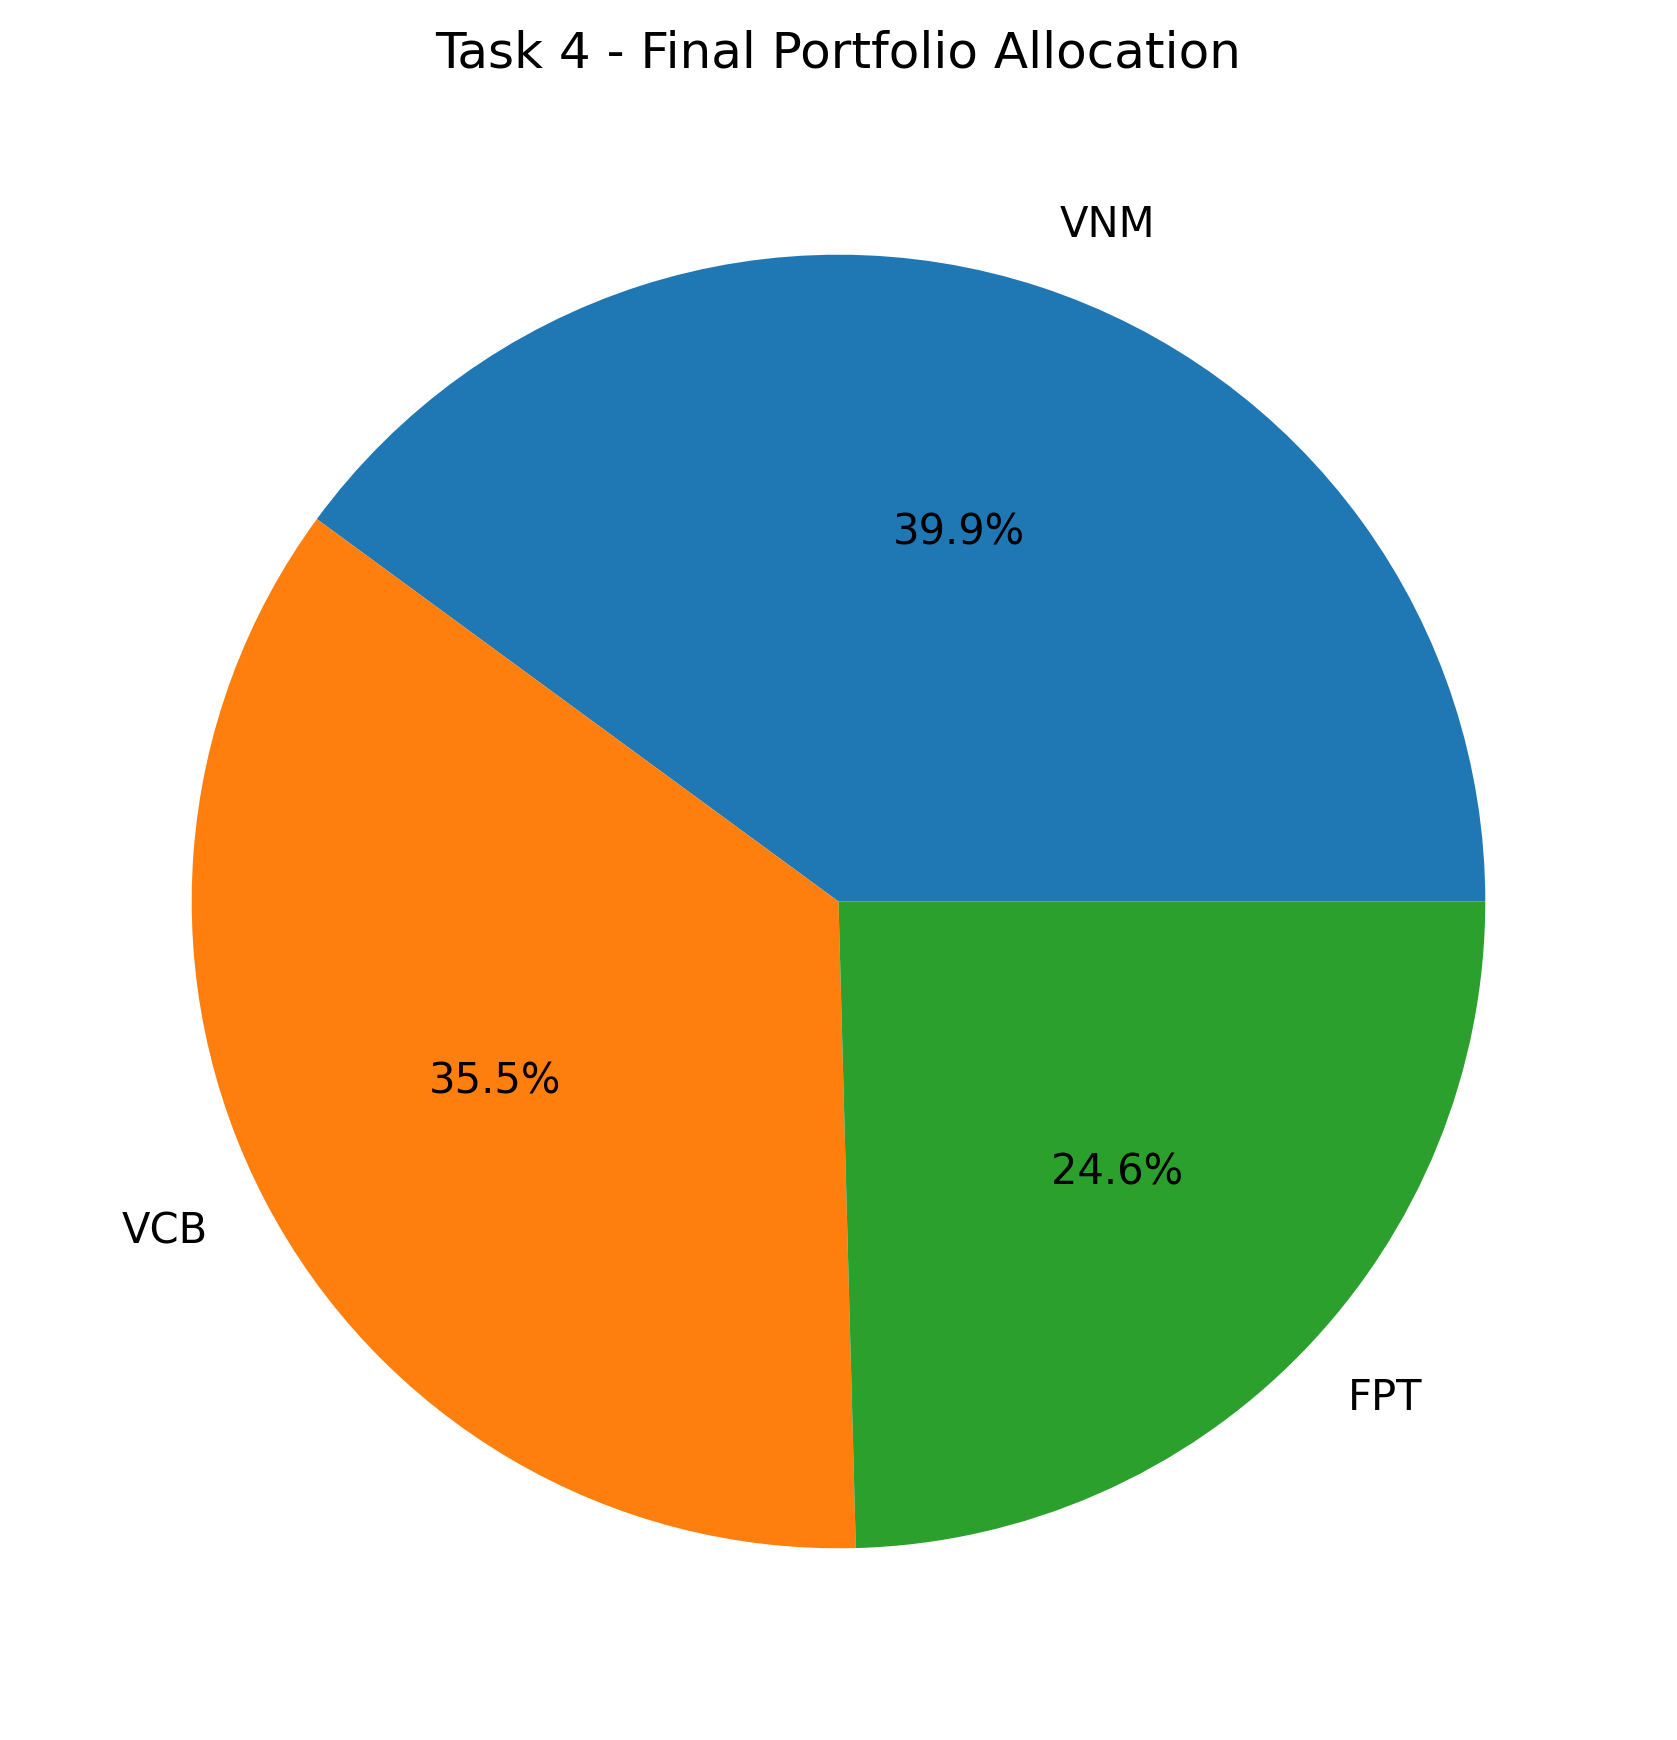

In [62]:
display(Image(
    "../results/figures/task4_portfolio_allocation.png"
))

### Observation

The final portfolio allocation chart visually summarizes the investment distribution generated from the portfolio optimization process. The pie chart clearly illustrates how capital was allocated among the selected Vietnam stocks based on their combined profitability and risk performance.

VNM received the largest allocation at approximately 39.9% of the portfolio. Although VNM did not achieve the highest return performance, it demonstrated the strongest overall balance between profitability and risk due to its low volatility and relatively small maximum drawdown. This result indicates that the portfolio strategy prioritized long-term stability and downside protection.

VCB accounted for approximately 35.5% of the portfolio allocation. The stock achieved the highest profitability metrics among all evaluated stocks, including the strongest cumulative return and average daily return. However, its slightly higher risk measurements compared to VNM reduced its final allocation weight.

FPT received the smallest portfolio allocation at approximately 24.6%. While the stock maintained moderate risk characteristics, its weaker profitability performance lowered its portfolio preference relative to VNM and VCB.

The chart demonstrates that the portfolio optimization strategy did not allocate capital equally across all stocks. Instead, allocation weights were determined dynamically based on the combined scoring framework that integrated both return potential and financial risk.

From an investment perspective, the resulting portfolio represents a balanced and diversified strategy rather than a purely aggressive return-maximization approach. The allocation emphasizes financial stability while still maintaining exposure to profitable growth opportunities within the Vietnam stock market.

## 7.6 Risk vs Return Scatter Plot

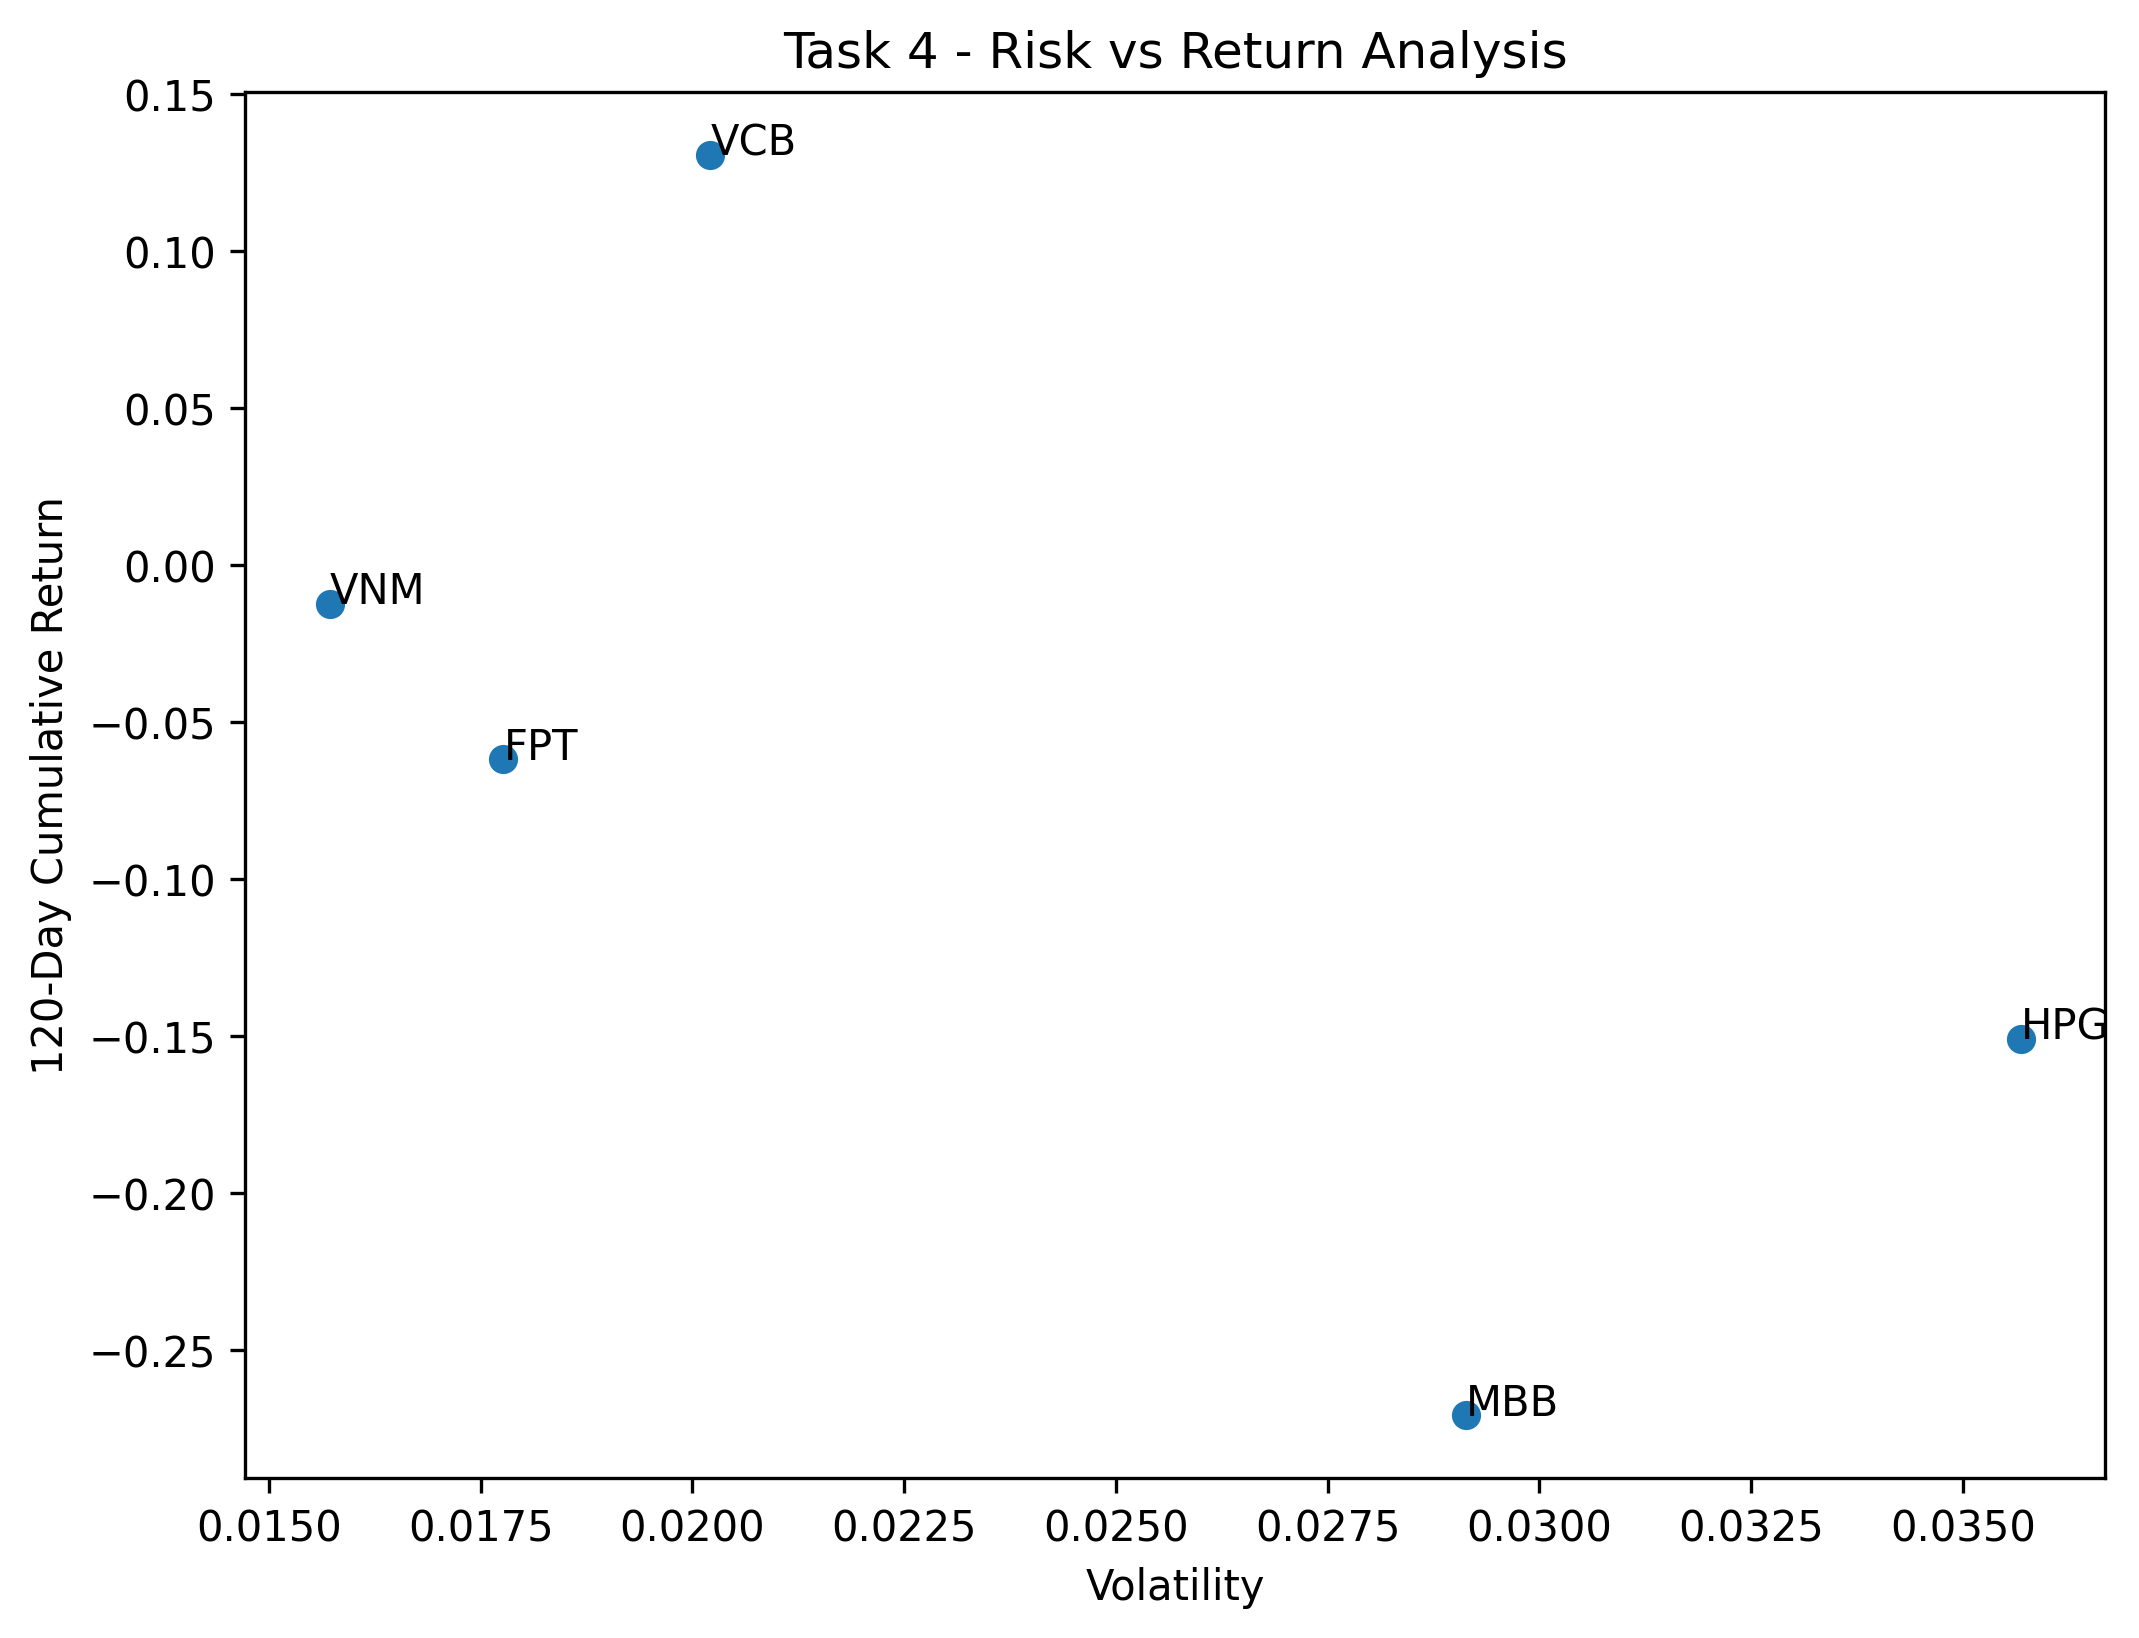

In [63]:
display(Image(
    "../results/figures/task4_risk_return_scatter.png"
))

### Observation

The risk-return scatter plot visualizes the relationship between stock volatility and cumulative return for the selected Vietnam stocks. This figure helps evaluate the trade-off between investment risk and profitability, which is one of the most important concepts in portfolio management.

VCB appears in the most favorable region of the chart, combining relatively moderate volatility with the highest positive cumulative return of approximately 13%. This indicates that VCB delivered the strongest profitability performance while maintaining acceptable risk levels, making it one of the most attractive stocks in the analysis.

VNM demonstrated the lowest volatility among all evaluated stocks, indicating strong price stability. Although its cumulative return was slightly negative, the stock remained attractive from a risk-management perspective because it experienced much smaller fluctuations and lower downside exposure compared to the other stocks.

FPT showed moderate volatility but produced negative cumulative returns, suggesting that its return performance was not strong enough to justify its risk during the evaluation period.

HPG and MBB were positioned in the least favorable area of the chart. Both stocks experienced high volatility combined with strongly negative cumulative returns, indicating weak investment efficiency. HPG showed the highest volatility, while MBB recorded the worst return performance. These characteristics made both stocks less suitable for inclusion in the final portfolio allocation.

The scatter plot clearly demonstrates the importance of balancing return and risk in investment decision-making. Stocks that generate strong returns with controlled volatility are generally more desirable for portfolio construction than stocks with high risk but weak profitability.

Overall, the risk-return analysis supports the final portfolio allocation results by visually confirming why VNM, VCB, and FPT were selected for the optimized portfolio, while higher-risk and lower-performing stocks such as HPG and MBB received lower portfolio preference.

## 7.7 Cumulative Return Comparison

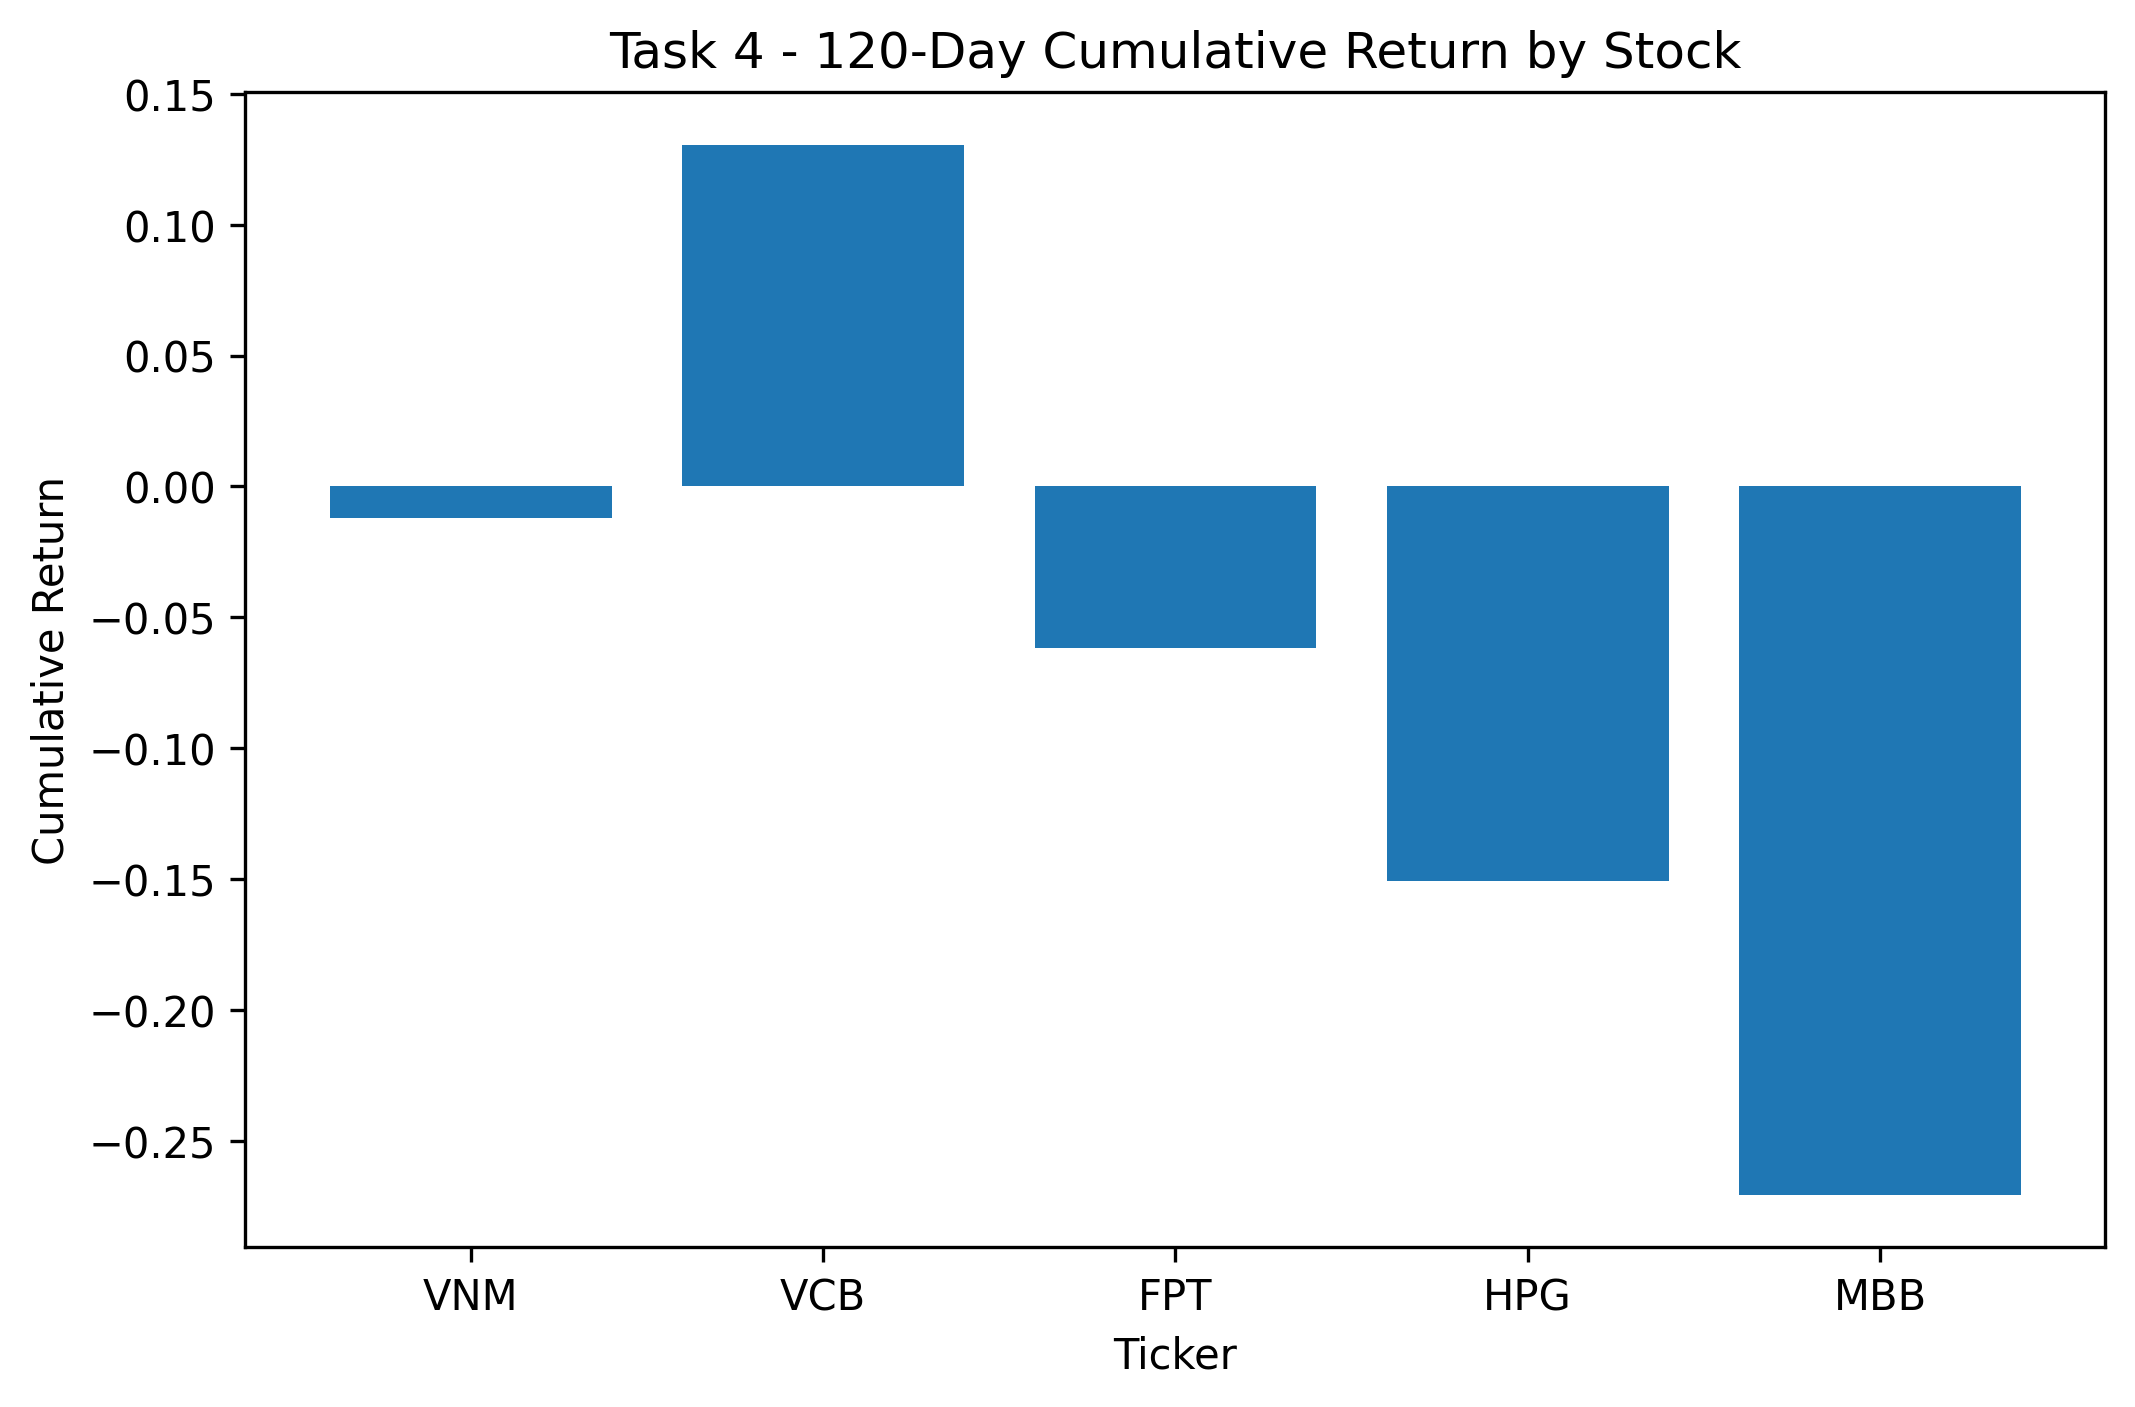

In [64]:
display(Image(
    "../results/figures/task4_cumulative_return_bar.png"
))

### Observation

The cumulative return bar chart compares the 120-day profitability performance of the selected Vietnam stocks. This visualization provides a clearer understanding of how each stock performed over the evaluation period and highlights the differences in investment outcomes across the portfolio candidates.

VCB achieved the strongest performance among all evaluated stocks, recording a positive cumulative return of approximately 13%. This indicates that VCB experienced consistent upward growth during the analysis period and was the only stock that generated a clearly positive overall return. The result confirms VCB’s strong profitability ranking in the portfolio evaluation process.

VNM showed relatively stable performance with only a small negative cumulative return close to zero. Although the stock did not generate strong profits, its limited decline suggests that it maintained stable market behavior and experienced less severe downside pressure compared to other stocks.

FPT produced a moderate negative cumulative return of approximately -6%, indicating weaker profitability during the selected period. However, its decline was still considerably smaller than the losses observed in HPG and MBB.

HPG recorded a larger negative cumulative return near -15%, reflecting a more significant decline in market value over the 120-day window. This weaker profitability performance was also associated with higher volatility and drawdown risk in earlier analyses.

MBB demonstrated the poorest profitability performance, with a cumulative return of approximately -27%. This indicates that MBB experienced the strongest sustained downward trend among all evaluated stocks during the analysis period.

Overall, the cumulative return chart highlights substantial differences in stock profitability across the Vietnamese market dataset. The visualization clearly supports the portfolio selection process by showing why VCB received strong portfolio preference, while weaker-performing stocks such as HPG and MBB received lower ranking scores.

## 7.8 Volatility Comparison

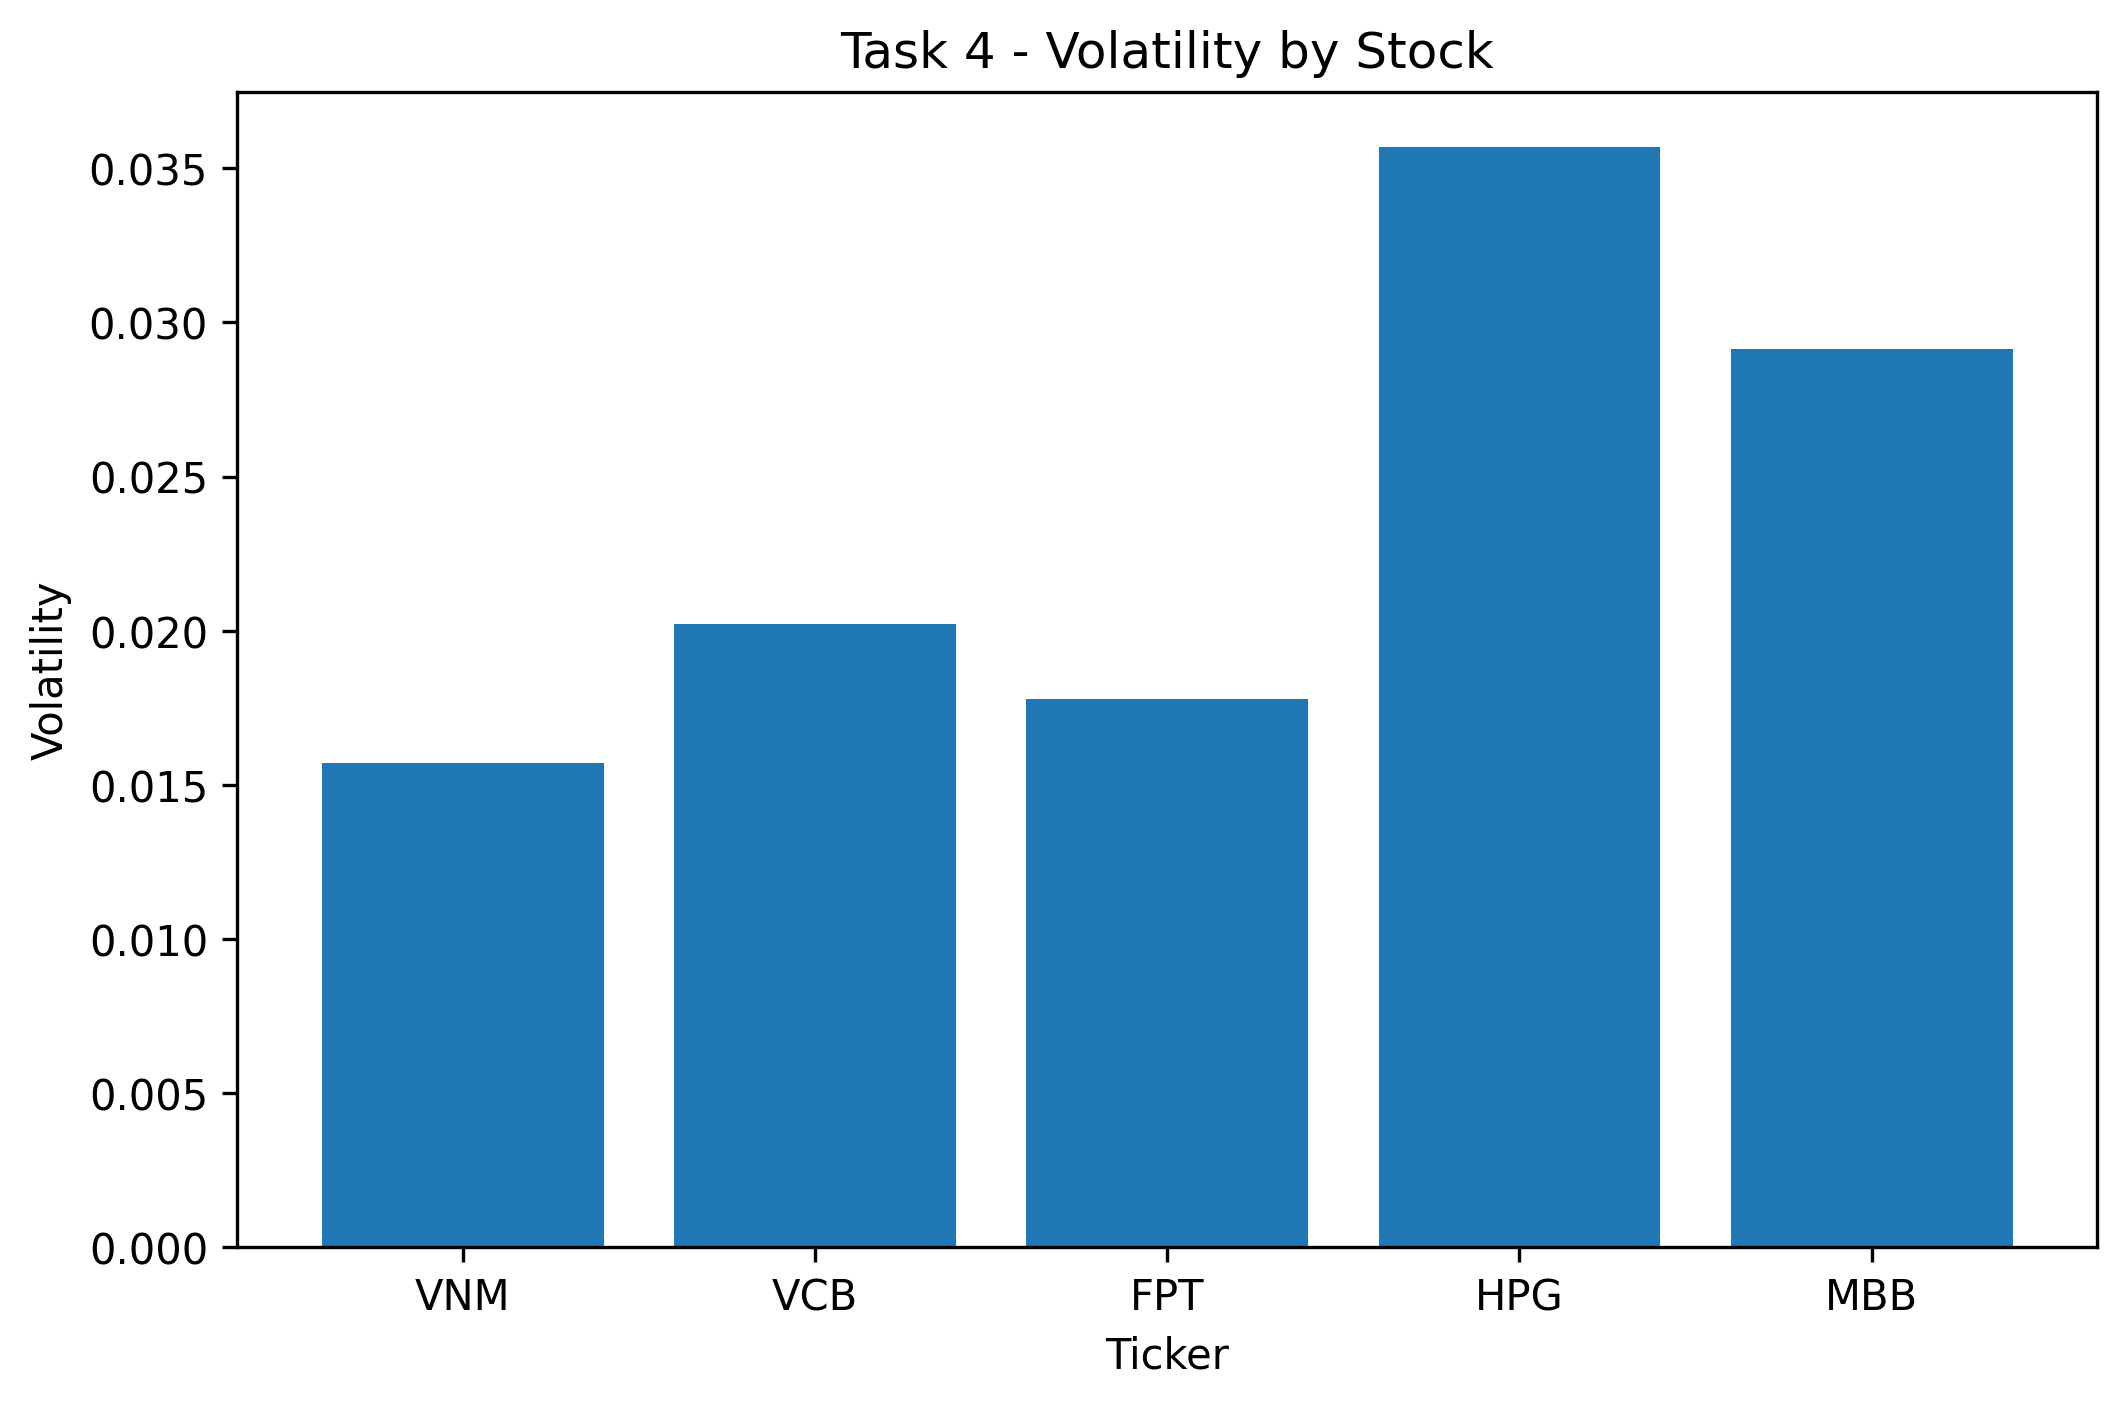

In [65]:
display(Image(
    "../results/figures/task4_volatility_bar.png"
))

### Observation

The volatility bar chart compares the risk level of each selected Vietnam stock using the standard deviation of daily returns. Volatility is an important financial risk indicator because it measures how strongly stock prices fluctuate over time. Higher volatility generally indicates greater uncertainty and investment risk.

Among the evaluated stocks, HPG shows the highest volatility, meaning its daily price movements were the most unstable during the analysis period. This suggests that HPG carried the highest market risk and was more sensitive to market fluctuations. The high volatility result is consistent with its weak cumulative return and large drawdown observed in earlier portfolio analysis.

MBB also demonstrates relatively high volatility, indicating that its stock price experienced substantial fluctuations. Combined with its strongly negative cumulative return, this suggests that MBB provided an unfavorable risk-return profile during the evaluation window.

VCB and FPT display moderate volatility levels. Although these stocks experienced noticeable market fluctuations, their risk levels remained significantly lower than HPG and MBB. In particular, VCB achieved strong profitability while maintaining only moderate volatility, making it one of the most attractive stocks in the portfolio construction process.

VNM has the lowest volatility among all evaluated stocks. This indicates that VNM exhibited the most stable daily return behavior and carried the lowest overall market risk. Although its profitability was not the highest, its low volatility made it attractive from a defensive investment perspective.

Overall, the volatility chart demonstrates the importance of balancing return and risk in portfolio construction. Stocks with extremely high volatility may offer larger short-term price movements, but they also expose investors to greater uncertainty and potential losses. Therefore, the portfolio strategy considers both profitability and volatility when selecting stock allocations.

# 8. Task 5 — Deployment and AI Engineering Workflow

Task 5 focuses on industry-level deployment and usability.

The project includes:

- FastAPI backend deployment,
- Streamlit SaaS-style frontend,
- and an AI workflow design.

This section demonstrates how the trained models can be used outside notebooks in a practical application environment.

# Task 5.1 — Model Deployment as REST API

For Task 5.1, the trained Vietnam CNN stock prediction model was deployed as a REST API using FastAPI. The API provides a backend service that allows external applications to send stock market input data and receive a predicted normalized closing price.

The API includes three main endpoints:

- `/`: root endpoint for checking whether the API is running
- `/health`: health check endpoint for verifying service availability
- `/predict`: prediction endpoint for sending stock input data to the trained model

The `/predict` endpoint expects a 30-day input window with 5 normalized stock features: Low, Open, Volume, High, and Close. After receiving the input, the API reshapes the data, sends it to the trained CNN model, and returns the predicted normalized closing price.

The Swagger documentation confirms that the API was successfully deployed and can be tested interactively through `http://127.0.0.1:8000/docs`. The prediction test returned status code `200`, showing that the API successfully processed the input and returned a valid model prediction.

Overall, this satisfies Task 5.1 because the trained prediction model was successfully deployed as a working REST API service.

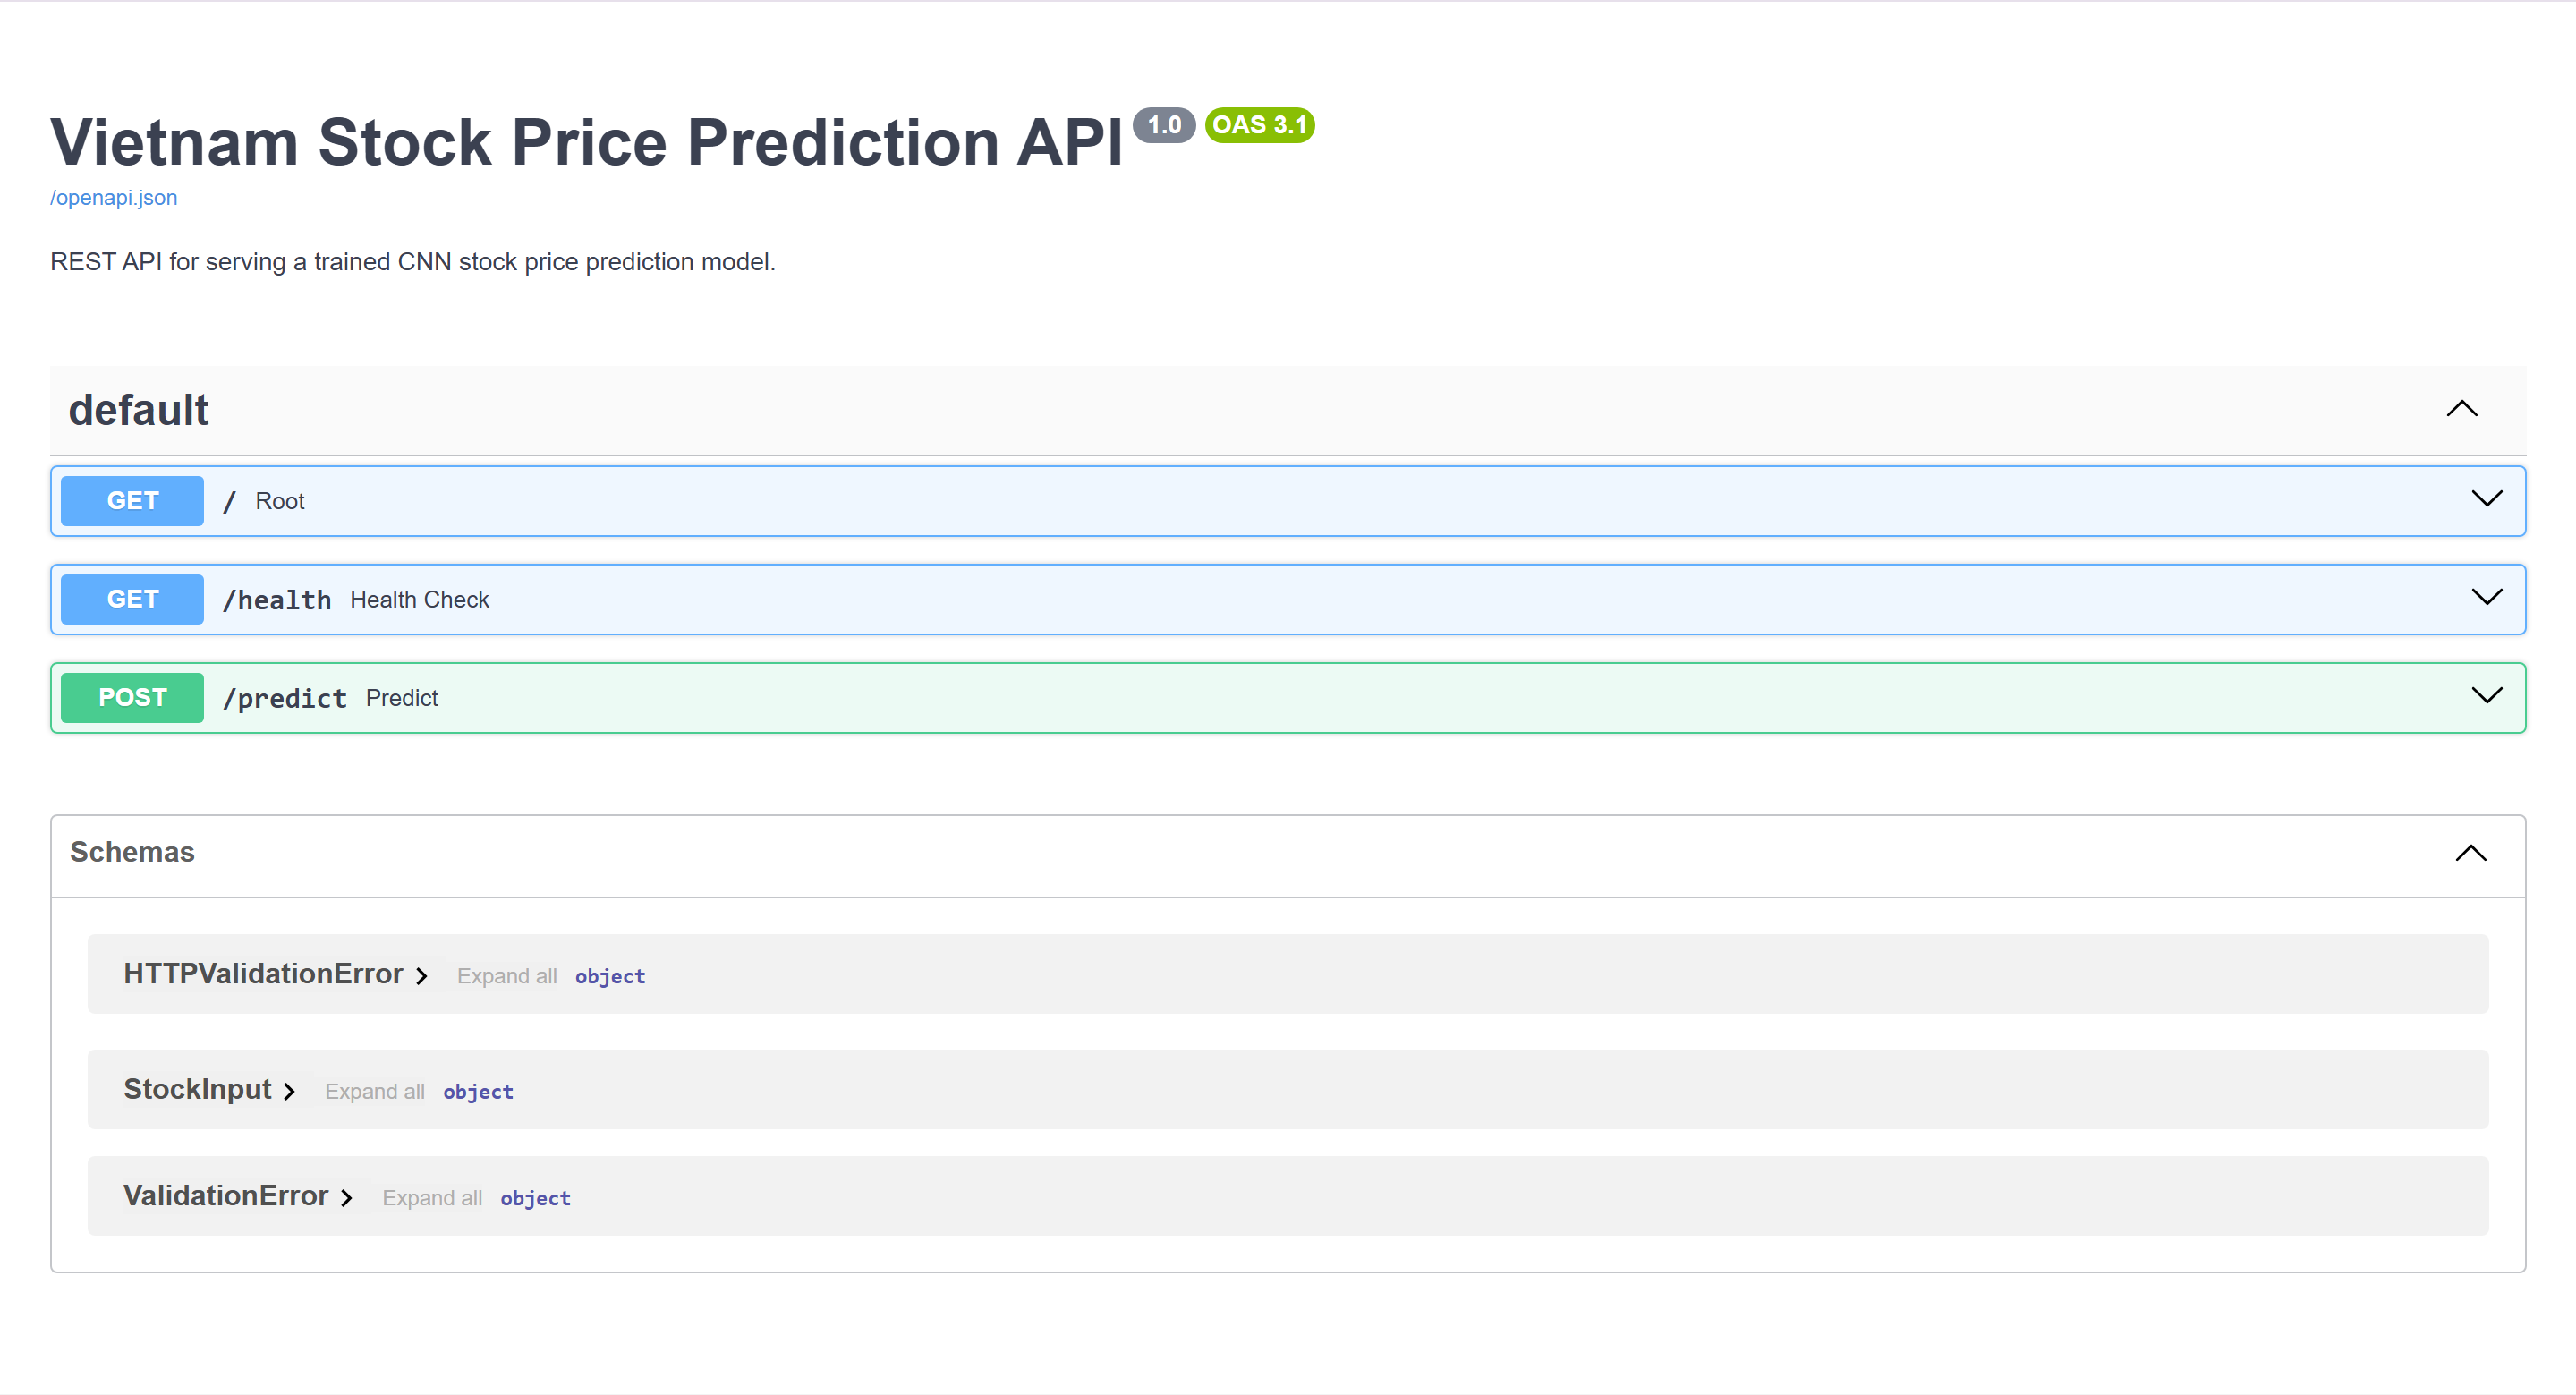

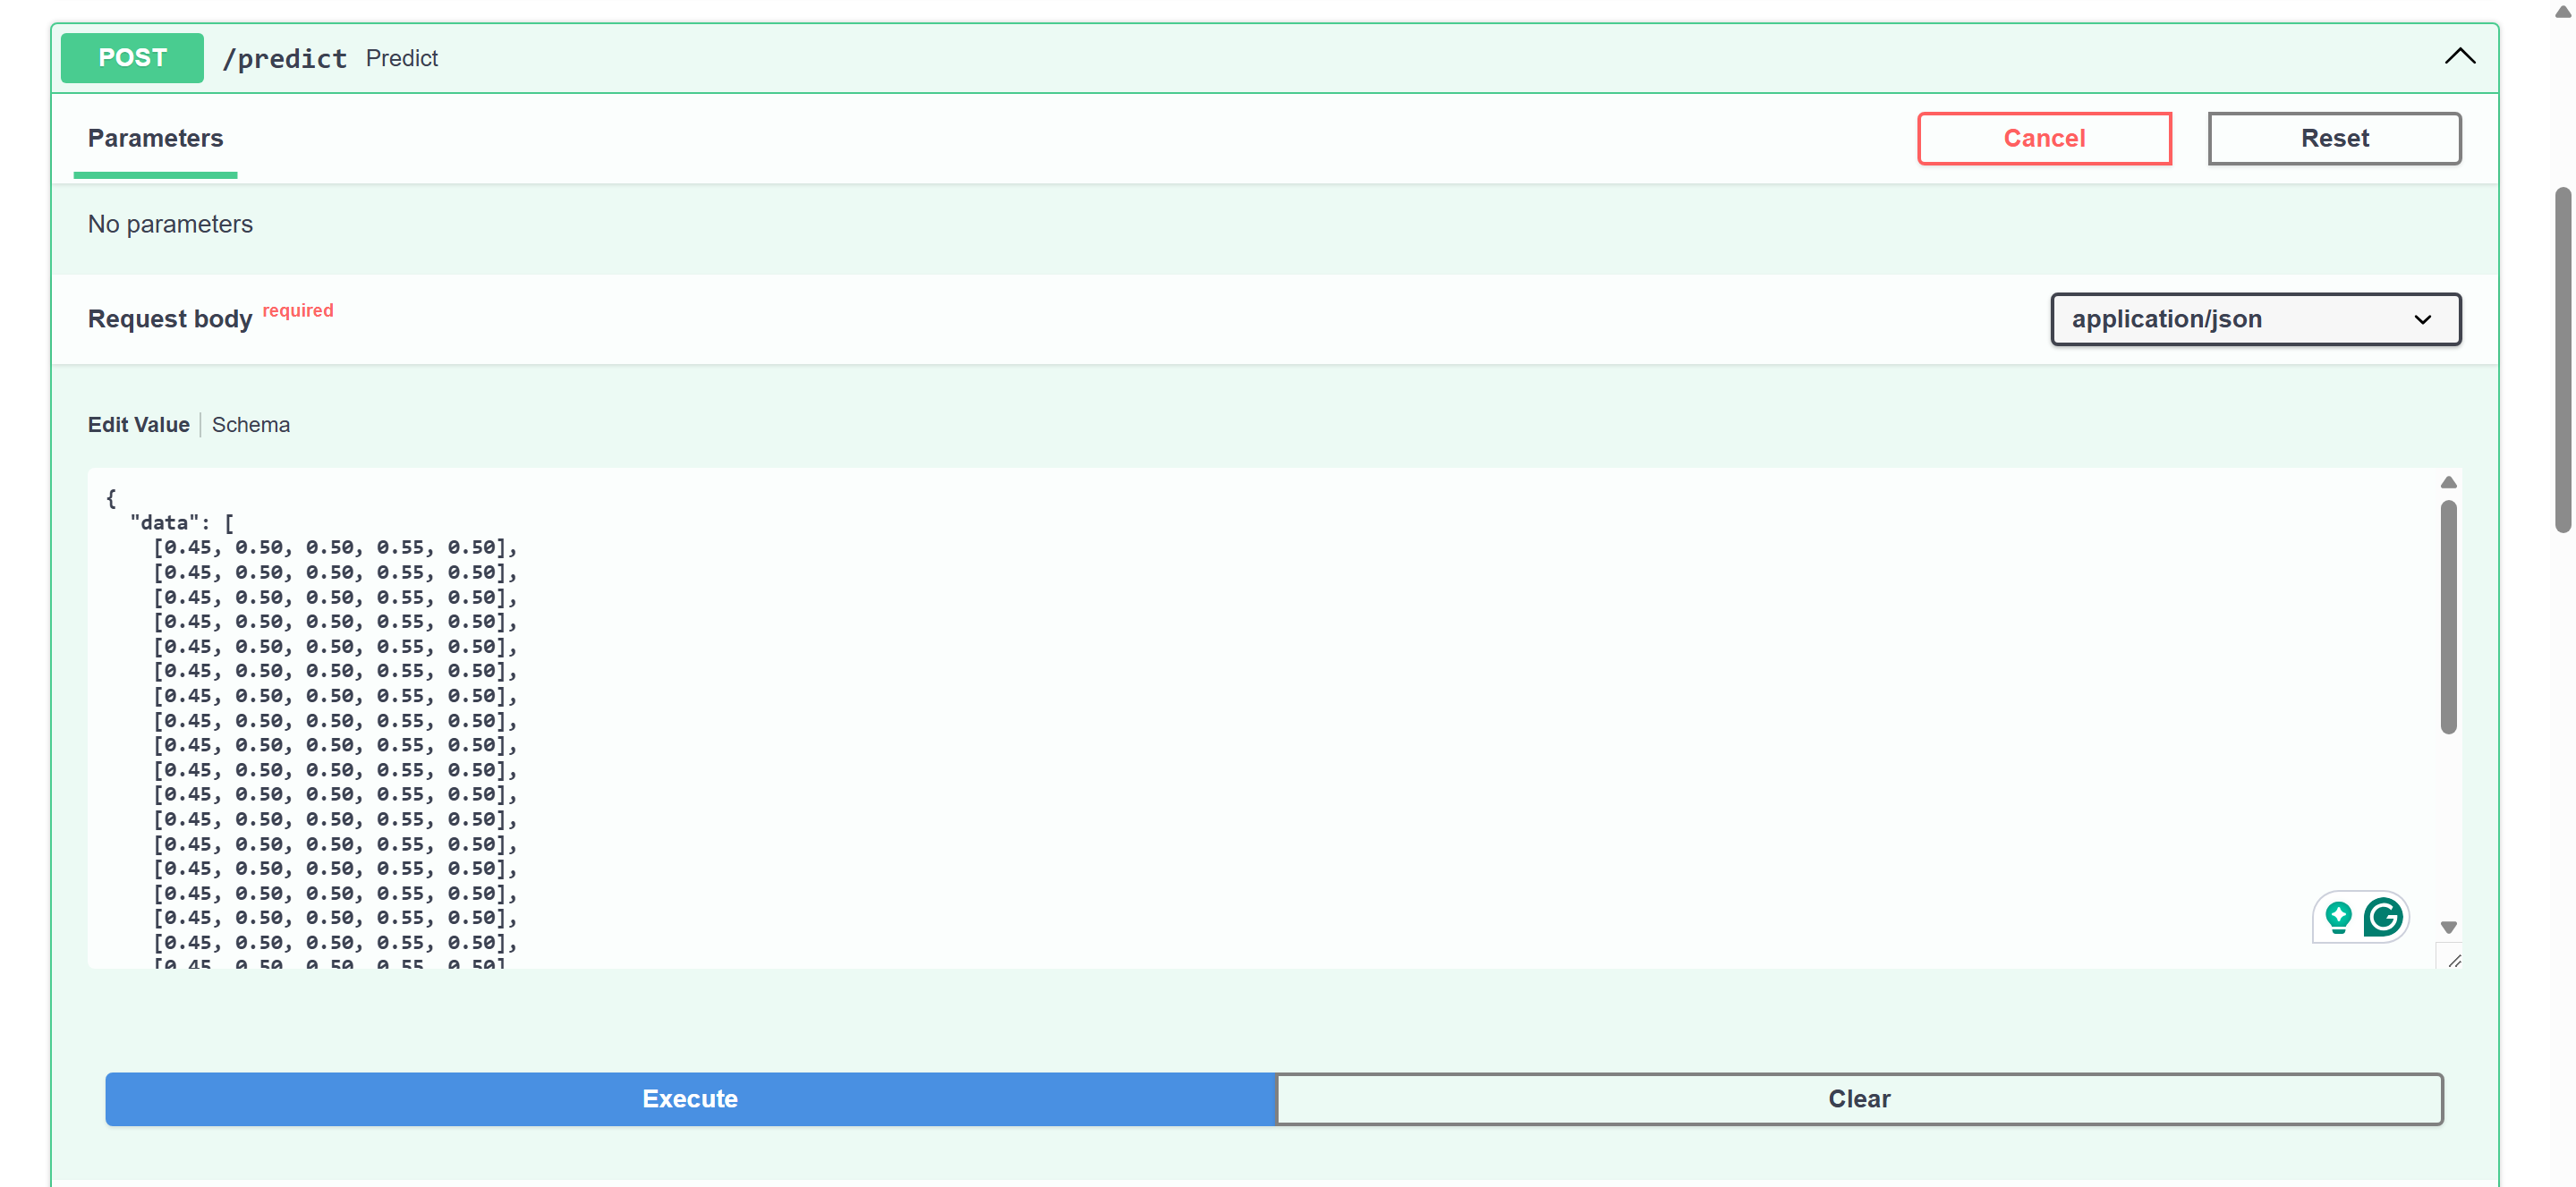

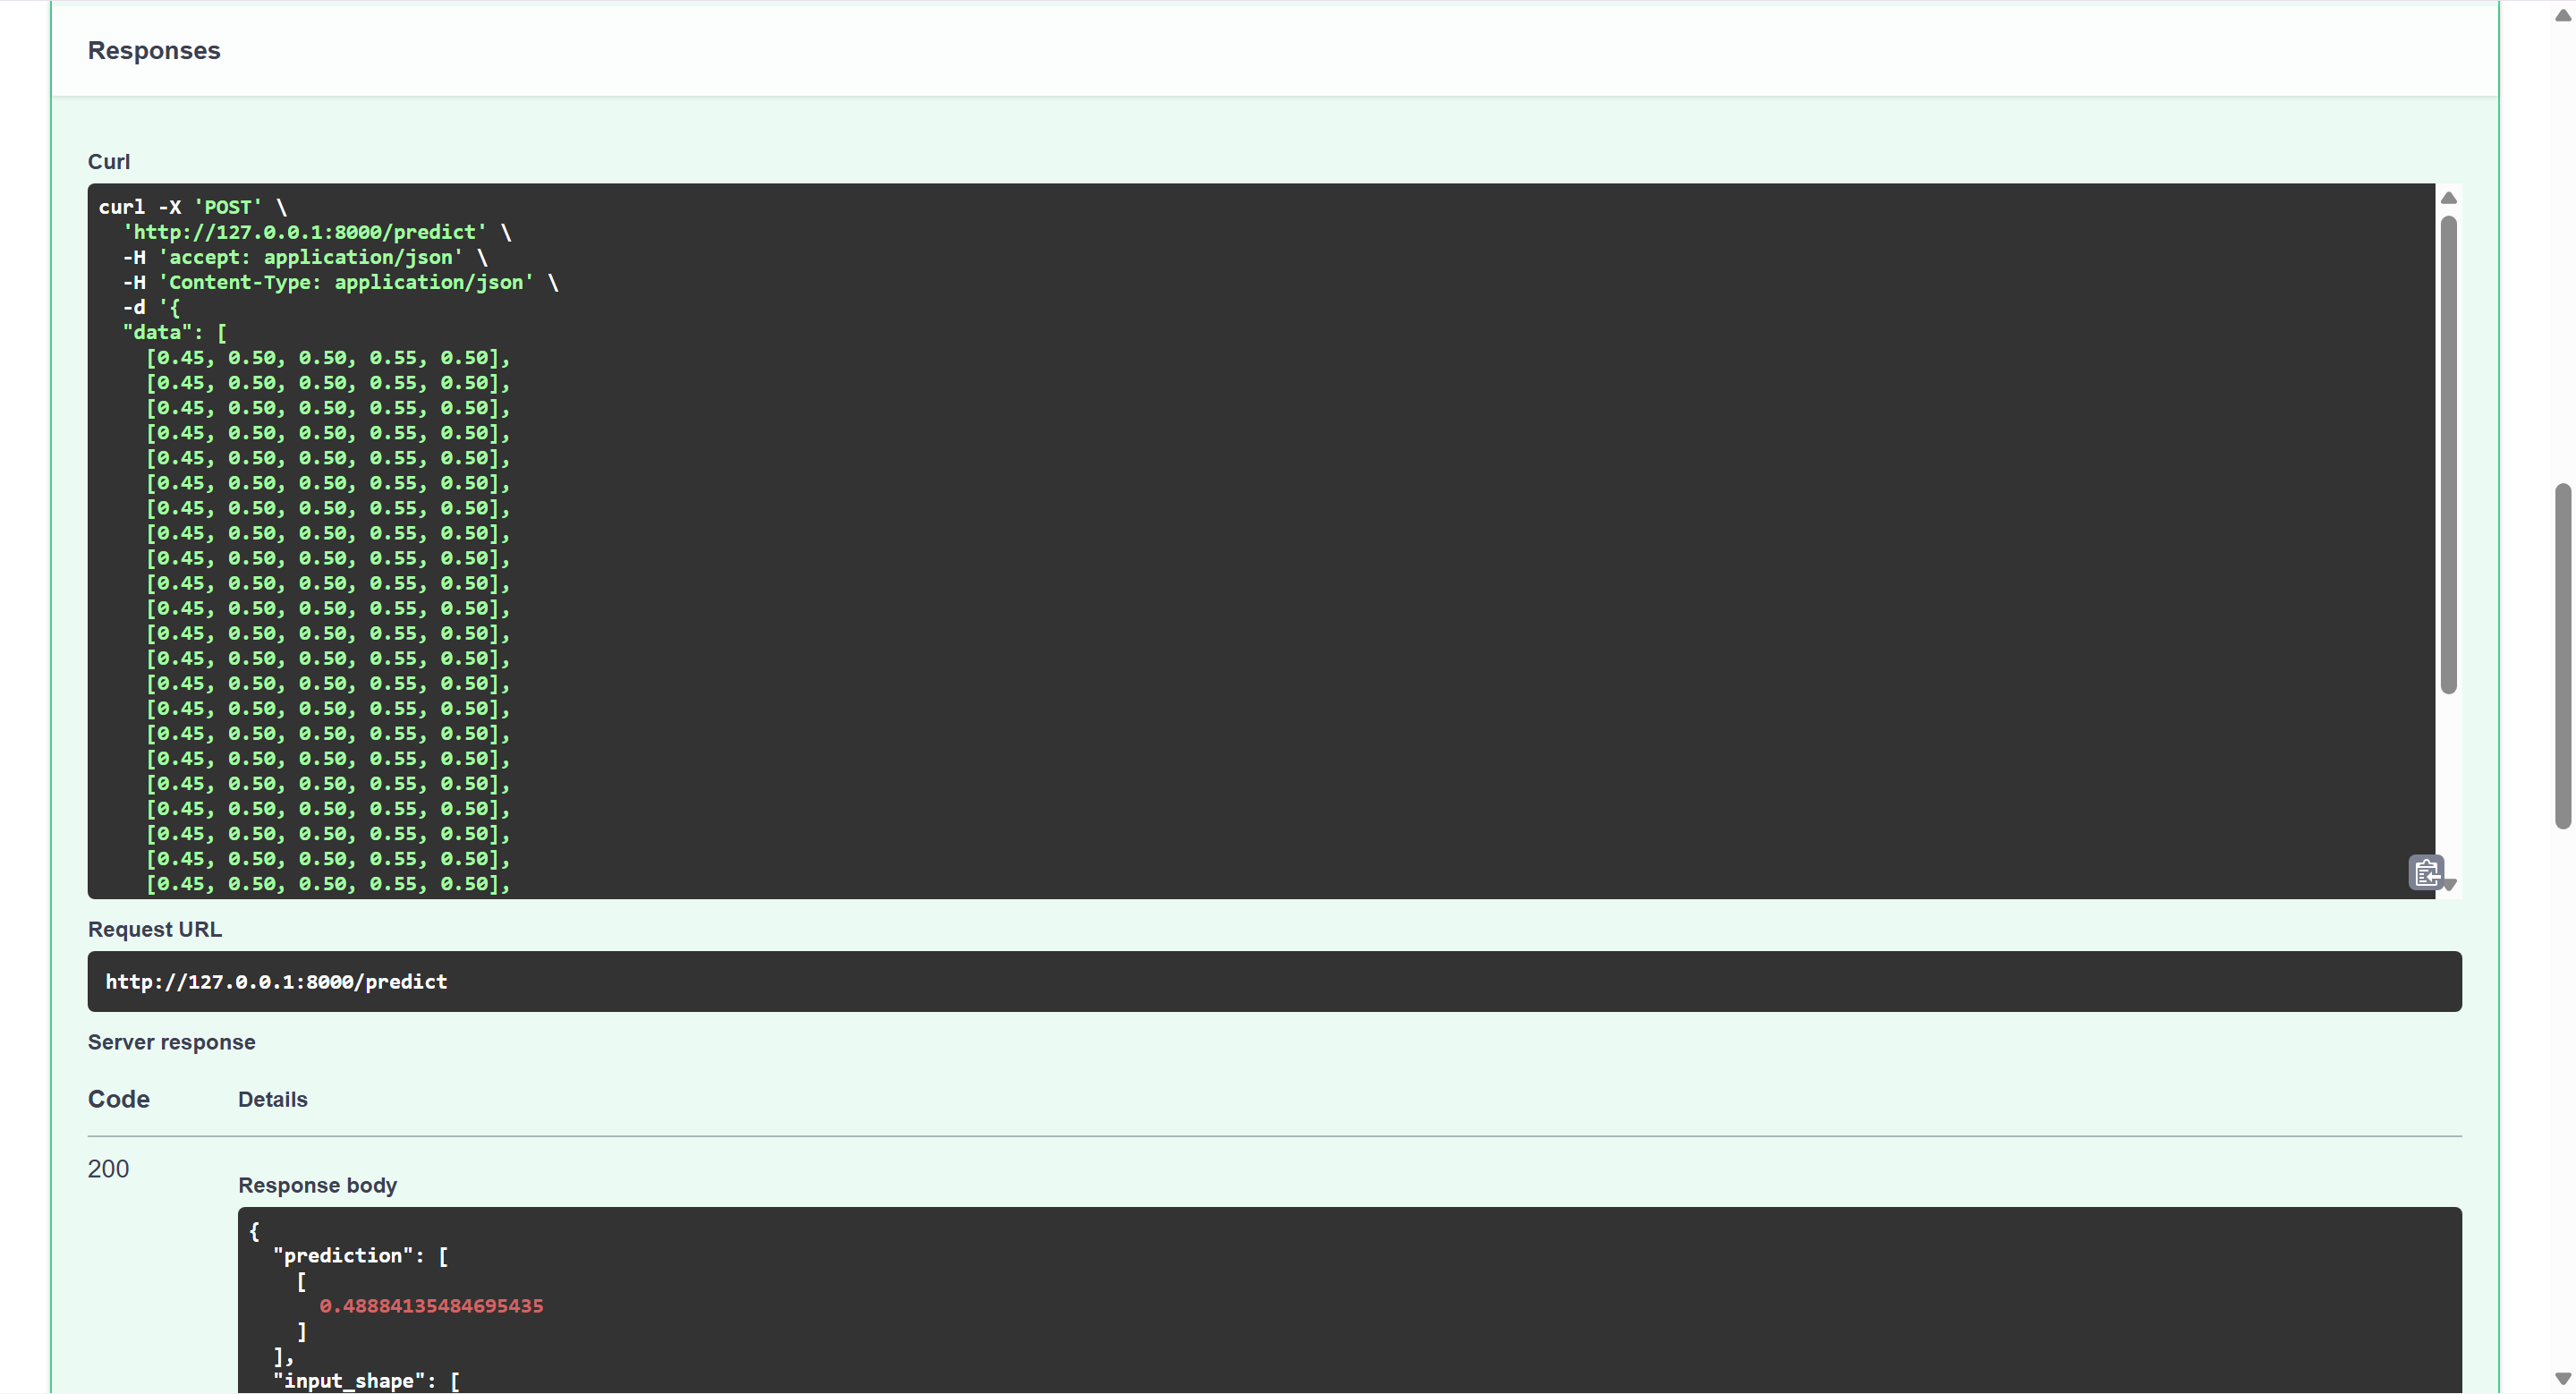

In [66]:
display(Image(filename="../results/figures/task5_1_fastapi_docs.png", width=1000))

display(Image(filename="../results/figures/task5_1_api_prediction_test_1.png", width=1000))

display(Image(filename="../results/figures/task5_1_api_prediction_test_2.png", width=1000))

## 8.2 Streamlit SaaS Interface

A Streamlit web application was developed to serve as a lightweight SaaS-style frontend for the deployed deep learning stock prediction system.

The application provides an interactive user interface that allows users to:
- select Vietnam stock tickers,
- generate realistic demo stock input sequences,
- manually create normalized stock market inputs,
- visualize 30-day historical input patterns,
- send prediction requests to the FastAPI backend,
- receive real-time prediction outputs,
- monitor prediction history,
- and download prediction records for further analysis.

The Streamlit frontend communicates directly with the FastAPI REST API using HTTP requests. After receiving user input, the application sends normalized stock sequences to the backend prediction service, which performs inference using the trained CNN model and returns prediction results as JSON responses.

The application also includes:
- API health monitoring,
- prediction interpretation,
- prediction visualization,
- SaaS deployment architecture explanation,
- and methodology documentation.

This demonstrates how a trained deep learning model can be transformed from a research notebook into an interactive AI-powered web application with frontend-backend separation, reproducible inference, and lightweight SaaS deployment capabilities.

# 8.3 AI Automation Workflow

Task 5.3 focuses on demonstrating a simplified AI engineering and automation workflow for stock prediction deployment.

The project follows an end-to-end pipeline beginning from raw financial data preprocessing and ending with interactive user prediction services.

The workflow includes:
- data preprocessing,
- feature engineering,
- deep learning training,
- model evaluation,
- model serialization,
- API deployment,
- and frontend SaaS integration.

CNN and LSTM models are trained using chronological time-series validation and sliding window generation. The trained models are then saved in `.keras` format and deployed using FastAPI REST APIs.

The Streamlit frontend communicates directly with the FastAPI backend, allowing users to interact with the deployed prediction system through a lightweight SaaS interface.

This workflow demonstrates several important AI engineering concepts, including:
- reproducibility,
- model serving,
- frontend-backend separation,
- API-based deployment,
- and interactive ML applications.

Although simplified for academic purposes, the workflow structure resembles modern machine learning deployment pipelines used in industry environments.

Future improvements could include:
- automated retraining pipelines,
- cloud deployment,
- real-time stock data ingestion,
- Airflow scheduling,
- database integration,
- CI/CD deployment pipelines,
- and automated model monitoring.

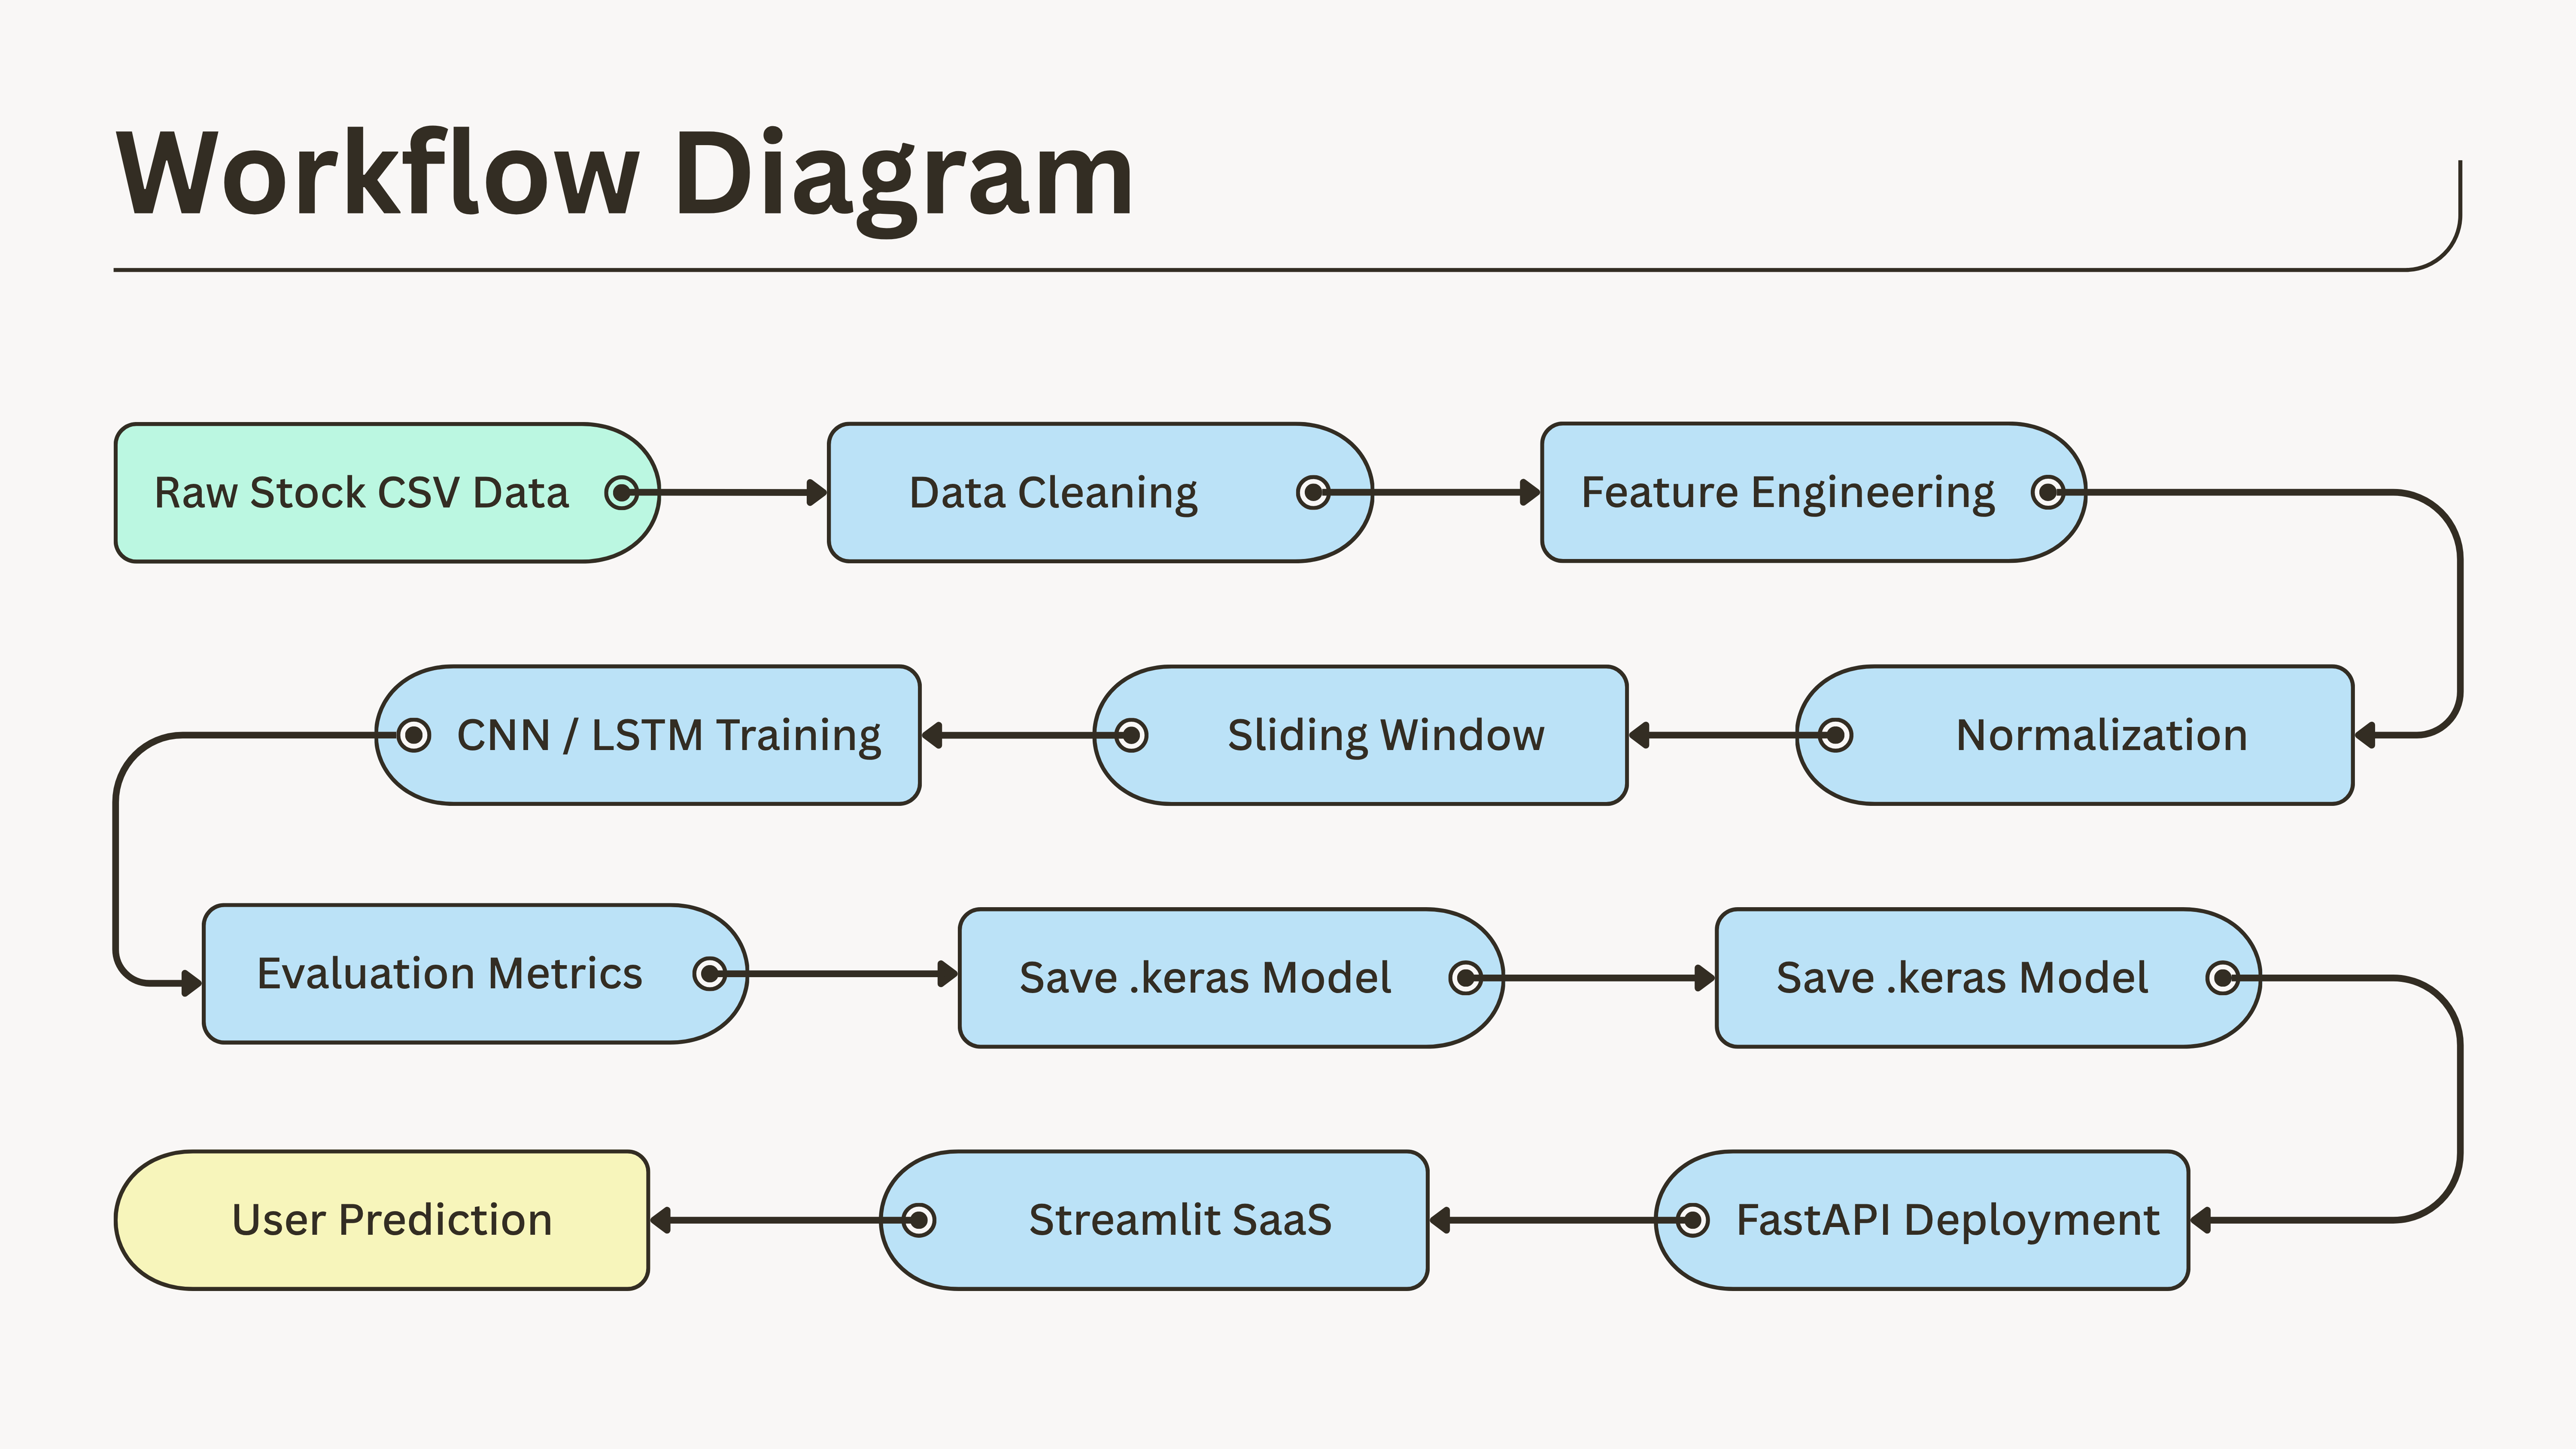

In [67]:
display(
    Image(
        filename="../results/figures/task5_3_workflow.png",
        width=1200
    )
)

# 9. Discussion

Several important findings were observed throughout the implementation and evaluation process of this project.

First, forecasting accuracy decreases as the prediction horizon becomes longer. The next-day prediction tasks consistently achieved lower RMSE and MAE values compared with 7th-day forecasting and multi-step prediction tasks. This result is expected because uncertainty increases when the model attempts to estimate values further into the future. Multi-step forecasting is particularly difficult because prediction errors can accumulate across future time steps.

Second, CNN and LSTM architectures demonstrated different strengths in time-series forecasting. CNN models performed effectively in short-term forecasting tasks because convolutional layers were able to capture local temporal patterns and short-term market movements efficiently. CNNs also showed stable performance in multi-output forecasting tasks. LSTM models, on the other hand, were designed to preserve sequential dependencies through recurrent memory mechanisms. While LSTMs were capable of learning temporal relationships, they did not consistently outperform CNN models on this dataset. This suggests that local trend extraction may be more useful than long-term sequential memory for the selected stock forecasting tasks.

Third, trading signal classification was significantly more challenging than numerical price forecasting. Buy and sell labels depend heavily on manually defined thresholds, which introduces additional uncertainty into the learning process. Furthermore, the datasets suffered from class imbalance because buy and sell opportunities occur less frequently than neutral market conditions. The initial classification models tended to predict the majority class, resulting in poor recall and F1-score values. Performance improved after applying class weighting techniques and adjusting classification thresholds, although sell signal identification remained difficult.

Fourth, the confusion matrix analysis highlighted the limitations of binary trading signal prediction. The buy signal model became highly aggressive in identifying opportunities, leading to improved recall but also increased false positives. In contrast, the sell signal model struggled to identify downward market conditions because strong declines were relatively rare in the dataset. These results demonstrate the practical difficulty of designing reliable automated trading classifiers.

Fifth, portfolio construction requires balancing both profitability and risk rather than focusing only on return maximization. The risk-return analysis showed that some stocks with strong returns also carried substantial volatility and drawdown risk. Therefore, the final allocation strategy considered cumulative return, volatility, and maximum drawdown simultaneously to produce a more balanced investment portfolio. This reflects an important principle in financial portfolio management where risk-adjusted performance is often more meaningful than raw return alone.

Finally, the deployment phase demonstrated that deep learning forecasting systems can be integrated into practical applications outside research notebooks. The FastAPI backend and Streamlit frontend provided a lightweight framework for building interactive financial prediction systems. This integration illustrates how machine learning models can move from experimentation into deployable financial analytics tools, even though additional engineering improvements would still be necessary for production-level systems.

# 10. Limitations

This project has several important limitations that should be considered when interpreting the experimental results and the portfolio recommendations.

First, the forecasting models rely only on historical stock market data such as past closing prices and return behavior. In real-world financial prediction systems, additional information sources including macroeconomic indicators, interest rates, inflation, company financial reports, news sentiment, and geopolitical events can significantly influence stock prices. Incorporating these external variables could improve model performance and prediction robustness.

Second, stock markets are inherently noisy, volatile, and partially unpredictable. Financial time-series data often contain random fluctuations and sudden market shocks that are difficult to model accurately. As a result, even advanced deep learning architectures such as CNNs and LSTMs cannot guarantee consistently accurate future predictions.

Third, the trading signal classification tasks depend heavily on manually selected buy and sell thresholds. Different threshold settings may change the class distribution and significantly affect accuracy, recall, precision, and F1-score. This sensitivity makes trading signal identification challenging and may reduce the generalizability of the classification models.

Fourth, the classification datasets suffer from class imbalance problems. Buy and sell signals occur less frequently than neutral market conditions, causing the models to bias toward the majority class. Although class weighting and threshold adjustments were applied, the confusion matrices show that signal identification performance remains limited, especially for sell signals.

Fifth, the portfolio optimization framework used in this project is intentionally simplified for educational purposes. The allocation strategy considers profitability and risk metrics, but it does not include practical investment constraints such as transaction costs, taxes, slippage, liquidity limitations, rebalancing frequency, or diversification constraints. More advanced portfolio optimization methods, such as mean-variance optimization or reinforcement learning-based allocation, could produce more realistic investment strategies.

Finally, the deployment system is lightweight and designed mainly for demonstration purposes. A real-world production trading system would require scalable cloud infrastructure, secure APIs, real-time market data ingestion, automated monitoring, model retraining pipelines, and stronger cybersecurity protections to ensure reliability and operational stability.

# 12. References

- TensorFlow Documentation
- Keras Documentation
- Scikit-learn Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation
- FastAPI Documentation
- Streamlit Documentation
- Nasdaq historical stock dataset
- Vietnam stock historical dataset